In [1]:
# Step 4 follow-up: Expanded regression and mechanism-of-action analysis
# Using ompounds w/ at least 20 profiles 

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd

from IPython.display import display



# Locate project folders


cwd = Path.cwd()

if (cwd / "data" / "step3_multimodal").exists():
    # Notebook is being run from the project root
    PROJECT_ROOT = cwd
    DATA_DIR = cwd / "data"

elif (cwd / "step3_multimodal").exists():
    # Notebook is being run from the data folder
    DATA_DIR = cwd
    PROJECT_ROOT = cwd.parent

else:
    raise FileNotFoundError(
        "Could not locate the project folders.\n"
        f"Current folder: {cwd}\n"
        "Expected either data/step3_multimodal or step3_multimodal."
    )


STEP3_DIR = DATA_DIR / "step3_multimodal"
MODEL_DIR = PROJECT_ROOT / "models"

OUTPUT_DIR = STEP3_DIR / "step4_expanded_n20"
FIG_DIR = (
    PROJECT_ROOT
    / "figures"
    / "step4_expanded_n20"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)



# Analysis settings


MIN_PROFILES = 20

TARGET_COL = "source_normalized_inverted_score"

RANDOM_STATE = 42



# Required input files


SCORE_PATH = (
    STEP3_DIR
    / "step3_compound_predictability_latent256_final_scores.csv"
)

EMBEDDING_PATH = (
    DATA_DIR
    / "step1_embeddings"
    / "step1_drug_embeddings_128.npy"
)

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)

print("\nScore file:")
print(SCORE_PATH)
print("Exists:", SCORE_PATH.exists())

print("\nEmbedding file:")
print(EMBEDDING_PATH)
print("Exists:", EMBEDDING_PATH.exists())

assert SCORE_PATH.exists(), (
    f"Missing score file: {SCORE_PATH}"
)

assert EMBEDDING_PATH.exists(), (
    f"Missing embedding file: {EMBEDDING_PATH}"
)



# Load Step 3 compound-level predictability scores


scores = pd.read_csv(
    SCORE_PATH,
    low_memory=False,
)

required_columns = [
    "compound_embedding_row_index",
    "compound_name",
    "n_profiles",
    TARGET_COL,
]

missing_columns = [
    column
    for column in required_columns
    if column not in scores.columns
]

if missing_columns:
    raise KeyError(
        "The score table is missing required columns: "
        f"{missing_columns}"
    )


compound_table = (
    scores
    .dropna(subset=required_columns)
    .copy()
)

compound_table["compound_embedding_row_index"] = (
    compound_table["compound_embedding_row_index"]
    .astype(int)
)

compound_table["n_profiles"] = (
    compound_table["n_profiles"]
    .astype(int)
)

compound_table = compound_table.reset_index(
    drop=True
)



# Load only the necessary Step 1 embeddings


all_embeddings = np.load(
    EMBEDDING_PATH,
    mmap_mode="r",
)

embedding_indices = (
    compound_table["compound_embedding_row_index"]
    .to_numpy(dtype=int)
)

if embedding_indices.min() < 0:
    raise IndexError(
        "A negative compound embedding index was found."
    )

if embedding_indices.max() >= all_embeddings.shape[0]:
    raise IndexError(
        "At least one compound embedding index is outside "
        "the saved embedding array."
    )

X_all = np.asarray(
    all_embeddings[embedding_indices],
    dtype=np.float32,
)



# Select the expanded n_profiles >= 20 cohort


analysis_mask = (
    compound_table["n_profiles"] >= MIN_PROFILES
).to_numpy()

X = X_all[analysis_mask]

y = (
    compound_table.loc[
        analysis_mask,
        TARGET_COL,
    ]
    .to_numpy(dtype=np.float32)
)

analysis_table = (
    compound_table.loc[
        analysis_mask,
        required_columns,
    ]
    .reset_index(drop=True)
)



# Validate the analysis dataset


assert X.shape[0] == len(analysis_table)
assert X.shape[1] == 128
assert y.shape == (len(analysis_table),)

assert np.isfinite(X).all()
assert np.isfinite(y).all()

assert (
    analysis_table["compound_embedding_row_index"]
    .is_unique
), "Duplicate compound embedding indices were found."


print("\nSetup complete")
print("-" * 50)

print("Minimum profiles:", MIN_PROFILES)
print("Eligible compounds:", len(analysis_table))
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print(
    "Minimum observed profile count:",
    analysis_table["n_profiles"].min(),
)

print(
    "Median profile count:",
    analysis_table["n_profiles"].median(),
)

print(
    "Maximum profile count:",
    analysis_table["n_profiles"].max(),
)

print(
    "Mean predictability score:",
    round(float(y.mean()), 4),
)

print(
    "Predictability standard deviation:",
    round(float(y.std()), 4),
)


if len(analysis_table) != 801:
    print(
        "\nNOTE: The previous threshold analysis produced "
        "801 compounds at n_profiles >= 20."
    )
    print(
        "The current result differs, so confirm that the same "
        "Step 3 score file is being used before continuing."
    )


display(
    analysis_table.head()
)

display(
    analysis_table[
        ["n_profiles", TARGET_COL]
    ].describe()
)

Project root: /Users/mell/predicting-predictability
Data directory: /Users/mell/predicting-predictability/data

Score file:
/Users/mell/predicting-predictability/data/step3_multimodal/step3_compound_predictability_latent256_final_scores.csv
Exists: True

Embedding file:
/Users/mell/predicting-predictability/data/step1_embeddings/step1_drug_embeddings_128.npy
Exists: True

Setup complete
--------------------------------------------------
Minimum profiles: 20
Eligible compounds: 801
Feature matrix shape: (801, 128)
Target shape: (801,)
Minimum observed profile count: 20
Median profile count: 74.0
Maximum profile count: 3036
Mean predictability score: 0.8268
Predictability standard deviation: 0.0891


,compound_embedding_row_index,compound_name,n_profiles,source_normalized_inverted_score
0,5185,Doxorubicin (hydrochloride); Doxorubicin Hydro...,280,0.969265
1,5134,Idarubicin (hydrochloride); Idarubicin Hydroch...,142,0.960813
2,5150,Doxycycline (monohydrate); Invertin,139,0.946269
3,5137,Docetaxel (Trihydrate); Docetaxel Trihydrate,136,0.942327
4,3111,Temuterkib,143,0.940575


,n_profiles,source_normalized_inverted_score
count,801.000000,801.000000
mean,109.344569,0.826764
std,176.879220,0.089164
min,20.000000,0.300781
25%,33.000000,0.781435
50%,74.000000,0.836058
75%,142.000000,0.887230
max,3036.000000,1.000000


In [3]:
# Generate repeated out-of-fold predictions for all 801 compounds

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from scipy.stats import spearmanr



# Cross-validation settings


N_SPLITS = 5
N_REPEATS = 5

n_compounds = len(analysis_table)

# One row per repeat, one column per compound
oof_prediction_matrix = np.full(
    shape=(N_REPEATS, n_compounds),
    fill_value=np.nan,
    dtype=np.float32,
)

repeat_metric_rows = []



# Repeated five-fold out-of-fold prediction


for repeat_number in range(N_REPEATS):

    print(
        f"\nRepeat {repeat_number + 1} "
        f"of {N_REPEATS}"
    )

    cv = KFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE + repeat_number,
    )

    for fold_number, (
        train_indices,
        test_indices,
    ) in enumerate(
        cv.split(X),
        start=1,
    ):

        model = ExtraTreesRegressor(
            n_estimators=400,
            max_depth=None,
            min_samples_leaf=3,
            random_state=(
                RANDOM_STATE
                + repeat_number * 100
                + fold_number
            ),
            n_jobs=-1,
        )

        model.fit(
            X[train_indices],
            y[train_indices],
        )

        fold_predictions = model.predict(
            X[test_indices]
        )

        oof_prediction_matrix[
            repeat_number,
            test_indices,
        ] = fold_predictions

        print(
            f"  Fold {fold_number}: "
            f"{len(train_indices)} train, "
            f"{len(test_indices)} test"
        )


    # Confirm every compound received one prediction
    # during this repeat
    assert np.isfinite(
        oof_prediction_matrix[repeat_number]
    ).all()

    repeat_predictions = (
        oof_prediction_matrix[repeat_number]
    )

    repeat_r2 = r2_score(
        y,
        repeat_predictions,
    )

    repeat_spearman = spearmanr(
        y,
        repeat_predictions,
    ).correlation

    repeat_mae = mean_absolute_error(
        y,
        repeat_predictions,
    )

    repeat_rmse = np.sqrt(
        mean_squared_error(
            y,
            repeat_predictions,
        )
    )

    repeat_metric_rows.append({
        "repeat": repeat_number + 1,
        "n_compounds": n_compounds,
        "n_splits": N_SPLITS,
        "r2": repeat_r2,
        "spearman": repeat_spearman,
        "mae": repeat_mae,
        "rmse": repeat_rmse,
    })

    print(
        f"  Repeat R²: {repeat_r2:.3f}"
    )

    print(
        f"  Repeat Spearman: "
        f"{repeat_spearman:.3f}"
    )



# Average each compound's predictions across repeats


oof_prediction_mean = (
    oof_prediction_matrix.mean(axis=0)
)

oof_prediction_sd = (
    oof_prediction_matrix.std(axis=0)
)



# Overall performance using averaged OOF predictions


overall_r2 = r2_score(
    y,
    oof_prediction_mean,
)

overall_spearman = spearmanr(
    y,
    oof_prediction_mean,
).correlation

overall_mae = mean_absolute_error(
    y,
    oof_prediction_mean,
)

overall_rmse = np.sqrt(
    mean_squared_error(
        y,
        oof_prediction_mean,
    )
)



# Performance on high-confidence compounds only


high_confidence_mask = (
    analysis_table["n_profiles"] >= 100
).to_numpy()

high_confidence_r2 = r2_score(
    y[high_confidence_mask],
    oof_prediction_mean[high_confidence_mask],
)

high_confidence_spearman = spearmanr(
    y[high_confidence_mask],
    oof_prediction_mean[high_confidence_mask],
).correlation

high_confidence_mae = mean_absolute_error(
    y[high_confidence_mask],
    oof_prediction_mean[high_confidence_mask],
)

high_confidence_rmse = np.sqrt(
    mean_squared_error(
        y[high_confidence_mask],
        oof_prediction_mean[high_confidence_mask],
    )
)



# Create compound-level prediction table


oof_results = analysis_table.copy()

oof_results["actual_predictability"] = y

oof_results["predicted_predictability"] = (
    oof_prediction_mean
)

oof_results["prediction_sd"] = (
    oof_prediction_sd
)

oof_results["residual"] = (
    oof_results["actual_predictability"]
    - oof_results["predicted_predictability"]
)

oof_results["absolute_error"] = (
    oof_results["residual"].abs()
)

oof_results["predicted_rank"] = (
    oof_results["predicted_predictability"]
    .rank(
        ascending=False,
        method="average",
    )
)



# Save outputs


OOF_RESULTS_PATH = (
    OUTPUT_DIR
    / "step4_extra_trees_n20_oof_predictions.csv"
)

REPEAT_METRICS_PATH = (
    OUTPUT_DIR
    / "step4_extra_trees_n20_repeat_metrics.csv"
)

SUMMARY_METRICS_PATH = (
    OUTPUT_DIR
    / "step4_extra_trees_n20_oof_summary_metrics.csv"
)

PREDICTION_MATRIX_PATH = (
    OUTPUT_DIR
    / "step4_extra_trees_n20_oof_prediction_matrix.npy"
)


oof_results.to_csv(
    OOF_RESULTS_PATH,
    index=False,
)

repeat_metrics = pd.DataFrame(
    repeat_metric_rows
)

repeat_metrics.to_csv(
    REPEAT_METRICS_PATH,
    index=False,
)

np.save(
    PREDICTION_MATRIX_PATH,
    oof_prediction_matrix,
)


summary_metrics = pd.DataFrame([
    {
        "evaluation_group": "all_n_profiles_greater_equal_20",
        "n_compounds": len(y),
        "r2": overall_r2,
        "spearman": overall_spearman,
        "mae": overall_mae,
        "rmse": overall_rmse,
    },
    {
        "evaluation_group": "high_confidence_n_profiles_greater_equal_100",
        "n_compounds": int(
            high_confidence_mask.sum()
        ),
        "r2": high_confidence_r2,
        "spearman": high_confidence_spearman,
        "mae": high_confidence_mae,
        "rmse": high_confidence_rmse,
    },
])

summary_metrics.to_csv(
    SUMMARY_METRICS_PATH,
    index=False,
)



# Display results


print("\n" + "=" * 60)
print("Repeated out-of-fold evaluation complete")
print("=" * 60)

print("\nAll compounds with n_profiles >= 20")
print("Compounds:", len(y))
print(f"R²:       {overall_r2:.3f}")
print(f"Spearman: {overall_spearman:.3f}")
print(f"MAE:      {overall_mae:.4f}")
print(f"RMSE:     {overall_rmse:.4f}")

print("\nHigh-confidence subset with n_profiles >= 100")
print(
    "Compounds:",
    high_confidence_mask.sum(),
)
print(f"R²:       {high_confidence_r2:.3f}")
print(
    f"Spearman: "
    f"{high_confidence_spearman:.3f}"
)
print(f"MAE:      {high_confidence_mae:.4f}")
print(
    f"RMSE:     "
    f"{high_confidence_rmse:.4f}"
)

print("\nSaved prediction table:")
print(OOF_RESULTS_PATH)

print("\nSaved summary metrics:")
print(SUMMARY_METRICS_PATH)

display(summary_metrics)

display(
    oof_results[
        [
            "compound_name",
            "n_profiles",
            "actual_predictability",
            "predicted_predictability",
            "prediction_sd",
            "absolute_error",
        ]
    ]
    .sort_values(
        "predicted_predictability",
        ascending=False,
    )
    .head(10)
)


Repeat 1 of 5
  Fold 1: 640 train, 161 test
  Fold 2: 641 train, 160 test
  Fold 3: 641 train, 160 test
  Fold 4: 641 train, 160 test
  Fold 5: 641 train, 160 test
  Repeat R²: 0.129
  Repeat Spearman: 0.361

Repeat 2 of 5
  Fold 1: 640 train, 161 test
  Fold 2: 641 train, 160 test
  Fold 3: 641 train, 160 test
  Fold 4: 641 train, 160 test
  Fold 5: 641 train, 160 test
  Repeat R²: 0.135
  Repeat Spearman: 0.382

Repeat 3 of 5
  Fold 1: 640 train, 161 test
  Fold 2: 641 train, 160 test
  Fold 3: 641 train, 160 test
  Fold 4: 641 train, 160 test
  Fold 5: 641 train, 160 test
  Repeat R²: 0.120
  Repeat Spearman: 0.358

Repeat 4 of 5
  Fold 1: 640 train, 161 test
  Fold 2: 641 train, 160 test
  Fold 3: 641 train, 160 test
  Fold 4: 641 train, 160 test
  Fold 5: 641 train, 160 test
  Repeat R²: 0.134
  Repeat Spearman: 0.364

Repeat 5 of 5
  Fold 1: 640 train, 161 test
  Fold 2: 641 train, 160 test
  Fold 3: 641 train, 160 test
  Fold 4: 641 train, 160 test
  Fold 5: 641 train, 160 test

,evaluation_group,n_compounds,r2,spearman,mae,rmse
0,all_n_profiles_greater_equal_20,801,0.136042,0.379465,0.063266,0.082825
1,high_confidence_n_profiles_greater_equal_100,349,0.133087,0.372285,0.060709,0.074288


,compound_name,n_profiles,actual_predictability,predicted_predictability,prediction_sd,absolute_error
376,"(7R,9S)-7-[(2R,4S,5S,6S)-4-amino-5-hydroxy-6-m...",386,0.972176,0.962845,0.009997,0.009331
267,Epirubicin; epirubicin,194,0.983716,0.961449,0.008261,0.022267
1,Idarubicin (hydrochloride); Idarubicin Hydroch...,142,0.960813,0.958234,0.007328,0.002579
270,Idarubicin; idarubicin,134,0.975772,0.956359,0.005216,0.019413
262,"(7R,9S)-9-acetyl-7-[[(2R,4S,5S,6S)-4-amino-5-h...",325,0.993675,0.954556,0.003145,0.039120
0,Doxorubicin (hydrochloride); Doxorubicin Hydro...,280,0.969265,0.953787,0.006604,0.015478
10,Topotecan (hydrochloride); Topotecan Hydrochlo...,142,0.911250,0.933917,0.022671,0.022667
263,Geldanamycin; geldanamycin,938,0.987674,0.926570,0.008105,0.061103
266,"Tanespimycin; [(4E,6Z,8S,9S,10E,12S,13R,14S,16...",645,0.995693,0.923778,0.014941,0.071914
68,Ouabain (Octahydrate); Ouabain Octahydrate,144,0.844328,0.923442,0.028146,0.079114


,predicted_quintile,n_compounds,mean_actual_predictability,median_actual_predictability,std_actual_predictability,mean_predicted_predictability
0,Least\npredictable,161,0.781380,0.801439,0.088549,0.788727
1,Lower,160,0.808978,0.817731,0.085349,0.812418
2,Middle,160,0.826404,0.839005,0.083528,0.824415
3,Higher,160,0.844032,0.861938,0.079800,0.837979
4,Most\npredictable,160,0.873311,0.882362,0.081221,0.871648


Kruskal-Wallis statistic: 113.553
Kruskal-Wallis p-value: 1.271e-23


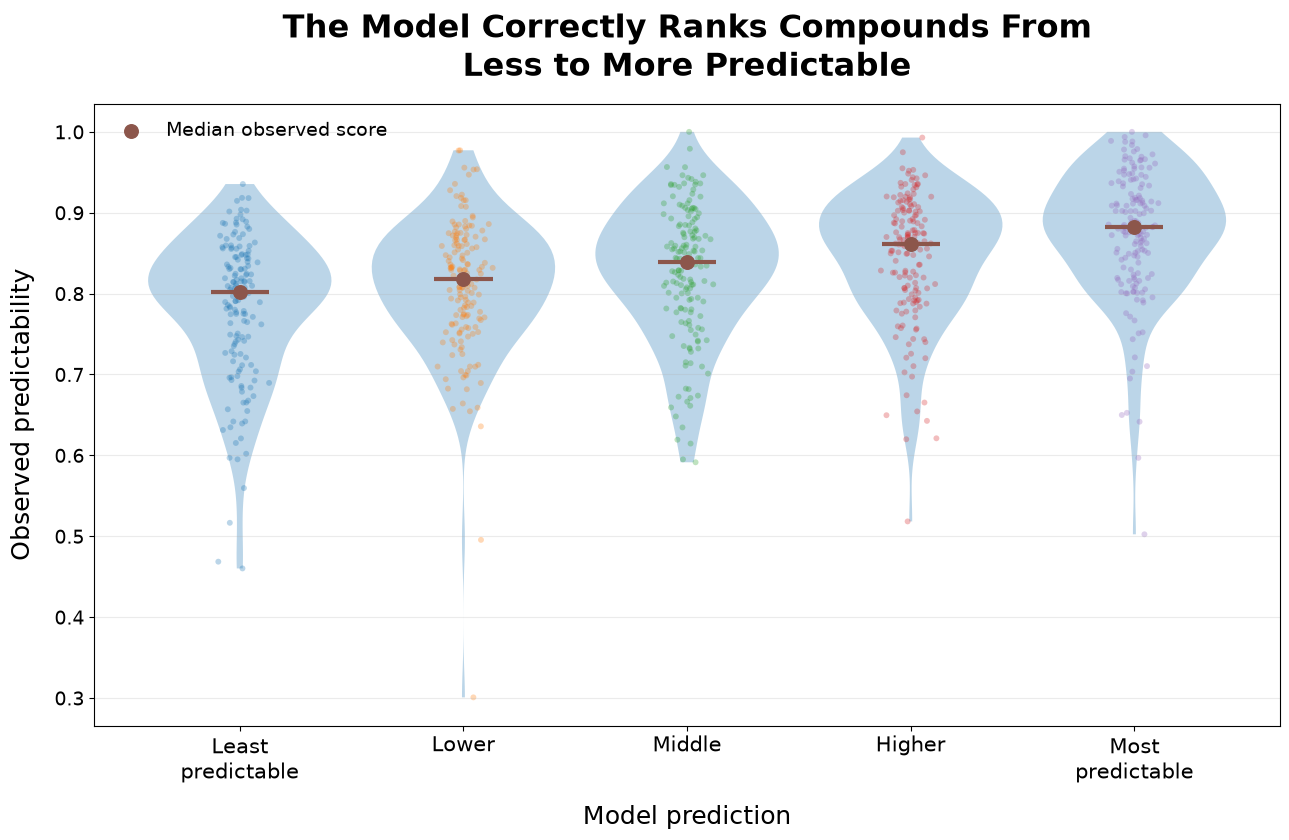


Saved violin plot:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_observed_by_predicted_quintile.png

Saved quintile summary:
/Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/step4_n20_predicted_quintile_summary.csv


In [16]:
# Visualize 

import matplotlib.pyplot as plt
from scipy.stats import kruskal



# Assign compounds to five predicted groups


quintile_labels = [
    "Least\npredictable",
    "Lower",
    "Middle",
    "Higher",
    "Most\npredictable",
]

# Rank first
prediction_rank_for_binning = (
    oof_results["predicted_predictability"]
    .rank(
        method="first",
        ascending=True,
    )
)

oof_results["predicted_quintile"] = pd.qcut(
    prediction_rank_for_binning,
    q=5,
    labels=quintile_labels,
)

oof_results["predicted_quintile"] = pd.Categorical(
    oof_results["predicted_quintile"],
    categories=quintile_labels,
    ordered=True,
)


# Summarize each group


quintile_summary = (
    oof_results
    .groupby(
        "predicted_quintile",
        observed=False,
    )
    .agg(
        n_compounds=(
            "actual_predictability",
            "size",
        ),
        mean_actual_predictability=(
            "actual_predictability",
            "mean",
        ),
        median_actual_predictability=(
            "actual_predictability",
            "median",
        ),
        std_actual_predictability=(
            "actual_predictability",
            "std",
        ),
        mean_predicted_predictability=(
            "predicted_predictability",
            "mean",
        ),
    )
    .reset_index()
)

display(quintile_summary)


# Prepare values for plotting


violin_values = [
    oof_results.loc[
        oof_results["predicted_quintile"] == label,
        "actual_predictability",
    ].to_numpy()
    for label in quintile_labels
]


# Test whether the five groups differ overall


kruskal_result = kruskal(
    *violin_values
)

print(
    "Kruskal-Wallis statistic:",
    round(float(kruskal_result.statistic), 3),
)

print(
    "Kruskal-Wallis p-value:",
    f"{kruskal_result.pvalue:.3e}",
)



# Create clearer violin plot


fig, ax = plt.subplots(
    figsize=(13, 8.5)
)

positions = np.arange(
    1,
    len(quintile_labels) + 1,
)

# Violin distributions
ax.violinplot(
    violin_values,
    positions=positions,
    widths=0.82,
    showmeans=False,
    showmedians=False,
    showextrema=False,
)


# Add individual compounds 
rng = np.random.default_rng(
    RANDOM_STATE
)

for position, values in enumerate(
    violin_values,
    start=1,
):
    jitter = rng.normal(
        loc=position,
        scale=0.045,
        size=len(values),
    )

    ax.scatter(
        jitter,
        values,
        s=18,
        alpha=0.30,
        edgecolors="none",
    )


# Add median lines and points using the same color
median_color = "tab:brown"

ax.hlines(
    y=group_medians,
    xmin=positions - 0.13,
    xmax=positions + 0.13,
    color=median_color,
    linewidth=3,
    zorder=5,
)

ax.scatter(
    positions,
    group_medians,
    s=95,
    color=median_color,
    zorder=6,
    label="Median observed score",
)


# Larger and clearer text


ax.set_xticks(
    positions
)

ax.set_xticklabels(
    quintile_labels,
    fontsize=15,
)

ax.set_xlabel(
    "Model prediction",
    fontsize=18,
    labelpad=14,
)

ax.set_ylabel(
    "Observed predictability",
    fontsize=18,
    labelpad=14,
)

ax.set_title(
    "The Model Correctly Ranks Compounds From\n"
    "Less to More Predictable",
    fontsize=23,
    pad=20,
    fontweight="bold",
)

ax.tick_params(
    axis="y",
    labelsize=14,
)

ax.grid(
    axis="y",
    alpha=0.25,
)

ax.legend(
    fontsize=14,
    frameon=False,
    loc="upper left",
)

fig.tight_layout()



# Save figure and tables


VIOLIN_FIGURE_PATH = (
    FIG_DIR
    / "step4_n20_observed_by_predicted_quintile.png"
)

VIOLIN_FIGURE_PDF_PATH = (
    FIG_DIR
    / "step4_n20_observed_by_predicted_quintile.pdf"
)

QUINTILE_SUMMARY_PATH = (
    OUTPUT_DIR
    / "step4_n20_predicted_quintile_summary.csv"
)

OOF_RESULTS_WITH_GROUPS_PATH = (
    OUTPUT_DIR
    / "step4_extra_trees_n20_oof_predictions_with_groups.csv"
)


fig.savefig(
    VIOLIN_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    VIOLIN_FIGURE_PDF_PATH,
    bbox_inches="tight",
)

quintile_summary.to_csv(
    QUINTILE_SUMMARY_PATH,
    index=False,
)

oof_results.to_csv(
    OOF_RESULTS_WITH_GROUPS_PATH,
    index=False,
)

plt.show()


print("\nSaved violin plot:")
print(VIOLIN_FIGURE_PATH)

print("\nSaved quintile summary:")
print(QUINTILE_SUMMARY_PATH)

In [9]:
# MoA analysis, Step 1

import numpy as np
import pandas as pd
from pathlib import Path



# Load Step 1 compound metadata


STEP1_METADATA_PATH = (
    DATA_DIR
    / "step1_embeddings"
    / "step1_compound_embeddings_metadata.csv"
)

print("Step 1 metadata file:")
print(STEP1_METADATA_PATH)
print("Exists:", STEP1_METADATA_PATH.exists())

assert STEP1_METADATA_PATH.exists(), (
    f"Missing Step 1 metadata: {STEP1_METADATA_PATH}"
)


step1_metadata = pd.read_csv(
    STEP1_METADATA_PATH,
    usecols=lambda column: column in {
        "embedding_row_index",
        "compound_name",
        "canonical_smiles",
        "moa",
        "target",
    },
    low_memory=False,
)

required_metadata_columns = {
    "embedding_row_index",
    "moa",
}

missing_metadata_columns = (
    required_metadata_columns
    - set(step1_metadata.columns)
)

assert not missing_metadata_columns, (
    "Step 1 metadata is missing columns: "
    f"{sorted(missing_metadata_columns)}"
)


step1_metadata = (
    step1_metadata
    .rename(
        columns={
            "embedding_row_index":
                "compound_embedding_row_index",
        }
    )
    .drop_duplicates(
        subset="compound_embedding_row_index",
        keep="first",
    )
    .copy()
)

step1_metadata["compound_embedding_row_index"] = (
    step1_metadata["compound_embedding_row_index"]
    .astype(int)
)



# Recreate the five model-predicted groups


prediction_rank_for_binning = (
    oof_results["predicted_predictability"]
    .rank(
        method="first",
        ascending=True,
    )
)

model_group_labels = [
    "Least predictable",
    "Lower",
    "Middle",
    "Higher",
    "Most predictable",
]

moa_results = oof_results.copy()

moa_results["model_prediction_group"] = pd.qcut(
    prediction_rank_for_binning,
    q=5,
    labels=model_group_labels,
)

moa_results["model_prediction_group"] = pd.Categorical(
    moa_results["model_prediction_group"],
    categories=model_group_labels,
    ordered=True,
)



# Merge MoA annotations


moa_results = moa_results.merge(
    step1_metadata[
        [
            "compound_embedding_row_index",
            "moa",
            "target",
        ]
    ],
    on="compound_embedding_row_index",
    how="left",
    validate="one_to_one",
)

assert len(moa_results) == len(oof_results)


# Clean common missing-value strings
missing_annotation_values = {
    "",
    "nan",
    "none",
    "<na>",
    "na",
    "n/a",
    "-",
}

for column in ["moa", "target"]:

    moa_results[column] = (
        moa_results[column]
        .astype("string")
        .str.strip()
    )

    invalid_mask = (
        moa_results[column]
        .str.lower()
        .isin(missing_annotation_values)
        .fillna(False)
    )

    moa_results.loc[
        invalid_mask,
        column,
    ] = pd.NA



# Keep only the least and most predictable groups


extreme_groups = [
    "Least predictable",
    "Most predictable",
]

extreme_results = (
    moa_results[
        moa_results["model_prediction_group"]
        .isin(extreme_groups)
    ]
    .copy()
)

extreme_results["model_prediction_group"] = (
    extreme_results["model_prediction_group"]
    .astype(str)
)

# Summarize annotation coverage


coverage_summary = (
    extreme_results
    .groupby("model_prediction_group")
    .agg(
        n_compounds=(
            "compound_embedding_row_index",
            "nunique",
        ),
        n_with_moa=(
            "moa",
            lambda values: values.notna().sum(),
        ),
        n_with_target=(
            "target",
            lambda values: values.notna().sum(),
        ),
    )
    .reindex(extreme_groups)
    .reset_index()
)

coverage_summary["percent_with_moa"] = (
    100
    * coverage_summary["n_with_moa"]
    / coverage_summary["n_compounds"]
)

coverage_summary["percent_with_target"] = (
    100
    * coverage_summary["n_with_target"]
    / coverage_summary["n_compounds"]
)


print("\nMoA metadata merge complete")
print("-" * 55)
print("All modelled compounds:", len(moa_results))
print("Extreme-group compounds:", len(extreme_results))

display(coverage_summary)

display(
    extreme_results[
        [
            "compound_name",
            "model_prediction_group",
            "predicted_predictability",
            "actual_predictability",
            "moa",
            "target",
        ]
    ]
    .sort_values(
        [
            "model_prediction_group",
            "predicted_predictability",
        ],
        ascending=[True, False],
    )
    .head(20)
)

Step 1 metadata file:
/Users/mell/predicting-predictability/data/step1_embeddings/step1_compound_embeddings_metadata.csv
Exists: True

MoA metadata merge complete
-------------------------------------------------------
All modelled compounds: 801
Extreme-group compounds: 321


,model_prediction_group,n_compounds,n_with_moa,n_with_target,percent_with_moa,percent_with_target
0,Least predictable,161,144,129,89.440994,80.124224
1,Most predictable,160,146,131,91.25,81.875


,compound_name,model_prediction_group,predicted_predictability,actual_predictability,moa,target
49,"Naproxen, (-)-; naproxen",Least predictable,0.805421,0.903755,Cyclooxygenase inhibitor; cyclooxygenase inhib...,"PTGS1 | PTGS2; PTGS1, PTGS2"
154,Darolutamide,Least predictable,0.805265,0.774786,androgen receptor antagonist; inhibitor/antago...,AR
759,4-tert-butyl-N-[2-methyl-3-[4-methyl-6-[4-(mor...,Least predictable,0.805008,0.468567,<NA>,['BTK']
268,"(Z)-3-[3-[3,5-bis(trifluoromethyl)phenyl]-1,2,...",Least predictable,0.805000,0.848897,Exportin 1 inhibitor; exportin antagonist,XPO1; ['XPO1']
739,5-chloro-2-N-[(1S)-1-(5-fluoropyrimidin-2-yl)e...,Least predictable,0.804618,0.819014,JAK inhibitor; Jak2 Inhibitors,JAK1 | JAK2 | JAK3; ['JAK1' 'JAK2']
651,Tamibarotene; tamibarotene,Least predictable,0.804556,0.726672,Retinoid receptor agonist; retinoid receptor a...,"RARA | RARB; RARB, RARA"
470,"1-[2-chloro-4-(6,7-dimethoxyquinolin-4-yl)oxyp...",Least predictable,0.804477,0.847737,Angiogenesis Inhibitors;VEGFR-2 (FLK-1/KDR) In...,FLT1 | FLT4 | KDR | KIT | PDGFRA | PDGFRB; KIT...
482,CGK-733; Diphenyl acetamidotrichloroethyl fluo...,Least predictable,0.804344,0.845304,ATM kinase inhibitor | ATR kinase inhibitor; A...,"ATM | ATR; ATM, ATR"
480,(+-)-Quinacrine; 4-N-(6-chloro-2-methoxyacridi...,Least predictable,0.804167,0.848605,"Cytokine production inhibitor, NFKB pathway in...",AKT1 | MTOR | NFKB1 | PLA2G1B | PLA2G2A | PLA2...
569,thioguanine,Least predictable,0.804137,0.801525,Purine antagonist; purine antagonist,"IMPDH1 | IMPDH2; IMPDH2, IMPDH1"


MoA-annotated compounds by group:


,model_prediction_group,n_annotated_compounds
0,Least predictable,144
1,Most predictable,146



Most common MoAs in the two extreme groups:


,moa_annotation,least_predictable_count,most_predictable_count,least_predictable_percent,most_predictable_percent,total_extreme_count
0,inhibitor/antagonist,23,30,15.972222,20.547945,53
1,unclear,12,16,8.333333,10.958904,28
2,topoisomerase inhibitor,0,11,0.000000,7.534247,11
3,Topoisomerase inhibitor,1,10,0.694444,6.849315,11
4,glucocorticoid receptor agonist,0,11,0.000000,7.534247,11
5,ATPase inhibitor,0,7,0.000000,4.794521,7
6,mTOR inhibitor,0,6,0.000000,4.109589,6
7,activator/agonist,5,1,3.472222,0.684932,6
8,Glucocorticoid receptor agonist,0,6,0.000000,4.109589,6
9,Aurora kinase inhibitor,5,0,3.472222,0.000000,5


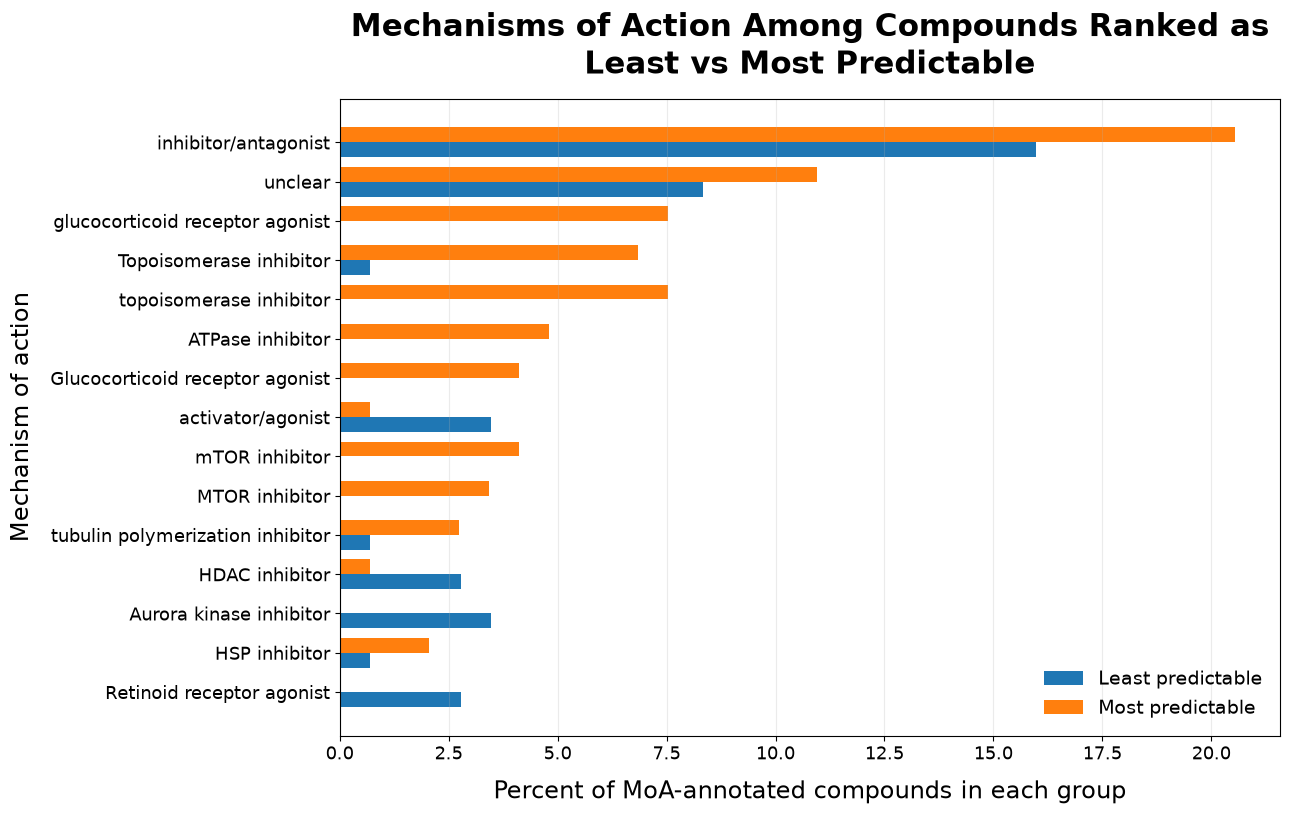


Saved MoA comparison table:
/Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/step4_n20_extreme_predicted_group_moa_counts.csv

Saved MoA figure:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_least_vs_most_predictable_moa.png


In [17]:
# MoA analysis, Step 2

import matplotlib.pyplot as plt


# Split semicolon-separated MoA annotations

def split_moa_annotations(value):
    """
    Return the distinct MoA annotations stored for one compound.
    """

    if pd.isna(value):
        return []

    annotations = []

    for annotation in str(value).split(";"):

        annotation = annotation.strip()

        if (
            annotation
            and annotation.lower()
            not in missing_annotation_values
        ):
            annotations.append(annotation)

    return sorted(set(annotations))


moa_long = (
    extreme_results[
        [
            "compound_embedding_row_index",
            "compound_name",
            "model_prediction_group",
            "moa",
        ]
    ]
    .assign(
        moa_annotation=lambda frame:
            frame["moa"].apply(split_moa_annotations)
    )
    .explode("moa_annotation")
    .dropna(subset=["moa_annotation"])
    .copy()
)

moa_long["moa_annotation"] = (
    moa_long["moa_annotation"]
    .astype(str)
    .str.strip()
)

# Count each MoA no more than once per compound
moa_long = (
    moa_long
    .drop_duplicates(
        subset=[
            "compound_embedding_row_index",
            "model_prediction_group",
            "moa_annotation",
        ]
    )
    .reset_index(drop=True)
)


# Count MoA-annotated compounds in each group

annotated_group_sizes = (
    moa_long
    .groupby("model_prediction_group")[
        "compound_embedding_row_index"
    ]
    .nunique()
    .reindex(extreme_groups)
)

print("MoA-annotated compounds by group:")

display(
    annotated_group_sizes
    .rename("n_annotated_compounds")
    .reset_index()
)


# Count compounds carrying each MoA

# NumPy arrays 
moa_counts = pd.crosstab(
    index=moa_long["moa_annotation"].to_numpy(),
    columns=moa_long["model_prediction_group"].to_numpy(),
)

moa_counts.index.name = "moa_annotation"
moa_counts.columns.name = "model_prediction_group"

moa_counts = moa_counts.reindex(
    columns=extreme_groups,
    fill_value=0,
)


# Create comparison table

moa_comparison = moa_counts.copy()

moa_comparison.columns = [
    "least_predictable_count",
    "most_predictable_count",
]

n_annotated_least = int(
    annotated_group_sizes["Least predictable"]
)

n_annotated_most = int(
    annotated_group_sizes["Most predictable"]
)

assert n_annotated_least > 0
assert n_annotated_most > 0


moa_comparison["least_predictable_percent"] = (
    100
    * moa_comparison["least_predictable_count"]
    / n_annotated_least
)

moa_comparison["most_predictable_percent"] = (
    100
    * moa_comparison["most_predictable_count"]
    / n_annotated_most
)

moa_comparison["total_extreme_count"] = (
    moa_comparison["least_predictable_count"]
    + moa_comparison["most_predictable_count"]
)

moa_comparison = (
    moa_comparison
    .sort_values(
        "total_extreme_count",
        ascending=False,
    )
    .reset_index()
)


# Select the most represented MoAs for visualization

N_MOAS_TO_PLOT = 15

plot_table = (
    moa_comparison
    .head(N_MOAS_TO_PLOT)
    .sort_values(
        "total_extreme_count",
        ascending=True,
    )
    .copy()
)

print("\nMost common MoAs in the two extreme groups:")

display(
    moa_comparison.head(25)
)


# Make side-by-side horizontal bar plot

fig_height = max(
    8,
    0.55 * len(plot_table),
)

fig, ax = plt.subplots(
    figsize=(13, fig_height)
)

positions = np.arange(
    len(plot_table)
)

bar_height = 0.38

ax.barh(
    positions - bar_height / 2,
    plot_table["least_predictable_percent"],
    height=bar_height,
    label="Least predictable",
)

ax.barh(
    positions + bar_height / 2,
    plot_table["most_predictable_percent"],
    height=bar_height,
    label="Most predictable",
)

ax.set_yticks(
    positions
)

ax.set_yticklabels(
    plot_table["moa_annotation"],
    fontsize=13,
)

ax.set_xlabel(
    "Percent of MoA-annotated compounds in each group",
    fontsize=17,
    labelpad=12,
)

ax.set_ylabel(
    "Mechanism of action",
    fontsize=17,
    labelpad=12,
)

ax.set_title(
    "Mechanisms of Action Among Compounds Ranked as\n"
    "Least vs Most Predictable",
    fontsize=22,
    fontweight="bold",
    pad=18,
)

ax.tick_params(
    axis="x",
    labelsize=13,
)

ax.grid(
    axis="x",
    alpha=0.25,
)

ax.legend(
    fontsize=14,
    frameon=False,
)

fig.tight_layout()


# Save outputs

MOA_COMPARISON_PATH = (
    OUTPUT_DIR
    / "step4_n20_extreme_predicted_group_moa_counts.csv"
)

MOA_LONG_PATH = (
    OUTPUT_DIR
    / "step4_n20_extreme_predicted_group_moa_long.csv"
)

MOA_FIGURE_PATH = (
    FIG_DIR
    / "step4_n20_least_vs_most_predictable_moa.png"
)

MOA_FIGURE_PDF_PATH = (
    FIG_DIR
    / "step4_n20_least_vs_most_predictable_moa.pdf"
)

moa_comparison.to_csv(
    MOA_COMPARISON_PATH,
    index=False,
)

moa_long.to_csv(
    MOA_LONG_PATH,
    index=False,
)

fig.savefig(
    MOA_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    MOA_FIGURE_PDF_PATH,
    bbox_inches="tight",
)

plt.show()


print("\nSaved MoA comparison table:")
print(MOA_COMPARISON_PATH)

print("\nSaved MoA figure:")
print(MOA_FIGURE_PATH)

Annotations before cleaning: 485
Annotations after standardization: 465
Specific annotations retained: 378

Compounds with at least one specific MoA:


,model_prediction_group,n_annotated_compounds
0,Least predictable,129
1,Most predictable,140



Cleaned MoA comparison:


,moa_annotation,least_predictable_count,most_predictable_count,least_predictable_percent,most_predictable_percent,total_extreme_count
0,Topoisomerase inhibitor,1,15,0.775194,10.714286,16
1,Glucocorticoid receptor agonist,0,12,0.000000,8.571429,12
2,ATPase inhibitor,0,7,0.000000,5.000000,7
3,mTOR inhibitor,0,6,0.000000,4.285714,6
4,Tubulin polymerization inhibitor,1,4,0.775194,2.857143,5
5,Retinoid receptor agonist,5,0,3.875969,0.000000,5
6,AKT inhibitor,2,3,1.550388,2.142857,5
7,HDAC inhibitor,4,1,3.100775,0.714286,5
8,Aurora kinase inhibitor,5,0,3.875969,0.000000,5
9,Adrenergic receptor agonist,5,0,3.875969,0.000000,5


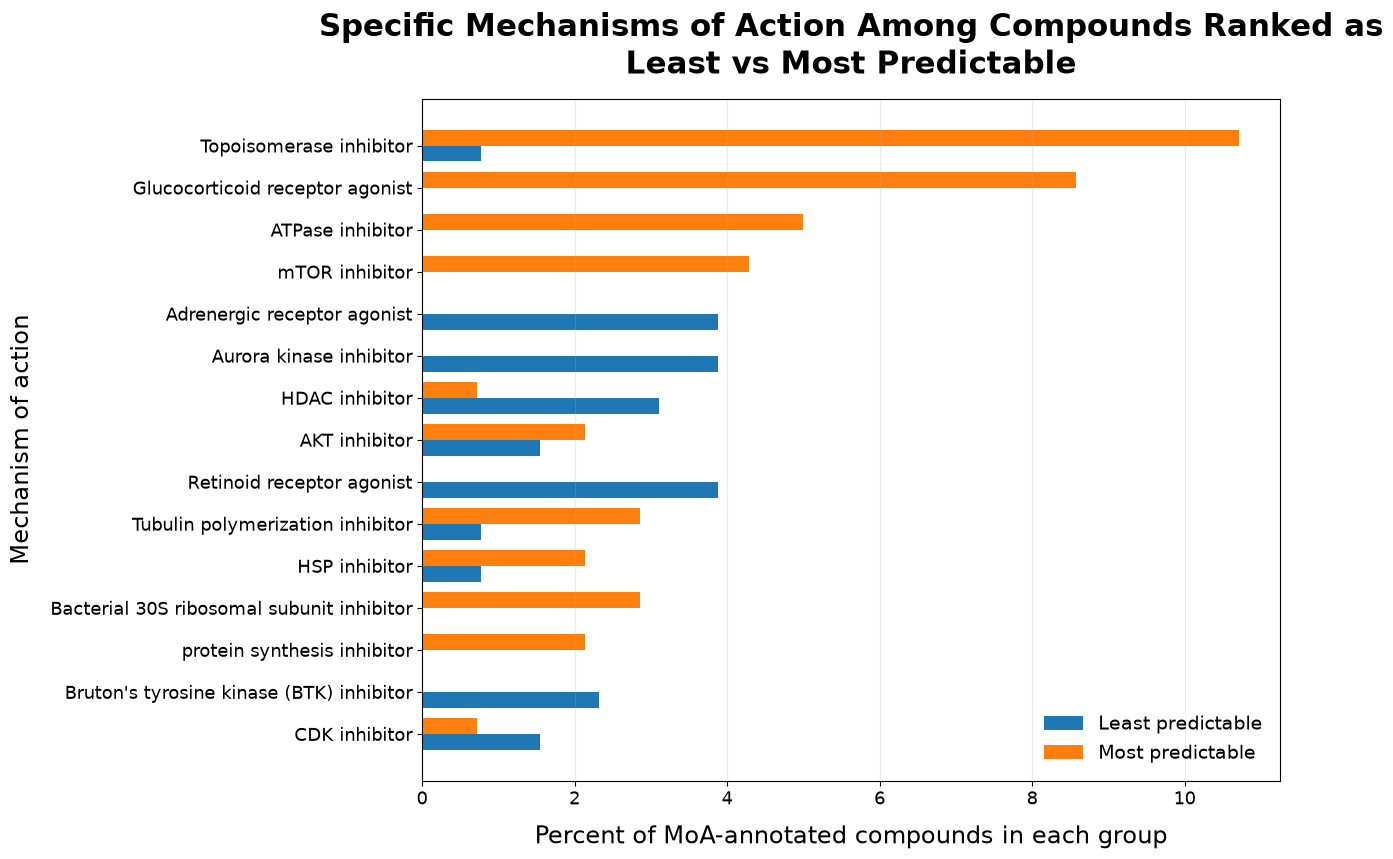


Saved cleaned MoA comparison:
/Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/step4_n20_specific_moa_comparison.csv

Saved cleaned MoA figure:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_specific_moa_least_vs_most.png


In [19]:
# Clean and standardize MoA labels

import re
import matplotlib.pyplot as plt


# Standardize names

CANONICAL_MOA_NAMES = {
    "topoisomerase inhibitor":
        "Topoisomerase inhibitor",

    "glucocorticoid receptor agonist":
        "Glucocorticoid receptor agonist",

    "mtor inhibitor":
        "mTOR inhibitor",

    "atpase inhibitor":
        "ATPase inhibitor",

    "hdac inhibitor":
        "HDAC inhibitor",

    "hsp inhibitor":
        "HSP inhibitor",

    "akt inhibitor":
        "AKT inhibitor",

    "pi3k inhibitor":
        "PI3K inhibitor",

    "ikk inhibitor":
        "IKK inhibitor",

    "hmgcr inhibitor":
        "HMGCR inhibitor",

    "bruton's tyrosine kinase (btk) inhibitor":
        "Bruton's tyrosine kinase (BTK) inhibitor",

    "bacterial 30s ribosomal subunit inhibitor":
        "Bacterial 30S ribosomal subunit inhibitor",

    "glycogen synthase kinase inhibitor":
        "Glycogen synthase kinase inhibitor",

    "aurora kinase inhibitor":
        "Aurora kinase inhibitor",

    "tubulin polymerization inhibitor":
        "Tubulin polymerization inhibitor",

    "retinoid receptor agonist":
        "Retinoid receptor agonist",

    "adrenergic receptor agonist":
        "Adrenergic receptor agonist",

    "inhibitors of signal transduction pathways":
        "Inhibitors of signal transduction pathways",

    "inhibitor/antagonist":
        "Inhibitor/antagonist",

    "activator/agonist":
        "Activator/agonist",

    "unclear":
        "Unclear",
}


def standardize_moa_name(value):
    """
    Standardize spacing, capitalization, and known acronym variants.
    """

    if pd.isna(value):
        return pd.NA

    cleaned = re.sub(
        r"\s+",
        " ",
        str(value).strip(),
    )

    key = cleaned.casefold()

    return CANONICAL_MOA_NAMES.get(
        key,
        cleaned,
    )


moa_long_clean = moa_long.copy()

moa_long_clean["moa_annotation"] = (
    moa_long_clean["moa_annotation"]
    .apply(standardize_moa_name)
)

moa_long_clean = (
    moa_long_clean
    .dropna(subset=["moa_annotation"])
    .drop_duplicates(
        subset=[
            "compound_embedding_row_index",
            "model_prediction_group",
            "moa_annotation",
        ]
    )
    .reset_index(drop=True)
)


# Remove vague/non-specific annotation categories

NON_SPECIFIC_MOAS = {
    "Unclear",
    "Inhibitor/antagonist",
    "Activator/agonist",
}

moa_long_specific = (
    moa_long_clean[
        ~moa_long_clean["moa_annotation"]
        .isin(NON_SPECIFIC_MOAS)
    ]
    .copy()
    .reset_index(drop=True)
)


print(
    "Annotations before cleaning:",
    len(moa_long),
)

print(
    "Annotations after standardization:",
    len(moa_long_clean),
)

print(
    "Specific annotations retained:",
    len(moa_long_specific),
)


# Count compounds with at least one specific MoA

annotated_group_sizes = (
    moa_long_specific
    .groupby("model_prediction_group")[
        "compound_embedding_row_index"
    ]
    .nunique()
    .reindex(extreme_groups)
)

print("\nCompounds with at least one specific MoA:")

display(
    annotated_group_sizes
    .rename("n_annotated_compounds")
    .reset_index()
)


# Count compounds carrying each specific MoA

moa_counts = pd.crosstab(
    index=(
        moa_long_specific["moa_annotation"]
        .to_numpy()
    ),
    columns=(
        moa_long_specific["model_prediction_group"]
        .to_numpy()
    ),
)

moa_counts.index.name = "moa_annotation"

moa_counts.columns.name = (
    "model_prediction_group"
)

moa_counts = moa_counts.reindex(
    columns=extreme_groups,
    fill_value=0,
)


# Build cleaned comparison table

moa_comparison = moa_counts.copy()

moa_comparison.columns = [
    "least_predictable_count",
    "most_predictable_count",
]

n_annotated_least = int(
    annotated_group_sizes["Least predictable"]
)

n_annotated_most = int(
    annotated_group_sizes["Most predictable"]
)

assert n_annotated_least > 0
assert n_annotated_most > 0


moa_comparison["least_predictable_percent"] = (
    100
    * moa_comparison["least_predictable_count"]
    / n_annotated_least
)

moa_comparison["most_predictable_percent"] = (
    100
    * moa_comparison["most_predictable_count"]
    / n_annotated_most
)

moa_comparison["total_extreme_count"] = (
    moa_comparison["least_predictable_count"]
    + moa_comparison["most_predictable_count"]
)

moa_comparison = (
    moa_comparison
    .sort_values(
        "total_extreme_count",
        ascending=False,
    )
    .reset_index()
)


print("\nCleaned MoA comparison:")

display(
    moa_comparison.head(25)
)


# Select MoAs for the cleaned figure

N_MOAS_TO_PLOT = 15

plot_table = (
    moa_comparison
    .head(N_MOAS_TO_PLOT)
    .sort_values(
        "total_extreme_count",
        ascending=True,
    )
    .copy()
)


# Create cleaned comparison figure

fig_height = max(
    8,
    0.58 * len(plot_table),
)

fig, ax = plt.subplots(
    figsize=(13, fig_height)
)

positions = np.arange(
    len(plot_table)
)

bar_height = 0.38

ax.barh(
    positions - bar_height / 2,
    plot_table["least_predictable_percent"],
    height=bar_height,
    label="Least predictable",
)

ax.barh(
    positions + bar_height / 2,
    plot_table["most_predictable_percent"],
    height=bar_height,
    label="Most predictable",
)

ax.set_yticks(
    positions
)

ax.set_yticklabels(
    plot_table["moa_annotation"],
    fontsize=13,
)

ax.set_xlabel(
    "Percent of MoA-annotated compounds in each group",
    fontsize=17,
    labelpad=12,
)

ax.set_ylabel(
    "Mechanism of action",
    fontsize=17,
    labelpad=12,
)

ax.set_title(
    "Specific Mechanisms of Action Among Compounds Ranked as\n"
    "Least vs Most Predictable",
    fontsize=22,
    fontweight="bold",
    pad=18,
)

ax.tick_params(
    axis="x",
    labelsize=13,
)

ax.grid(
    axis="x",
    alpha=0.25,
)

ax.legend(
    fontsize=14,
    frameon=False,
)

fig.tight_layout()


# Save cleaned outputs

CLEAN_MOA_COMPARISON_PATH = (
    OUTPUT_DIR
    / "step4_n20_specific_moa_comparison.csv"
)

CLEAN_MOA_LONG_PATH = (
    OUTPUT_DIR
    / "step4_n20_specific_moa_long.csv"
)

CLEAN_MOA_FIGURE_PATH = (
    FIG_DIR
    / "step4_n20_specific_moa_least_vs_most.png"
)

CLEAN_MOA_FIGURE_PDF_PATH = (
    FIG_DIR
    / "step4_n20_specific_moa_least_vs_most.pdf"
)

moa_comparison.to_csv(
    CLEAN_MOA_COMPARISON_PATH,
    index=False,
)

moa_long_specific.to_csv(
    CLEAN_MOA_LONG_PATH,
    index=False,
)

fig.savefig(
    CLEAN_MOA_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    CLEAN_MOA_FIGURE_PDF_PATH,
    bbox_inches="tight",
)

plt.show()


print("\nSaved cleaned MoA comparison:")
print(CLEAN_MOA_COMPARISON_PATH)

print("\nSaved cleaned MoA figure:")
print(CLEAN_MOA_FIGURE_PATH)

In [15]:
# MoA analysis, Step 3

from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests


# Settings


MIN_TOTAL_COMPOUNDS_PER_MOA = 5

n_least = int(
    annotated_group_sizes["Least predictable"]
)

n_most = int(
    annotated_group_sizes["Most predictable"]
)

print("Specific-MoA analysis universe:")
print(f"Least predictable: {n_least} compounds")
print(f"Most predictable:  {n_most} compounds")


# Fisher's exact test for each MoA

enrichment_rows = []

for _, row in moa_comparison.iterrows():

    moa_name = row["moa_annotation"]

    least_count = int(
        row["least_predictable_count"]
    )

    most_count = int(
        row["most_predictable_count"]
    )

    total_count = (
        least_count
        + most_count
    )

    if total_count < MIN_TOTAL_COMPOUNDS_PER_MOA:
        continue

  
    contingency_table = [
        [
            most_count,
            n_most - most_count,
        ],
        [
            least_count,
            n_least - least_count,
        ],
    ]

    odds_ratio, p_value = fisher_exact(
        contingency_table,
        alternative="two-sided",
    )

   
    corrected_odds_ratio = (
        (most_count + 0.5)
        * (n_least - least_count + 0.5)
        / (
            (n_most - most_count + 0.5)
            * (least_count + 0.5)
        )
    )

    log2_odds_ratio = np.log2(
        corrected_odds_ratio
    )

    if log2_odds_ratio > 0:
        direction = "More common in most predictable"
    elif log2_odds_ratio < 0:
        direction = "More common in least predictable"
    else:
        direction = "No difference"

    enrichment_rows.append({
        "moa": moa_name,
        "least_predictable_count": least_count,
        "least_predictable_total": n_least,
        "most_predictable_count": most_count,
        "most_predictable_total": n_most,
        "total_compounds_with_moa": total_count,
        "corrected_odds_ratio": corrected_odds_ratio,
        "log2_odds_ratio": log2_odds_ratio,
        "p_value": p_value,
        "direction": direction,
    })


moa_enrichment = pd.DataFrame(
    enrichment_rows
)


# Correct for testing multiple MoAs

if len(moa_enrichment) > 0:

    moa_enrichment["adjusted_p_value"] = (
        multipletests(
            moa_enrichment["p_value"],
            method="fdr_bh",
        )[1]
    )

    moa_enrichment["significant_fdr_0_05"] = (
        moa_enrichment["adjusted_p_value"]
        < 0.05
    )

    moa_enrichment = (
        moa_enrichment
        .sort_values(
            [
                "adjusted_p_value",
                "p_value",
            ]
        )
        .reset_index(drop=True)
    )

else:

    moa_enrichment["adjusted_p_value"] = pd.Series(
        dtype=float
    )

    moa_enrichment["significant_fdr_0_05"] = pd.Series(
        dtype=bool
    )


# Save and display

MOA_ENRICHMENT_PATH = (
    OUTPUT_DIR
    / "step4_n20_specific_moa_enrichment.csv"
)

moa_enrichment.to_csv(
    MOA_ENRICHMENT_PATH,
    index=False,
)


print("\nEnrichment analysis complete")
print("-" * 55)

print(
    "MoAs tested:",
    len(moa_enrichment),
)

print(
    "Unadjusted p < 0.05:",
    int(
        (
            moa_enrichment["p_value"] < 0.05
        ).sum()
    ),
)

print(
    "FDR-adjusted p < 0.05:",
    int(
        moa_enrichment[
            "significant_fdr_0_05"
        ].sum()
    ),
)

display(
    moa_enrichment[
        [
            "moa",
            "least_predictable_count",
            "most_predictable_count",
            "log2_odds_ratio",
            "p_value",
            "adjusted_p_value",
            "direction",
        ]
    ]
)

print("\nSaved enrichment results:")
print(MOA_ENRICHMENT_PATH)

Specific-MoA analysis universe:
Least predictable: 129 compounds
Most predictable:  140 compounds

Enrichment analysis complete
-------------------------------------------------------
MoAs tested: 10
Unadjusted p < 0.05: 7
FDR-adjusted p < 0.05: 7


,moa,least_predictable_count,most_predictable_count,log2_odds_ratio,p_value,adjusted_p_value,direction
0,Glucocorticoid receptor agonist,0,12,4.655040,0.000424,0.002124,More common in most predictable
1,Topoisomerase inhibitor,1,15,3.403315,0.000425,0.002124,More common in most predictable
2,ATPase inhibitor,0,7,3.863003,0.014955,0.040570,More common in most predictable
3,Retinoid receptor agonist,5,0,-3.633856,0.024342,0.040570,More common in least predictable
4,Aurora kinase inhibitor,5,0,-3.633856,0.024342,0.040570,More common in least predictable
5,Adrenergic receptor agonist,5,0,-3.633856,0.024342,0.040570,More common in least predictable
6,mTOR inhibitor,0,6,3.645786,0.030291,0.043273,More common in most predictable
7,HDAC inhibitor,4,1,-1.737540,0.197535,0.246919,More common in least predictable
8,Tubulin polymerization inhibitor,1,4,1.497830,0.372429,0.413811,More common in most predictable
9,AKT inhibitor,2,3,0.376492,1.000000,1.000000,More common in most predictable



Saved enrichment results:
/Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/step4_n20_specific_moa_enrichment.csv


In [14]:
%pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 13.8 MB/s  0:00:00.5 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] 1/2 [statsmodels]
Note: you may need to restart the kernel to use updated packages.


In [20]:
# Observed MoA analysis, Step 1

# Preserve 
predicted_moa_enrichment = moa_enrichment.copy()



# Divide compounds into quintiles using ACTUAL predictability


observed_group_labels = [
    "Lowest observed predictability",
    "Lower",
    "Middle",
    "Higher",
    "Highest observed predictability",
]

observed_rank_for_binning = (
    moa_results["actual_predictability"]
    .rank(
        method="first",
        ascending=True,
    )
)

moa_results["observed_predictability_group"] = pd.qcut(
    observed_rank_for_binning,
    q=5,
    labels=observed_group_labels,
)

moa_results["observed_predictability_group"] = pd.Categorical(
    moa_results["observed_predictability_group"],
    categories=observed_group_labels,
    ordered=True,
)



# Keep only the lowest and highest observed quintiles


observed_extreme_groups = [
    "Lowest observed predictability",
    "Highest observed predictability",
]

observed_extreme_results = (
    moa_results[
        moa_results["observed_predictability_group"]
        .isin(observed_extreme_groups)
    ]
    .copy()
)

observed_extreme_results[
    "observed_predictability_group"
] = (
    observed_extreme_results[
        "observed_predictability_group"
    ]
    .astype(str)
)



# Split and standardize MoA annotations


observed_moa_long = (
    observed_extreme_results[
        [
            "compound_embedding_row_index",
            "compound_name",
            "observed_predictability_group",
            "actual_predictability",
            "moa",
        ]
    ]
    .assign(
        moa_annotation=lambda frame:
            frame["moa"].apply(
                split_moa_annotations
            )
    )
    .explode("moa_annotation")
    .dropna(subset=["moa_annotation"])
    .copy()
)

observed_moa_long["moa_annotation"] = (
    observed_moa_long["moa_annotation"]
    .apply(standardize_moa_name)
)

# Remove vague MoA categories
observed_moa_long = (
    observed_moa_long[
        ~observed_moa_long["moa_annotation"]
        .isin(NON_SPECIFIC_MOAS)
    ]
    .drop_duplicates(
        subset=[
            "compound_embedding_row_index",
            "observed_predictability_group",
            "moa_annotation",
        ]
    )
    .reset_index(drop=True)
)



# Count compounds with at least one specific MoA


observed_annotated_group_sizes = (
    observed_moa_long
    .groupby(
        "observed_predictability_group"
    )[
        "compound_embedding_row_index"
    ]
    .nunique()
    .reindex(observed_extreme_groups)
)


print("Observed-predictability extreme groups:")
print(
    observed_extreme_results[
        "observed_predictability_group"
    ]
    .value_counts()
)

print(
    "\nCompounds with at least one specific MoA:"
)

display(
    observed_annotated_group_sizes
    .rename("n_annotated_compounds")
    .reset_index()
)

display(
    observed_extreme_results[
        [
            "compound_name",
            "actual_predictability",
            "observed_predictability_group",
            "moa",
        ]
    ]
    .sort_values(
        "actual_predictability",
        ascending=False,
    )
    .head(15)
)

Observed-predictability extreme groups:
observed_predictability_group
Lowest observed predictability     161
Highest observed predictability    160
Name: count, dtype: int64

Compounds with at least one specific MoA:


,observed_predictability_group,n_annotated_compounds
0,Lowest observed predictability,123
1,Highest observed predictability,143


,compound_name,actual_predictability,observed_predictability_group,moa
247,Cephaeline; cephaeline,1.000000,Highest observed predictability,<NA>
239,BRD-K68202742; Trichostatin A,1.000000,Highest observed predictability,HDAC inhibitor
266,"Tanespimycin; [(4E,6Z,8S,9S,10E,12S,13R,14S,16...",0.995693,Highest observed predictability,CHK1 Expression Inhibitors;Inhibitors of Signa...
262,"(7R,9S)-9-acetyl-7-[[(2R,4S,5S,6S)-4-amino-5-h...",0.993675,Highest observed predictability,RNA synthesis inhibitor | topoisomerase inhibi...
257,XL-888; XL888,0.992940,Highest observed predictability,<NA>
261,"3-[(1R,3R,5S,8R,9S,10R,11R,13R,14S,17R)-1,5,11...",0.988827,Highest observed predictability,ATPase inhibitor
265,topotecan,0.988131,Highest observed predictability,Topoisomerase inhibitor
263,Geldanamycin; geldanamycin,0.987674,Highest observed predictability,HSP inhibitor
267,Epirubicin; epirubicin,0.983716,Highest observed predictability,Topoisomerase inhibitor; topoisomerase inhibitor
331,Abexinostat; PCI-24781,0.979120,Highest observed predictability,HDAC inhibitor


Most common MoAs among compounds with extreme observed predictability:


,moa_annotation,lowest_observed_count,highest_observed_count,lowest_observed_percent,highest_observed_percent,total_extreme_count
0,Topoisomerase inhibitor,1,16,0.813008,11.188811,17
1,HDAC inhibitor,1,11,0.813008,7.692308,12
2,HSP inhibitor,3,6,2.439024,4.195804,9
3,mTOR inhibitor,0,9,0.000000,6.293706,9
4,Glucocorticoid receptor agonist,1,6,0.813008,4.195804,7
5,ATPase inhibitor,1,5,0.813008,3.496503,6
6,Tubulin polymerization inhibitor,0,6,0.000000,4.195804,6
7,PI3K inhibitor,2,4,1.626016,2.797203,6
8,CDK inhibitor,2,3,1.626016,2.097902,5
9,protein synthesis inhibitor,1,4,0.813008,2.797203,5


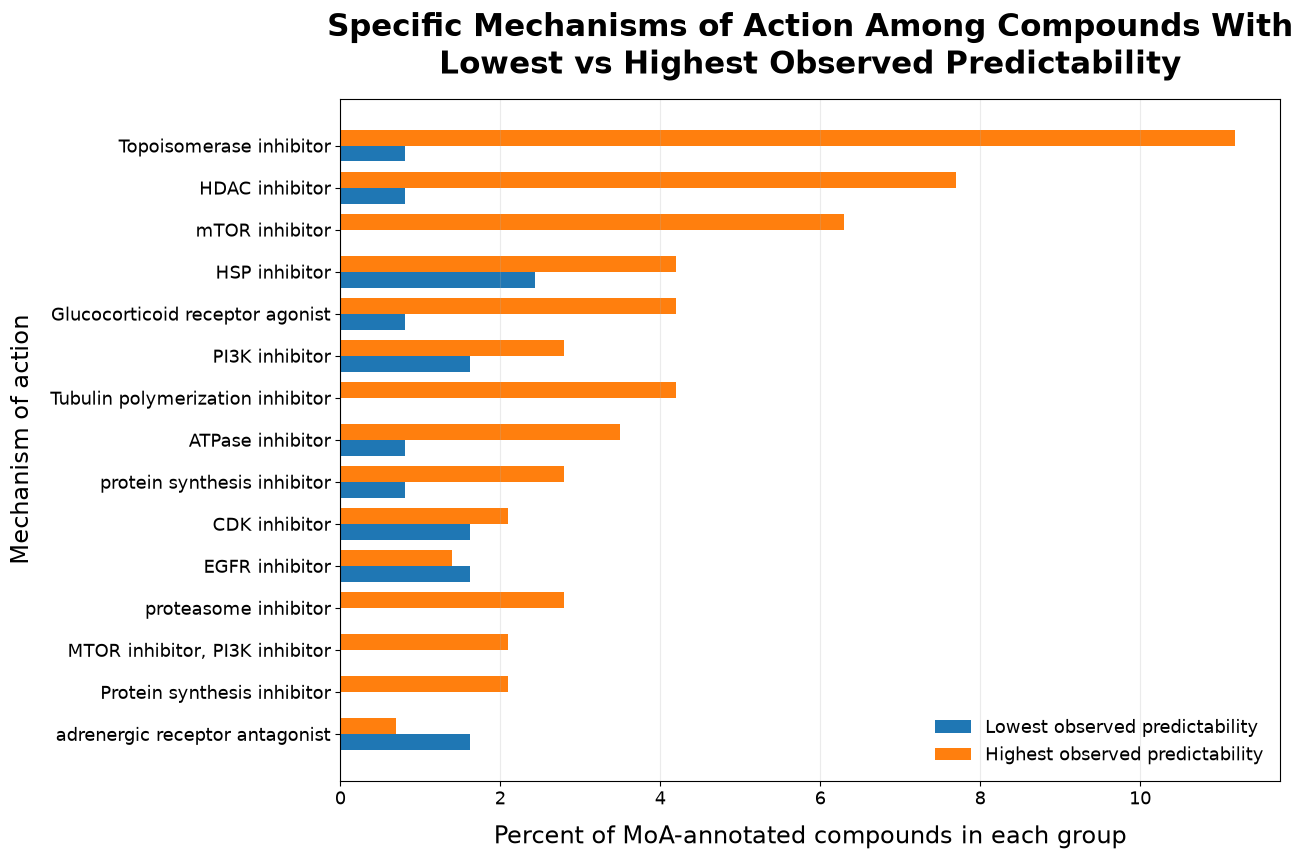


Saved observed MoA table:
/Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/step4_n20_observed_specific_moa_comparison.csv

Saved observed MoA figure:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_observed_specific_moa_lowest_vs_highest.png


In [21]:
# Observed MoA analysis, Step 2

import matplotlib.pyplot as plt



# Count compounds carrying each MoA


observed_moa_counts = pd.crosstab(
    index=(
        observed_moa_long[
            "moa_annotation"
        ]
        .to_numpy()
    ),
    columns=(
        observed_moa_long[
            "observed_predictability_group"
        ]
        .to_numpy()
    ),
)

observed_moa_counts.index.name = (
    "moa_annotation"
)

observed_moa_counts.columns.name = (
    "observed_predictability_group"
)

observed_moa_counts = observed_moa_counts.reindex(
    columns=observed_extreme_groups,
    fill_value=0,
)



# Create comparison table


observed_moa_comparison = (
    observed_moa_counts.copy()
)

observed_moa_comparison.columns = [
    "lowest_observed_count",
    "highest_observed_count",
]

n_observed_low = int(
    observed_annotated_group_sizes[
        "Lowest observed predictability"
    ]
)

n_observed_high = int(
    observed_annotated_group_sizes[
        "Highest observed predictability"
    ]
)

assert n_observed_low > 0
assert n_observed_high > 0


observed_moa_comparison[
    "lowest_observed_percent"
] = (
    100
    * observed_moa_comparison[
        "lowest_observed_count"
    ]
    / n_observed_low
)

observed_moa_comparison[
    "highest_observed_percent"
] = (
    100
    * observed_moa_comparison[
        "highest_observed_count"
    ]
    / n_observed_high
)

observed_moa_comparison[
    "total_extreme_count"
] = (
    observed_moa_comparison[
        "lowest_observed_count"
    ]
    + observed_moa_comparison[
        "highest_observed_count"
    ]
)

observed_moa_comparison = (
    observed_moa_comparison
    .sort_values(
        "total_extreme_count",
        ascending=False,
    )
    .reset_index()
)


print(
    "Most common MoAs among compounds with "
    "extreme observed predictability:"
)

display(
    observed_moa_comparison.head(25)
)


# Select MoAs to show

N_MOAS_TO_PLOT = 15

observed_plot_table = (
    observed_moa_comparison
    .head(N_MOAS_TO_PLOT)
    .sort_values(
        "total_extreme_count",
        ascending=True,
    )
    .copy()
)


# Create bar graph

fig_height = max(
    8,
    0.58 * len(observed_plot_table),
)

fig, ax = plt.subplots(
    figsize=(13, fig_height)
)

positions = np.arange(
    len(observed_plot_table)
)

bar_height = 0.38

ax.barh(
    positions - bar_height / 2,
    observed_plot_table[
        "lowest_observed_percent"
    ],
    height=bar_height,
    label="Lowest observed predictability",
)

ax.barh(
    positions + bar_height / 2,
    observed_plot_table[
        "highest_observed_percent"
    ],
    height=bar_height,
    label="Highest observed predictability",
)

ax.set_yticks(
    positions
)

ax.set_yticklabels(
    observed_plot_table[
        "moa_annotation"
    ],
    fontsize=13,
)

ax.set_xlabel(
    "Percent of MoA-annotated compounds in each group",
    fontsize=17,
    labelpad=12,
)

ax.set_ylabel(
    "Mechanism of action",
    fontsize=17,
    labelpad=12,
)

ax.set_title(
    "Specific Mechanisms of Action Among Compounds With\n"
    "Lowest vs Highest Observed Predictability",
    fontsize=22,
    fontweight="bold",
    pad=18,
)

ax.tick_params(
    axis="x",
    labelsize=13,
)

ax.grid(
    axis="x",
    alpha=0.25,
)

ax.legend(
    fontsize=13,
    frameon=False,
)

fig.tight_layout()


# Save outputs

OBSERVED_MOA_COMPARISON_PATH = (
    OUTPUT_DIR
    / "step4_n20_observed_specific_moa_comparison.csv"
)

OBSERVED_MOA_LONG_PATH = (
    OUTPUT_DIR
    / "step4_n20_observed_specific_moa_long.csv"
)

OBSERVED_MOA_FIGURE_PATH = (
    FIG_DIR
    / "step4_n20_observed_specific_moa_lowest_vs_highest.png"
)

OBSERVED_MOA_FIGURE_PDF_PATH = (
    FIG_DIR
    / "step4_n20_observed_specific_moa_lowest_vs_highest.pdf"
)

observed_moa_comparison.to_csv(
    OBSERVED_MOA_COMPARISON_PATH,
    index=False,
)

observed_moa_long.to_csv(
    OBSERVED_MOA_LONG_PATH,
    index=False,
)

fig.savefig(
    OBSERVED_MOA_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    OBSERVED_MOA_FIGURE_PDF_PATH,
    bbox_inches="tight",
)

plt.show()


print("\nSaved observed MoA table:")
print(OBSERVED_MOA_COMPARISON_PATH)

print("\nSaved observed MoA figure:")
print(OBSERVED_MOA_FIGURE_PATH)

In [22]:
# Observed MoA analysis, Step 3

from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests


MIN_TOTAL_COMPOUNDS_PER_MOA = 5

observed_enrichment_rows = []


for _, row in observed_moa_comparison.iterrows():

    moa_name = row["moa_annotation"]

    low_count = int(
        row["lowest_observed_count"]
    )

    high_count = int(
        row["highest_observed_count"]
    )

    total_count = (
        low_count
        + high_count
    )

    if total_count < MIN_TOTAL_COMPOUNDS_PER_MOA:
        continue

    contingency_table = [
        [
            high_count,
            n_observed_high - high_count,
        ],
        [
            low_count,
            n_observed_low - low_count,
        ],
    ]

    odds_ratio, p_value = fisher_exact(
        contingency_table,
        alternative="two-sided",
    )

    corrected_odds_ratio = (
        (high_count + 0.5)
        * (n_observed_low - low_count + 0.5)
        / (
            (n_observed_high - high_count + 0.5)
            * (low_count + 0.5)
        )
    )

    log2_odds_ratio = np.log2(
        corrected_odds_ratio
    )

    if log2_odds_ratio > 0:

        direction = (
            "More common in highest observed"
        )

    elif log2_odds_ratio < 0:

        direction = (
            "More common in lowest observed"
        )

    else:

        direction = "No difference"

    observed_enrichment_rows.append({
        "moa": moa_name,
        "lowest_observed_count": low_count,
        "lowest_observed_total": n_observed_low,
        "highest_observed_count": high_count,
        "highest_observed_total": n_observed_high,
        "total_compounds_with_moa": total_count,
        "fisher_odds_ratio": odds_ratio,
        "corrected_odds_ratio": corrected_odds_ratio,
        "log2_odds_ratio": log2_odds_ratio,
        "p_value": p_value,
        "direction": direction,
    })


observed_moa_enrichment = pd.DataFrame(
    observed_enrichment_rows
)


if len(observed_moa_enrichment) > 0:

    observed_moa_enrichment[
        "adjusted_p_value"
    ] = multipletests(
        observed_moa_enrichment[
            "p_value"
        ],
        method="fdr_bh",
    )[1]

    observed_moa_enrichment[
        "significant_fdr_0_05"
    ] = (
        observed_moa_enrichment[
            "adjusted_p_value"
        ]
        < 0.05
    )

    observed_moa_enrichment = (
        observed_moa_enrichment
        .sort_values(
            [
                "adjusted_p_value",
                "p_value",
            ]
        )
        .reset_index(drop=True)
    )


OBSERVED_MOA_ENRICHMENT_PATH = (
    OUTPUT_DIR
    / "step4_n20_observed_specific_moa_enrichment.csv"
)

observed_moa_enrichment.to_csv(
    OBSERVED_MOA_ENRICHMENT_PATH,
    index=False,
)


print(
    "MoAs tested:",
    len(observed_moa_enrichment),
)

print(
    "Unadjusted p < 0.05:",
    int(
        (
            observed_moa_enrichment[
                "p_value"
            ]
            < 0.05
        ).sum()
    ),
)

print(
    "FDR-adjusted p < 0.05:",
    int(
        observed_moa_enrichment[
            "significant_fdr_0_05"
        ].sum()
    ),
)

display(
    observed_moa_enrichment[
        [
            "moa",
            "lowest_observed_count",
            "highest_observed_count",
            "log2_odds_ratio",
            "p_value",
            "adjusted_p_value",
            "direction",
        ]
    ]
)

print("\nSaved observed enrichment results:")
print(OBSERVED_MOA_ENRICHMENT_PATH)

MoAs tested: 10
Unadjusted p < 0.05: 4
FDR-adjusted p < 0.05: 3


,moa,lowest_observed_count,highest_observed_count,log2_odds_ratio,p_value,adjusted_p_value,direction
0,Topoisomerase inhibitor,1,16,3.401716,0.000567,0.005671,More common in highest observed
1,mTOR inhibitor,0,9,4.124832,0.004147,0.020737,More common in highest observed
2,HDAC inhibitor,1,11,2.825389,0.006834,0.022781,More common in highest observed
3,Tubulin polymerization inhibitor,0,6,3.545519,0.032116,0.080289,More common in highest observed
4,Glucocorticoid receptor agonist,1,6,1.948827,0.127495,0.254989,More common in highest observed
5,ATPase inhibitor,1,5,1.697365,0.221448,0.369081,More common in highest observed
6,protein synthesis inhibitor,1,4,1.397479,0.377410,0.539157,More common in highest observed
7,HSP inhibitor,3,6,0.702686,0.511717,0.639646,More common in highest observed
8,PI3K inhibitor,2,4,0.648688,0.689333,0.765926,More common in highest observed
9,CDK inhibitor,2,3,0.275813,1.000000,1.000000,More common in highest observed



Saved observed enrichment results:
/Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/step4_n20_observed_specific_moa_enrichment.csv


In [23]:
# Compare 

predicted_comparison = (
    predicted_moa_enrichment[
        [
            "moa",
            "log2_odds_ratio",
            "adjusted_p_value",
            "direction",
        ]
    ]
    .rename(
        columns={
            "log2_odds_ratio":
                "predicted_log2_odds_ratio",
            "adjusted_p_value":
                "predicted_adjusted_p_value",
            "direction":
                "predicted_direction",
        }
    )
)

observed_comparison = (
    observed_moa_enrichment[
        [
            "moa",
            "log2_odds_ratio",
            "adjusted_p_value",
            "direction",
        ]
    ]
    .rename(
        columns={
            "log2_odds_ratio":
                "observed_log2_odds_ratio",
            "adjusted_p_value":
                "observed_adjusted_p_value",
            "direction":
                "observed_direction",
        }
    )
)

model_observed_moa_comparison = (
    predicted_comparison
    .merge(
        observed_comparison,
        on="moa",
        how="outer",
    )
)


model_observed_moa_comparison[
    "significant_in_predicted_analysis"
] = (
    model_observed_moa_comparison[
        "predicted_adjusted_p_value"
    ]
    < 0.05
)

model_observed_moa_comparison[
    "significant_in_observed_analysis"
] = (
    model_observed_moa_comparison[
        "observed_adjusted_p_value"
    ]
    < 0.05
)

model_observed_moa_comparison[
    "same_effect_direction"
] = (
    np.sign(
        model_observed_moa_comparison[
            "predicted_log2_odds_ratio"
        ]
    )
    ==
    np.sign(
        model_observed_moa_comparison[
            "observed_log2_odds_ratio"
        ]
    )
)

model_observed_moa_comparison = (
    model_observed_moa_comparison
    .sort_values(
        [
            "significant_in_observed_analysis",
            "observed_adjusted_p_value",
        ],
        ascending=[
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)


MODEL_OBSERVED_COMPARISON_PATH = (
    OUTPUT_DIR
    / "step4_n20_predicted_vs_observed_moa_comparison.csv"
)

model_observed_moa_comparison.to_csv(
    MODEL_OBSERVED_COMPARISON_PATH,
    index=False,
)


display(
    model_observed_moa_comparison
)

print("\nSaved model-versus-observed comparison:")
print(MODEL_OBSERVED_COMPARISON_PATH)

,moa,predicted_log2_odds_ratio,predicted_adjusted_p_value,predicted_direction,observed_log2_odds_ratio,observed_adjusted_p_value,observed_direction,significant_in_predicted_analysis,significant_in_observed_analysis,same_effect_direction
0,Topoisomerase inhibitor,3.403315,0.002124,More common in most predictable,3.401716,0.005671,More common in highest observed,True,True,True
1,mTOR inhibitor,3.645786,0.043273,More common in most predictable,4.124832,0.020737,More common in highest observed,True,True,True
2,HDAC inhibitor,-1.737540,0.246919,More common in least predictable,2.825389,0.022781,More common in highest observed,False,True,False
3,Tubulin polymerization inhibitor,1.497830,0.413811,More common in most predictable,3.545519,0.080289,More common in highest observed,False,False,True
4,Glucocorticoid receptor agonist,4.655040,0.002124,More common in most predictable,1.948827,0.254989,More common in highest observed,True,False,True
5,ATPase inhibitor,3.863003,0.040570,More common in most predictable,1.697365,0.369081,More common in highest observed,True,False,True
6,protein synthesis inhibitor,NaN,NaN,NaN,1.397479,0.539157,More common in highest observed,False,False,False
7,HSP inhibitor,NaN,NaN,NaN,0.702686,0.639646,More common in highest observed,False,False,False
8,PI3K inhibitor,NaN,NaN,NaN,0.648688,0.765926,More common in highest observed,False,False,False
9,CDK inhibitor,NaN,NaN,NaN,0.275813,1.000000,More common in highest observed,False,False,False



Saved model-versus-observed comparison:
/Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/step4_n20_predicted_vs_observed_moa_comparison.csv


In [24]:
# Rebuild clean MoA annotations for both predicted and observed analyses

import re
import numpy as np
import pandas as pd


# Values that should not be treated as real MoA annotations

MISSING_MOA_VALUES = {
    "",
    "nan",
    "none",
    "<na>",
    "na",
    "n/a",
    "-",
}


NON_SPECIFIC_MOAS = {
    "Unclear",
    "Inhibitor/antagonist",
    "Activator/agonist",
}


# Canonical names for common annotations and acronyms

CANONICAL_MOA_NAMES = {
    "akt inhibitor":
        "AKT inhibitor",

    "atpase inhibitor":
        "ATPase inhibitor",

    "aurora kinase inhibitor":
        "Aurora kinase inhibitor",

    "bacterial 30s ribosomal subunit inhibitor":
        "Bacterial 30S ribosomal subunit inhibitor",

    "bruton's tyrosine kinase (btk) inhibitor":
        "Bruton's tyrosine kinase (BTK) inhibitor",

    "cdk inhibitor":
        "CDK inhibitor",

    "dna polymerase inhibitor":
        "DNA polymerase inhibitor",

    "dopamine receptor antagonist":
        "Dopamine receptor antagonist",

    "egfr inhibitor":
        "EGFR inhibitor",

    "flt3 inhibitor":
        "FLT3 inhibitor",

    "glucocorticoid receptor agonist":
        "Glucocorticoid receptor agonist",

    "glycogen synthase kinase inhibitor":
        "Glycogen synthase kinase inhibitor",

    "hdac inhibitor":
        "HDAC inhibitor",

    "hmgcr inhibitor":
        "HMGCR inhibitor",

    "hsp inhibitor":
        "HSP inhibitor",

    "ikk inhibitor":
        "IKK inhibitor",

    "inhibitors of signal transduction pathways":
        "Inhibitors of signal transduction pathways",

    "map kinase inhibitor":
        "MAP kinase inhibitor",

    "mek inhibitor":
        "MEK inhibitor",

    "microtubule inhibitor":
        "Microtubule inhibitor",

    "mtor inhibitor":
        "mTOR inhibitor",

    "pi3k inhibitor":
        "PI3K inhibitor",

    "protein synthesis inhibitor":
        "Protein synthesis inhibitor",

    "proteasome inhibitor":
        "Proteasome inhibitor",

    "retinoid receptor agonist":
        "Retinoid receptor agonist",

    "rna polymerase inhibitor":
        "RNA polymerase inhibitor",

    "topoisomerase inhibitor":
        "Topoisomerase inhibitor",

    "tubulin inhibitor":
        "Tubulin inhibitor",

    "tubulin polymerization inhibitor":
        "Tubulin polymerization inhibitor",

    "tyrosine kinase inhibitor":
        "Tyrosine kinase inhibitor",

    "adrenergic receptor agonist":
        "Adrenergic receptor agonist",

    "adrenergic receptor antagonist":
        "Adrenergic receptor antagonist",

    "inhibitor/antagonist":
        "Inhibitor/antagonist",

    "activator/agonist":
        "Activator/agonist",

    "unclear":
        "Unclear",
}


# Universal MoA parser

def parse_and_standardize_moas(value):
    """
    Split one compound's MoA field into clean, distinct annotations.

    The source registry may join annotations with:
    - semicolons
    - vertical pipes
    - commas

    Capitalization and known acronym variants standardized.
    """

    if pd.isna(value):
        return []

    text = str(value).strip()

    if text.casefold() in MISSING_MOA_VALUES:
        return []

    # Normalize unusual separators before splitting
    text = (
        text
        .replace("\n", ";")
        .replace("｜", "|")
    )

    raw_annotations = re.split(
        r"\s*[;|,]\s*",
        text,
    )

    cleaned_annotations = []

    for annotation in raw_annotations:

        annotation = re.sub(
            r"\s+",
            " ",
            annotation,
        ).strip()

        if not annotation:
            continue

        annotation_key = annotation.casefold()

        if annotation_key in MISSING_MOA_VALUES:
            continue

        canonical_annotation = (
            CANONICAL_MOA_NAMES.get(
                annotation_key,
                annotation,
            )
        )

        if canonical_annotation in NON_SPECIFIC_MOAS:
            continue

        cleaned_annotations.append(
            canonical_annotation
        )

    # Prevent one compound from being counted twice for the same MoA
    return sorted(
        set(cleaned_annotations)
    )


# Recreate predicted groups from out-of-fold model predictions

predicted_group_labels = [
    "Least predictable",
    "Lower",
    "Middle",
    "Higher",
    "Most predictable",
]

predicted_rank = (
    moa_results["predicted_predictability"]
    .rank(
        method="first",
        ascending=True,
    )
)

moa_results["model_prediction_group"] = pd.qcut(
    predicted_rank,
    q=5,
    labels=predicted_group_labels,
)


# Recreate observed groups from actual Step 3 scores

observed_group_labels = [
    "Lowest observed predictability",
    "Lower",
    "Middle",
    "Higher",
    "Highest observed predictability",
]

observed_rank = (
    moa_results["actual_predictability"]
    .rank(
        method="first",
        ascending=True,
    )
)

moa_results["observed_predictability_group"] = pd.qcut(
    observed_rank,
    q=5,
    labels=observed_group_labels,
)


# Create one clean long-format MoA table

all_moa_long = (
    moa_results[
        [
            "compound_embedding_row_index",
            "compound_name",
            "n_profiles",
            "actual_predictability",
            "predicted_predictability",
            "model_prediction_group",
            "observed_predictability_group",
            "moa",
        ]
    ]
    .assign(
        moa_annotation=lambda frame:
            frame["moa"].apply(
                parse_and_standardize_moas
            )
    )
    .explode("moa_annotation")
    .dropna(subset=["moa_annotation"])
    .copy()
)

all_moa_long["moa_annotation"] = (
    all_moa_long["moa_annotation"]
    .astype(str)
    .str.strip()
)

all_moa_long = (
    all_moa_long
    .drop_duplicates(
        subset=[
            "compound_embedding_row_index",
            "moa_annotation",
        ]
    )
    .reset_index(drop=True)
)


# Verify that combined labels were actually separated

remaining_separator_mask = (
    all_moa_long["moa_annotation"]
    .str.contains(
        r"[;|,]",
        regex=True,
        na=False,
    )
)

remaining_combined_labels = (
    all_moa_long.loc[
        remaining_separator_mask,
        "moa_annotation",
    ]
    .value_counts()
)

print("Clean MoA table created")
print("-" * 55)

print(
    "Compounds with at least one specific MoA:",
    all_moa_long[
        "compound_embedding_row_index"
    ].nunique(),
)

print(
    "Unique standardized MoAs:",
    all_moa_long[
        "moa_annotation"
    ].nunique(),
)

print(
    "Annotations still containing separators:",
    int(remaining_separator_mask.sum()),
)

if len(remaining_combined_labels) > 0:
    display(
        remaining_combined_labels
        .rename("count")
        .reset_index()
    )

else:
    print(
        "No semicolon-, pipe-, or comma-combined labels remain."
    )


print("\nMost common cleaned MoAs:")

display(
    all_moa_long[
        "moa_annotation"
    ]
    .value_counts()
    .head(30)
    .rename("compound_annotations")
    .reset_index()
)

Clean MoA table created
-------------------------------------------------------
Compounds with at least one specific MoA: 660
Unique standardized MoAs: 478
Annotations still containing separators: 0
No semicolon-, pipe-, or comma-combined labels remain.

Most common cleaned MoAs:


,moa_annotation,compound_annotations
0,Topoisomerase inhibitor,22
1,Glucocorticoid receptor agonist,21
2,PI3K inhibitor,19
3,EGFR inhibitor,19
4,HDAC inhibitor,19
5,Aurora kinase inhibitor,17
6,CDK inhibitor,17
7,mTOR inhibitor,17
8,Tubulin polymerization inhibitor,16
9,VEGFR inhibitor,15


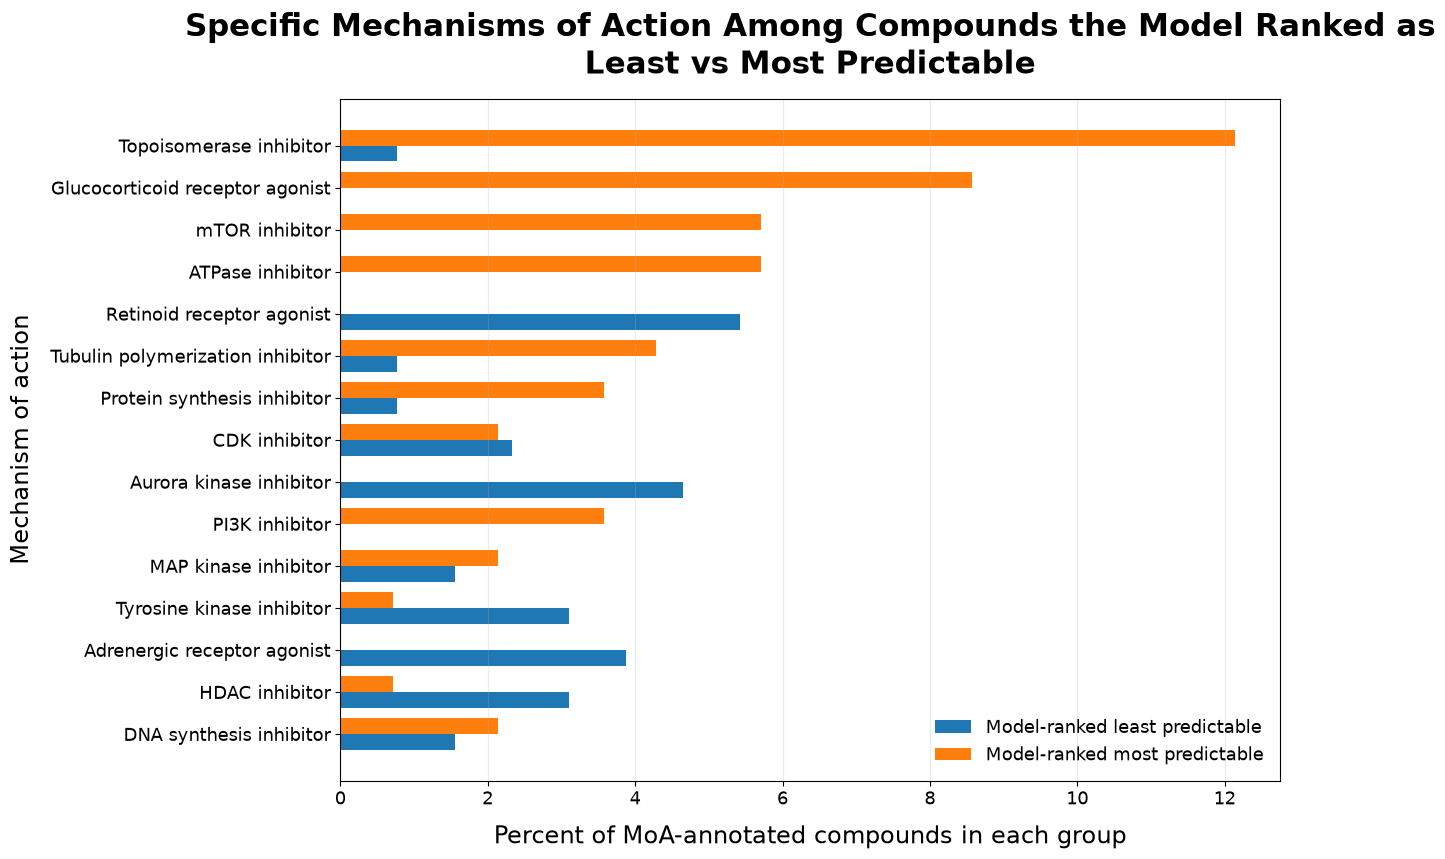


Specific Mechanisms of Action Among Compounds the Model Ranked as Least vs Most Predictable
Model-ranked least predictable: 129 MoA-annotated compounds
Model-ranked most predictable: 140 MoA-annotated compounds
MoAs formally tested: 18
FDR-significant MoAs: 6


,moa,low_count,high_count,log2_odds_ratio,p_value,adjusted_p_value,direction
0,Topoisomerase inhibitor,1,17,3.601578,0.000111,0.001997,More common in Model-ranked most predictable
1,Glucocorticoid receptor agonist,0,12,4.655040,0.000424,0.003815,More common in Model-ranked most predictable
2,Retinoid receptor agonist,7,0,-4.104679,0.005347,0.026522,More common in Model-ranked least predictable
3,ATPase inhibitor,0,8,4.054423,0.007367,0.026522,More common in Model-ranked most predictable
4,mTOR inhibitor,0,8,4.054423,0.007367,0.026522,More common in Model-ranked most predictable
5,Aurora kinase inhibitor,6,0,-3.886499,0.011433,0.034300,More common in Model-ranked least predictable
6,Adrenergic receptor agonist,5,0,-3.633856,0.024342,0.054770,More common in Model-ranked least predictable
7,Glycogen synthase kinase inhibitor,5,0,-3.633856,0.024342,0.054770,More common in Model-ranked least predictable
8,PI3K inhibitor,0,5,3.394091,0.061219,0.110194,More common in Model-ranked most predictable
9,Bacterial 30S ribosomal subunit inhibitor,0,5,3.394091,0.061219,0.110194,More common in Model-ranked most predictable


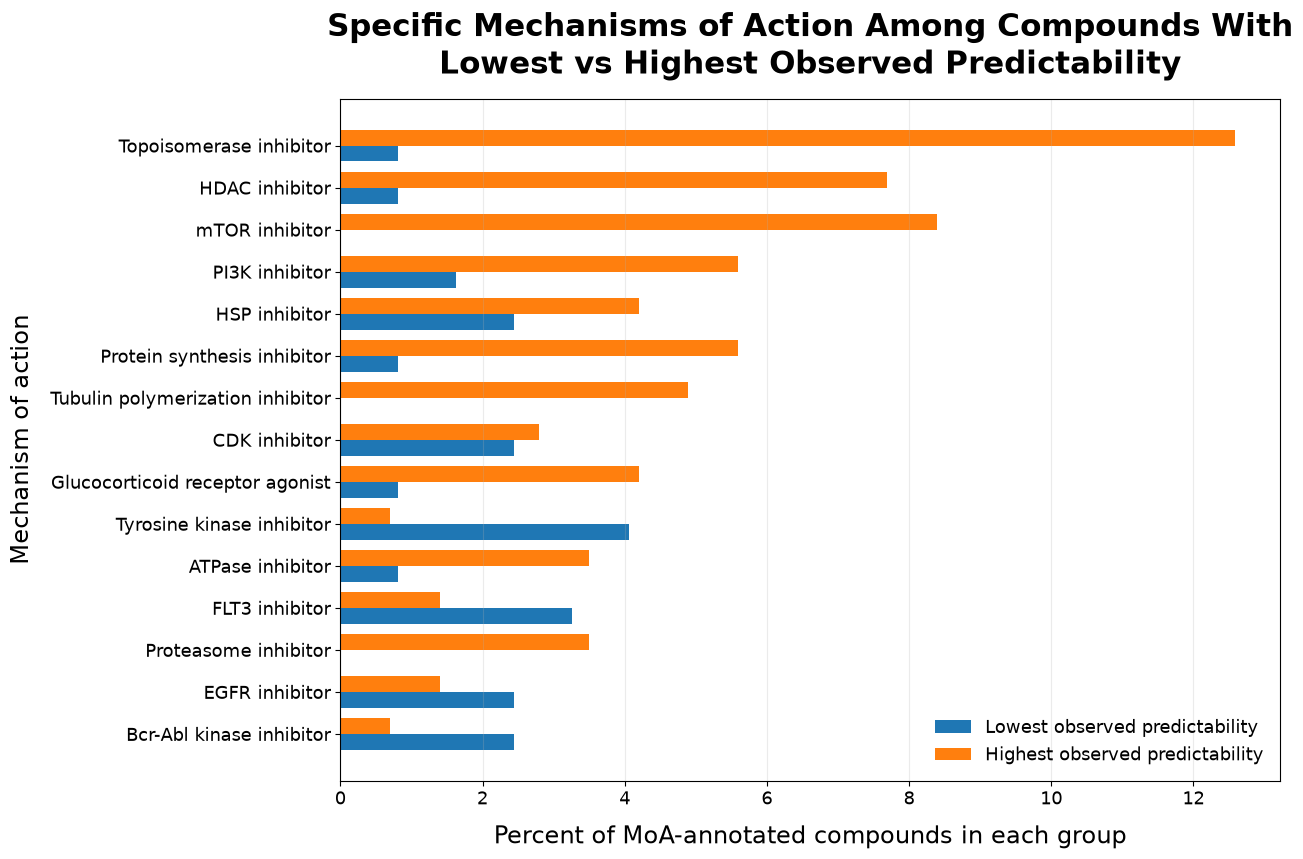


Specific Mechanisms of Action Among Compounds With Lowest vs Highest Observed Predictability
Lowest observed predictability: 123 MoA-annotated compounds
Highest observed predictability: 143 MoA-annotated compounds
MoAs formally tested: 14
FDR-significant MoAs: 3


,moa,low_count,high_count,log2_odds_ratio,p_value,adjusted_p_value,direction
0,Topoisomerase inhibitor,1,18,3.589585,0.000148,0.002067,More common in Highest observed predictability
1,mTOR inhibitor,0,12,4.553304,0.000537,0.003759,More common in Highest observed predictability
2,HDAC inhibitor,1,11,2.825389,0.006834,0.031893,More common in Highest observed predictability
3,Tubulin polymerization inhibitor,0,7,3.762501,0.016219,0.056768,More common in Highest observed predictability
4,Protein synthesis inhibitor,1,8,2.356989,0.040612,0.113715,More common in Highest observed predictability
5,Proteasome inhibitor,0,5,3.294057,0.063671,0.148566,More common in Highest observed predictability
6,Tyrosine kinase inhibitor,5,1,-2.140544,0.098587,0.197175,More common in Lowest observed predictability
7,PI3K inhibitor,2,8,1.608198,0.112715,0.197250,More common in Highest observed predictability
8,Glucocorticoid receptor agonist,1,6,1.948827,0.127495,0.198325,More common in Highest observed predictability
9,ATPase inhibitor,1,5,1.697365,0.221448,0.310028,More common in Highest observed predictability


In [25]:
# Recalculate MoA counts, enrichment, and figures using the fully cleaned annotations 

import matplotlib.pyplot as plt

from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests


def run_clean_moa_analysis(
    moa_long,
    group_column,
    low_group,
    high_group,
    low_display_label,
    high_display_label,
    title,
    output_prefix,
    minimum_total_count=5,
    number_to_plot=15,
):
    """
    Compare MoAs, run Fisher, make a bar graph, and save.
    """


    # Keep only the two extreme groups


    extreme_long = (
        moa_long[
            moa_long[group_column].isin(
                [
                    low_group,
                    high_group,
                ]
            )
        ]
        .copy()
        .reset_index(drop=True)
    )

    extreme_long[group_column] = (
        extreme_long[group_column]
        .astype(str)
    )



    # Count MoA-annotated compounds in each group


    group_sizes = (
        extreme_long
        .groupby(group_column)[
            "compound_embedding_row_index"
        ]
        .nunique()
        .reindex(
            [
                low_group,
                high_group,
            ]
        )
    )

    n_low = int(
        group_sizes.loc[low_group]
    )

    n_high = int(
        group_sizes.loc[high_group]
    )

    assert n_low > 0
    assert n_high > 0



    # Count compounds carrying each MoA


    counts = pd.crosstab(
        index=(
            extreme_long["moa_annotation"]
            .to_numpy()
        ),
        columns=(
            extreme_long[group_column]
            .to_numpy()
        ),
    )

    counts.index.name = "moa_annotation"

    counts = counts.reindex(
        columns=[
            low_group,
            high_group,
        ],
        fill_value=0,
    )

    comparison = counts.copy()

    comparison.columns = [
        "low_count",
        "high_count",
    ]

    comparison["low_percent"] = (
        100
        * comparison["low_count"]
        / n_low
    )

    comparison["high_percent"] = (
        100
        * comparison["high_count"]
        / n_high
    )

    comparison["total_extreme_count"] = (
        comparison["low_count"]
        + comparison["high_count"]
    )

    comparison = (
        comparison
        .sort_values(
            "total_extreme_count",
            ascending=False,
        )
        .reset_index()
    )



    # Fisher enrichment analysis


    enrichment_rows = []

    for _, row in comparison.iterrows():

        low_count = int(
            row["low_count"]
        )

        high_count = int(
            row["high_count"]
        )

        total_count = (
            low_count
            + high_count
        )

        if total_count < minimum_total_count:
            continue

        contingency_table = [
            [
                high_count,
                n_high - high_count,
            ],
            [
                low_count,
                n_low - low_count,
            ],
        ]

        fisher_odds_ratio, p_value = (
            fisher_exact(
                contingency_table,
                alternative="two-sided",
            )
        )

        corrected_odds_ratio = (
            (high_count + 0.5)
            * (n_low - low_count + 0.5)
            / (
                (n_high - high_count + 0.5)
                * (low_count + 0.5)
            )
        )

        log2_odds_ratio = np.log2(
            corrected_odds_ratio
        )

        if log2_odds_ratio > 0:
            direction = (
                f"More common in {high_display_label}"
            )

        elif log2_odds_ratio < 0:
            direction = (
                f"More common in {low_display_label}"
            )

        else:
            direction = "No difference"

        enrichment_rows.append({
            "moa": row["moa_annotation"],
            "low_count": low_count,
            "low_total": n_low,
            "high_count": high_count,
            "high_total": n_high,
            "total_extreme_count": total_count,
            "fisher_odds_ratio":
                fisher_odds_ratio,
            "corrected_odds_ratio":
                corrected_odds_ratio,
            "log2_odds_ratio":
                log2_odds_ratio,
            "p_value": p_value,
            "direction": direction,
        })

    enrichment = pd.DataFrame(
        enrichment_rows
    )

    if len(enrichment) > 0:

        enrichment["adjusted_p_value"] = (
            multipletests(
                enrichment["p_value"],
                method="fdr_bh",
            )[1]
        )

        enrichment[
            "significant_fdr_0_05"
        ] = (
            enrichment["adjusted_p_value"]
            < 0.05
        )

        enrichment = (
            enrichment
            .sort_values(
                [
                    "adjusted_p_value",
                    "p_value",
                ]
            )
            .reset_index(drop=True)
        )



    # Make cleaned bar graph


    plot_table = (
        comparison
        .head(number_to_plot)
        .sort_values(
            "total_extreme_count",
            ascending=True,
        )
        .copy()
    )

    figure_height = max(
        8,
        0.58 * len(plot_table),
    )

    fig, ax = plt.subplots(
        figsize=(13, figure_height)
    )

    positions = np.arange(
        len(plot_table)
    )

    bar_height = 0.38

    ax.barh(
        positions - bar_height / 2,
        plot_table["low_percent"],
        height=bar_height,
        label=low_display_label,
    )

    ax.barh(
        positions + bar_height / 2,
        plot_table["high_percent"],
        height=bar_height,
        label=high_display_label,
    )

    ax.set_yticks(
        positions
    )

    ax.set_yticklabels(
        plot_table["moa_annotation"],
        fontsize=13,
    )

    ax.set_xlabel(
        "Percent of MoA-annotated compounds in each group",
        fontsize=17,
        labelpad=12,
    )

    ax.set_ylabel(
        "Mechanism of action",
        fontsize=17,
        labelpad=12,
    )

    ax.set_title(
        title,
        fontsize=22,
        fontweight="bold",
        pad=18,
    )

    ax.tick_params(
        axis="x",
        labelsize=13,
    )

    ax.grid(
        axis="x",
        alpha=0.25,
    )

    ax.legend(
        fontsize=13,
        frameon=False,
    )

    fig.tight_layout()



    # Save outputs


    comparison_path = (
        OUTPUT_DIR
        / f"{output_prefix}_moa_comparison.csv"
    )

    enrichment_path = (
        OUTPUT_DIR
        / f"{output_prefix}_moa_enrichment.csv"
    )

    long_path = (
        OUTPUT_DIR
        / f"{output_prefix}_moa_long.csv"
    )

    figure_path = (
        FIG_DIR
        / f"{output_prefix}_moa_comparison.png"
    )

    figure_pdf_path = (
        FIG_DIR
        / f"{output_prefix}_moa_comparison.pdf"
    )

    comparison.to_csv(
        comparison_path,
        index=False,
    )

    enrichment.to_csv(
        enrichment_path,
        index=False,
    )

    extreme_long.to_csv(
        long_path,
        index=False,
    )

    fig.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
    )

    fig.savefig(
        figure_pdf_path,
        bbox_inches="tight",
    )

    plt.show()



    # Display summary


    print("\n" + "=" * 65)
    print(title.replace("\n", " "))
    print("=" * 65)

    print(
        f"{low_display_label}: "
        f"{n_low} MoA-annotated compounds"
    )

    print(
        f"{high_display_label}: "
        f"{n_high} MoA-annotated compounds"
    )

    print(
        "MoAs formally tested:",
        len(enrichment),
    )

    print(
        "FDR-significant MoAs:",
        int(
            enrichment[
                "significant_fdr_0_05"
            ].sum()
        ),
    )

    display(
        enrichment[
            [
                "moa",
                "low_count",
                "high_count",
                "log2_odds_ratio",
                "p_value",
                "adjusted_p_value",
                "direction",
            ]
        ]
    )

    return {
        "comparison": comparison,
        "enrichment": enrichment,
        "long": extreme_long,
        "group_sizes": group_sizes,
        "figure_path": figure_path,
    }



# Analysis A: groups created by the regression model


predicted_clean_analysis = run_clean_moa_analysis(
    moa_long=all_moa_long,
    group_column="model_prediction_group",
    low_group="Least predictable",
    high_group="Most predictable",
    low_display_label=(
        "Model-ranked least predictable"
    ),
    high_display_label=(
        "Model-ranked most predictable"
    ),
    title=(
        "Specific Mechanisms of Action Among Compounds the Model Ranked as\n"
        "Least vs Most Predictable"
    ),
    output_prefix=(
        "step4_n20_clean_predicted"
    ),
)



# Analysis B: groups created using actual observed scores


observed_clean_analysis = run_clean_moa_analysis(
    moa_long=all_moa_long,
    group_column="observed_predictability_group",
    low_group=(
        "Lowest observed predictability"
    ),
    high_group=(
        "Highest observed predictability"
    ),
    low_display_label=(
        "Lowest observed predictability"
    ),
    high_display_label=(
        "Highest observed predictability"
    ),
    title=(
        "Specific Mechanisms of Action Among Compounds With\n"
        "Lowest vs Highest Observed Predictability"
    ),
    output_prefix=(
        "step4_n20_clean_observed"
    ),
)

In [26]:
# Compare the fully cleaned predicted and observed MoA results

predicted_enrichment_clean = (
    predicted_clean_analysis[
        "enrichment"
    ]
    .copy()
)

observed_enrichment_clean = (
    observed_clean_analysis[
        "enrichment"
    ]
    .copy()
)


predicted_for_merge = (
    predicted_enrichment_clean[
        [
            "moa",
            "low_count",
            "high_count",
            "log2_odds_ratio",
            "adjusted_p_value",
            "significant_fdr_0_05",
            "direction",
        ]
    ]
    .rename(
        columns={
            "low_count":
                "predicted_low_count",

            "high_count":
                "predicted_high_count",

            "log2_odds_ratio":
                "predicted_log2_odds_ratio",

            "adjusted_p_value":
                "predicted_adjusted_p_value",

            "significant_fdr_0_05":
                "significant_in_predicted_analysis",

            "direction":
                "predicted_direction",
        }
    )
)


observed_for_merge = (
    observed_enrichment_clean[
        [
            "moa",
            "low_count",
            "high_count",
            "log2_odds_ratio",
            "adjusted_p_value",
            "significant_fdr_0_05",
            "direction",
        ]
    ]
    .rename(
        columns={
            "low_count":
                "observed_low_count",

            "high_count":
                "observed_high_count",

            "log2_odds_ratio":
                "observed_log2_odds_ratio",

            "adjusted_p_value":
                "observed_adjusted_p_value",

            "significant_fdr_0_05":
                "significant_in_observed_analysis",

            "direction":
                "observed_direction",
        }
    )
)


clean_model_observed_comparison = (
    predicted_for_merge
    .merge(
        observed_for_merge,
        on="moa",
        how="outer",
    )
)


# Mark whether each MoA was actually tested

clean_model_observed_comparison[
    "tested_in_predicted_analysis"
] = (
    clean_model_observed_comparison[
        "predicted_adjusted_p_value"
    ]
    .notna()
)

clean_model_observed_comparison[
    "tested_in_observed_analysis"
] = (
    clean_model_observed_comparison[
        "observed_adjusted_p_value"
    ]
    .notna()
)


clean_model_observed_comparison[
    "significant_in_predicted_analysis"
] = (
    clean_model_observed_comparison[
        "significant_in_predicted_analysis"
    ]
    .fillna(False)
    .astype(bool)
)

clean_model_observed_comparison[
    "significant_in_observed_analysis"
] = (
    clean_model_observed_comparison[
        "significant_in_observed_analysis"
    ]
    .fillna(False)
    .astype(bool)
)


# Compare effect 

tested_in_both = (
    clean_model_observed_comparison[
        "tested_in_predicted_analysis"
    ]
    &
    clean_model_observed_comparison[
        "tested_in_observed_analysis"
    ]
)

clean_model_observed_comparison[
    "same_effect_direction"
] = pd.Series(
    pd.NA,
    index=clean_model_observed_comparison.index,
    dtype="boolean",
)

clean_model_observed_comparison.loc[
    tested_in_both,
    "same_effect_direction",
] = (
    np.sign(
        clean_model_observed_comparison.loc[
            tested_in_both,
            "predicted_log2_odds_ratio",
        ]
    )
    ==
    np.sign(
        clean_model_observed_comparison.loc[
            tested_in_both,
            "observed_log2_odds_ratio",
        ]
    )
)



clean_model_observed_comparison[
    "model_recovered_observed_moa_pattern"
] = (
    clean_model_observed_comparison[
        "significant_in_predicted_analysis"
    ]
    &
    clean_model_observed_comparison[
        "significant_in_observed_analysis"
    ]
    &
    clean_model_observed_comparison[
        "same_effect_direction"
    ].fillna(False)
)


clean_model_observed_comparison = (
    clean_model_observed_comparison
    .sort_values(
        [
            "model_recovered_observed_moa_pattern",
            "significant_in_observed_analysis",
            "observed_adjusted_p_value",
        ],
        ascending=[
            False,
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)


CLEAN_MODEL_OBSERVED_PATH = (
    OUTPUT_DIR
    / "step4_n20_clean_predicted_vs_observed_moa.csv"
)

clean_model_observed_comparison.to_csv(
    CLEAN_MODEL_OBSERVED_PATH,
    index=False,
)


display(
    clean_model_observed_comparison
)

print("\nMoA patterns recovered by the model:")

display(
    clean_model_observed_comparison[
        clean_model_observed_comparison[
            "model_recovered_observed_moa_pattern"
        ]
    ]
)

print("\nSaved corrected comparison:")
print(CLEAN_MODEL_OBSERVED_PATH)

,moa,predicted_low_count,predicted_high_count,predicted_log2_odds_ratio,predicted_adjusted_p_value,significant_in_predicted_analysis,predicted_direction,observed_low_count,observed_high_count,observed_log2_odds_ratio,observed_adjusted_p_value,significant_in_observed_analysis,observed_direction,tested_in_predicted_analysis,tested_in_observed_analysis,same_effect_direction,model_recovered_observed_moa_pattern
0,Topoisomerase inhibitor,1.0,17.0,3.601578,0.001997,True,More common in Model-ranked most predictable,1.0,18.0,3.589585,0.002067,True,More common in Highest observed predictability,True,True,True,True
1,mTOR inhibitor,0.0,8.0,4.054423,0.026522,True,More common in Model-ranked most predictable,0.0,12.0,4.553304,0.003759,True,More common in Highest observed predictability,True,True,True,True
2,HDAC inhibitor,4.0,1.0,-1.737540,0.273510,False,More common in Model-ranked least predictable,1.0,11.0,2.825389,0.031893,True,More common in Highest observed predictability,True,True,False,False
3,Tubulin polymerization inhibitor,1.0,6.0,2.049639,0.200136,False,More common in Model-ranked most predictable,0.0,7.0,3.762501,0.056768,False,More common in Highest observed predictability,True,True,True,False
4,Protein synthesis inhibitor,1.0,5.0,1.797945,0.277534,False,More common in Model-ranked most predictable,1.0,8.0,2.356989,0.113715,False,More common in Highest observed predictability,True,True,True,False
5,Proteasome inhibitor,NaN,NaN,NaN,NaN,False,NaN,0.0,5.0,3.294057,0.148566,False,More common in Highest observed predictability,False,True,<NA>,False
6,Tyrosine kinase inhibitor,4.0,1.0,-1.737540,0.273510,False,More common in Model-ranked least predictable,5.0,1.0,-2.140544,0.197175,False,More common in Lowest observed predictability,True,True,True,False
7,PI3K inhibitor,0.0,5.0,3.394091,0.110194,False,More common in Model-ranked most predictable,2.0,8.0,1.608198,0.197250,False,More common in Highest observed predictability,True,True,True,False
8,Glucocorticoid receptor agonist,0.0,12.0,4.655040,0.003815,True,More common in Model-ranked most predictable,1.0,6.0,1.948827,0.198325,False,More common in Highest observed predictability,True,True,True,False
9,ATPase inhibitor,0.0,8.0,4.054423,0.026522,True,More common in Model-ranked most predictable,1.0,5.0,1.697365,0.310028,False,More common in Highest observed predictability,True,True,True,False



MoA patterns recovered by the model:


,moa,predicted_low_count,predicted_high_count,predicted_log2_odds_ratio,predicted_adjusted_p_value,significant_in_predicted_analysis,predicted_direction,observed_low_count,observed_high_count,observed_log2_odds_ratio,observed_adjusted_p_value,significant_in_observed_analysis,observed_direction,tested_in_predicted_analysis,tested_in_observed_analysis,same_effect_direction,model_recovered_observed_moa_pattern
0,Topoisomerase inhibitor,1.0,17.0,3.601578,0.001997,True,More common in Model-ranked most predictable,1.0,18.0,3.589585,0.002067,True,More common in Highest observed predictability,True,True,True,True
1,mTOR inhibitor,0.0,8.0,4.054423,0.026522,True,More common in Model-ranked most predictable,0.0,12.0,4.553304,0.003759,True,More common in Highest observed predictability,True,True,True,True



Saved corrected comparison:
/Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/step4_n20_clean_predicted_vs_observed_moa.csv


In [27]:
# Verify 

from pathlib import Path


# Find the notebook

notebook_matches = list(
    PROJECT_ROOT.rglob(
        "step4_expanded_regression_moa.ipynb"
    )
)

print("Notebook matches:")
for path in notebook_matches:
    print(" ", path)


# Final figures that should exist

expected_figures = [
    FIG_DIR
    / "step4_n20_observed_by_predicted_quintile.png",

    FIG_DIR
    / "step4_n20_observed_by_predicted_quintile.pdf",

    FIG_DIR
    / "step4_n20_clean_predicted_moa_comparison.png",

    FIG_DIR
    / "step4_n20_clean_predicted_moa_comparison.pdf",

    FIG_DIR
    / "step4_n20_clean_observed_moa_comparison.png",

    FIG_DIR
    / "step4_n20_clean_observed_moa_comparison.pdf",
]


# Final result tables that should exist

expected_tables = [
    OUTPUT_DIR
    / "step4_extra_trees_n20_oof_predictions.csv",

    OUTPUT_DIR
    / "step4_extra_trees_n20_oof_predictions_with_groups.csv",

    OUTPUT_DIR
    / "step4_extra_trees_n20_oof_summary_metrics.csv",

    OUTPUT_DIR
    / "step4_n20_predicted_quintile_summary.csv",

    OUTPUT_DIR
    / "step4_n20_clean_predicted_moa_comparison.csv",

    OUTPUT_DIR
    / "step4_n20_clean_predicted_moa_enrichment.csv",

    OUTPUT_DIR
    / "step4_n20_clean_observed_moa_comparison.csv",

    OUTPUT_DIR
    / "step4_n20_clean_observed_moa_enrichment.csv",

    OUTPUT_DIR
    / "step4_n20_clean_predicted_vs_observed_moa.csv",
]


# Check every expected file

all_expected_files = (
    expected_figures
    + expected_tables
)

missing_files = []
empty_files = []

for path in all_expected_files:

    if not path.exists():
        status = "MISSING"
        missing_files.append(path)

    elif path.stat().st_size == 0:
        status = "EMPTY"
        empty_files.append(path)

    else:
        size_mb = path.stat().st_size / 1e6
        status = f"OK — {size_mb:.3f} MB"

    print(f"{status:20} {path}")


print("\n" + "=" * 70)

if not notebook_matches:
    print("WARNING: Final notebook was not found.")

if missing_files:
    print(
        f"WARNING: {len(missing_files)} expected files are missing."
    )

if empty_files:
    print(
        f"WARNING: {len(empty_files)} files are empty."
    )

if (
    notebook_matches
    and not missing_files
    and not empty_files
):
    print(
        "Everything is saved and ready for GitHub."
    )

Notebook matches:
  /Users/mell/predicting-predictability/data/step4_expanded_regression_moa.ipynb
OK — 0.499 MB        /Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_observed_by_predicted_quintile.png
OK — 0.048 MB        /Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_observed_by_predicted_quintile.pdf
OK — 0.317 MB        /Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_clean_predicted_moa_comparison.png
OK — 0.029 MB        /Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_clean_predicted_moa_comparison.pdf
OK — 0.285 MB        /Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_clean_observed_moa_comparison.png
OK — 0.032 MB        /Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_clean_observed_moa_comparison.pdf
OK — 0.116 MB        /Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/step4_extra_trees

,predicted_quintile,n_compounds,mean_actual_predictability,median_actual_predictability,std_actual_predictability,mean_predicted_predictability
0,Least\npredictable,161,0.781380,0.801439,0.088549,0.788726
1,Lower,160,0.808978,0.817731,0.085348,0.812418
2,Middle,160,0.826404,0.839005,0.083528,0.824415
3,Higher,160,0.844032,0.861938,0.079800,0.837979
4,Most\npredictable,160,0.873311,0.882363,0.081221,0.871648


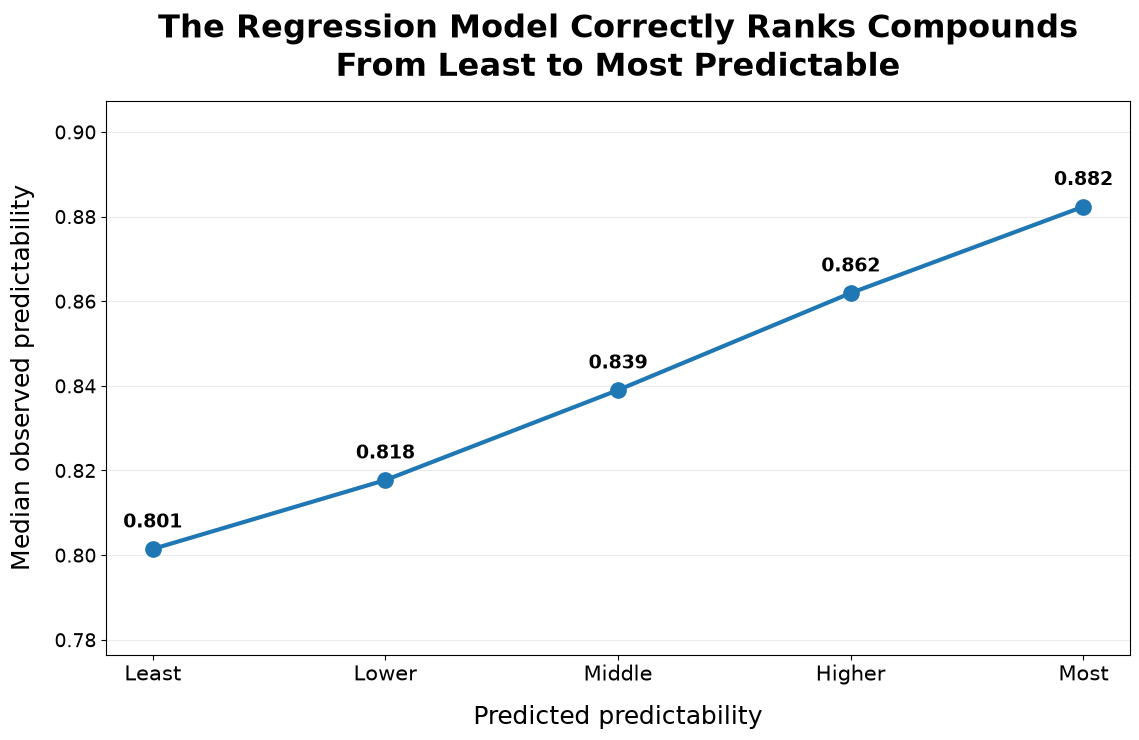


Saved trend figure:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_predicted_vs_observed_median_trend.png

Saved PDF:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_predicted_vs_observed_median_trend.pdf


In [2]:
# Create a simpler trend plot

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



# Locate project directories


cwd = Path.cwd()

if (cwd / "data" / "step3_multimodal").exists():
    PROJECT_ROOT = cwd
    DATA_DIR = cwd / "data"

elif (cwd / "step3_multimodal").exists():
    DATA_DIR = cwd
    PROJECT_ROOT = cwd.parent

else:
    raise FileNotFoundError(
        "Could not locate the project folders.\n"
        f"Current folder: {cwd}"
    )


OUTPUT_DIR = (
    DATA_DIR
    / "step3_multimodal"
    / "step4_expanded_n20"
)

FIG_DIR = (
    PROJECT_ROOT
    / "figures"
    / "step4_expanded_n20"
)

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)



# Load the previously saved quintile summary


SUMMARY_PATH = (
    OUTPUT_DIR
    / "step4_n20_predicted_quintile_summary.csv"
)

assert SUMMARY_PATH.exists(), (
    f"Missing summary file: {SUMMARY_PATH}"
)

quintile_summary = pd.read_csv(
    SUMMARY_PATH
)

display(quintile_summary)



# Check required columns


required_columns = [
    "median_actual_predictability",
]

missing_columns = [
    column
    for column in required_columns
    if column not in quintile_summary.columns
]

if missing_columns:
    raise KeyError(
        "The summary file is missing: "
        f"{missing_columns}"
    )



# Prepare plotting values


group_labels = [
    "Least",
    "Lower",
    "Middle",
    "Higher",
    "Most",
]

median_observed = (
    quintile_summary[
        "median_actual_predictability"
    ]
    .to_numpy(dtype=float)
)

positions = np.arange(
    1,
    len(group_labels) + 1,
)



# Create the simplified trend plot


fig, ax = plt.subplots(
    figsize=(11.5, 7.5)
)

ax.plot(
    positions,
    median_observed,
    marker="o",
    markersize=11,
    linewidth=3,
)

# Add the median value above each point
for x_position, median_value in zip(
    positions,
    median_observed,
):
    ax.text(
        x_position,
        median_value + 0.004,
        f"{median_value:.3f}",
        ha="center",
        va="bottom",
        fontsize=14,
        fontweight="bold",
    )



# Titles and labels


ax.set_title(
    "The Regression Model Correctly Ranks Compounds\n"
    "From Least to Most Predictable",
    fontsize=23,
    fontweight="bold",
    pad=18,
)

ax.set_xlabel(
    "Predicted predictability",
    fontsize=18,
    labelpad=14,
)

ax.set_ylabel(
    "Median observed predictability",
    fontsize=18,
    labelpad=14,
)

ax.set_xticks(
    positions
)

ax.set_xticklabels(
    group_labels,
    fontsize=15,
)

ax.tick_params(
    axis="y",
    labelsize=14,
)

ax.grid(
    axis="y",
    alpha=0.25,
)


# Trend
y_min = median_observed.min() - 0.025
y_max = median_observed.max() + 0.025

ax.set_ylim(
    y_min,
    y_max,
)

fig.tight_layout()


# Save the new figure


TREND_FIGURE_PATH = (
    FIG_DIR
    / "step4_n20_predicted_vs_observed_median_trend.png"
)

TREND_FIGURE_PDF_PATH = (
    FIG_DIR
    / "step4_n20_predicted_vs_observed_median_trend.pdf"
)

fig.savefig(
    TREND_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    TREND_FIGURE_PDF_PATH,
    bbox_inches="tight",
)

plt.show()


print("\nSaved trend figure:")
print(TREND_FIGURE_PATH)

print("\nSaved PDF:")
print(TREND_FIGURE_PDF_PATH)

Predicted table columns:
['moa_annotation', 'low_count', 'high_count', 'low_percent', 'high_percent', 'total_extreme_count']

Observed table columns:
['moa_annotation', 'low_count', 'high_count', 'low_percent', 'high_percent', 'total_extreme_count']


,moa_annotation,low_count,high_count,low_percent,high_percent,total_extreme_count
0,Topoisomerase inhibitor,1,17,0.775194,12.142857,18
1,Glucocorticoid receptor agonist,0,12,0.000000,8.571429,12
2,ATPase inhibitor,0,8,0.000000,5.714286,8
3,mTOR inhibitor,0,8,0.000000,5.714286,8
4,Tubulin polymerization inhibitor,1,6,0.775194,4.285714,7


,moa_annotation,low_count,high_count,low_percent,high_percent,total_extreme_count
0,Topoisomerase inhibitor,1,18,0.813008,12.587413,19
1,mTOR inhibitor,0,12,0.000000,8.391608,12
2,HDAC inhibitor,1,11,0.813008,7.692308,12
3,PI3K inhibitor,2,8,1.626016,5.594406,10
4,Protein synthesis inhibitor,1,8,0.813008,5.594406,9


,moa,observed_difference,predicted_difference,observed_adjusted_p,predicted_adjusted_p
0,Retinoid receptor agonist,-2.439024,-5.426357,NaN,NaN
1,ATPase inhibitor,2.683495,5.714286,NaN,NaN
2,Glucocorticoid receptor agonist,3.382796,8.571429,NaN,NaN
3,Protein synthesis inhibitor,4.781397,2.796235,NaN,NaN
4,Tubulin polymerization inhibitor,4.895105,3.510520,NaN,NaN
5,HDAC inhibitor,6.879300,-2.386489,NaN,NaN
6,mTOR inhibitor,8.391608,5.714286,NaN,NaN
7,Topoisomerase inhibitor,11.774404,11.367663,NaN,NaN


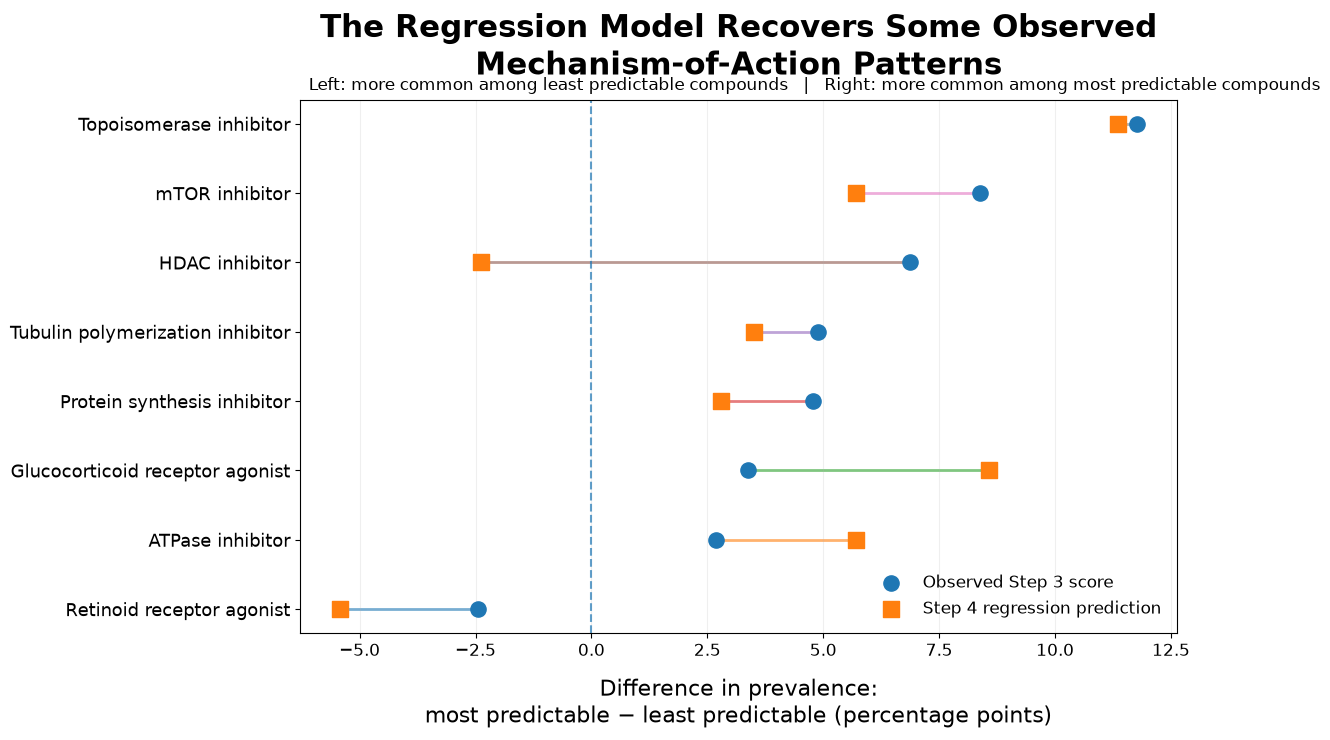


Saved figure:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_observed_vs_predicted_moa_paired_dot.png

Saved PDF:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_observed_vs_predicted_moa_paired_dot.pdf

Saved plotted data:
/Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/step4_n20_observed_vs_predicted_moa_paired_dot_data.csv


In [3]:
# Compare observed versus regression-predicted MoA patterns

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Locate 

cwd = Path.cwd()

if (cwd / "data" / "step3_multimodal").exists():
    PROJECT_ROOT = cwd
    DATA_DIR = cwd / "data"

elif (cwd / "step3_multimodal").exists():
    DATA_DIR = cwd
    PROJECT_ROOT = cwd.parent

else:
    raise FileNotFoundError(
        "Could not locate the project folders.\n"
        f"Current folder: {cwd}"
    )


OUTPUT_DIR = (
    DATA_DIR
    / "step3_multimodal"
    / "step4_expanded_n20"
)

FIG_DIR = (
    PROJECT_ROOT
    / "figures"
    / "step4_expanded_n20"
)

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# Load final cleaned MoA comparison tables


PREDICTED_PATH = (
    OUTPUT_DIR
    / "step4_n20_clean_predicted_moa_comparison.csv"
)

OBSERVED_PATH = (
    OUTPUT_DIR
    / "step4_n20_clean_observed_moa_comparison.csv"
)

assert PREDICTED_PATH.exists(), (
    f"Missing predicted MoA file:\n{PREDICTED_PATH}"
)

assert OBSERVED_PATH.exists(), (
    f"Missing observed MoA file:\n{OBSERVED_PATH}"
)


predicted_raw = pd.read_csv(PREDICTED_PATH)
observed_raw = pd.read_csv(OBSERVED_PATH)

print("Predicted table columns:")
print(predicted_raw.columns.tolist())

print("\nObserved table columns:")
print(observed_raw.columns.tolist())

display(predicted_raw.head())
display(observed_raw.head())


# Helper: identify columns even if names differ slightly

def find_column(
    df,
    candidates,
    required=True,
):
    """
    Return the first matching column.
    """

    lower_map = {
        column.lower(): column
        for column in df.columns
    }

    # Exact case-insensitive match
    for candidate in candidates:
        if candidate.lower() in lower_map:
            return lower_map[candidate.lower()]

    # Partial match
    for candidate in candidates:
        candidate_lower = candidate.lower()

        for column in df.columns:
            if candidate_lower in column.lower():
                return column

    if required:
        raise KeyError(
            "Could not find a matching column.\n"
            f"Candidates: {candidates}\n"
            f"Available columns: {df.columns.tolist()}"
        )

    return None


def standardize_moa_table(
    df,
    analysis_name,
):
    """
    Convert one MoA comparison table into:

    moa
    least_percent
    most_percent
    prevalence_difference
    adjusted_p_value
    """

    moa_col = find_column(
        df,
        [
            "moa",
            "mechanism_of_action",
            "mechanism of action",
        ],
    )

    least_percent_col = find_column(
        df,
        [
            "least_percent",
            "least_pct",
            "percent_least",
            "lowest_percent",
            "lowest_pct",
            "percent_lowest",
            "low_percent",
        ],
        required=False,
    )

    most_percent_col = find_column(
        df,
        [
            "most_percent",
            "most_pct",
            "percent_most",
            "highest_percent",
            "highest_pct",
            "percent_highest",
            "high_percent",
        ],
        required=False,
    )

    least_count_col = find_column(
        df,
        [
            "least_count",
            "lowest_count",
            "low_count",
            "n_least",
            "n_lowest",
        ],
        required=False,
    )

    most_count_col = find_column(
        df,
        [
            "most_count",
            "highest_count",
            "high_count",
            "n_most",
            "n_highest",
        ],
        required=False,
    )

    least_total_col = find_column(
        df,
        [
            "least_total",
            "lowest_total",
            "n_least_total",
            "n_lowest_total",
            "least_group_total",
            "lowest_group_total",
        ],
        required=False,
    )

    most_total_col = find_column(
        df,
        [
            "most_total",
            "highest_total",
            "n_most_total",
            "n_highest_total",
            "most_group_total",
            "highest_group_total",
        ],
        required=False,
    )

    adjusted_p_col = find_column(
        df,
        [
            "adjusted_p_value",
            "adj_p_value",
            "fdr",
            "fdr_p_value",
            "q_value",
            "padj",
        ],
        required=False,
    )

    result = pd.DataFrame(
        {
            "moa": (
                df[moa_col]
                .astype(str)
                .str.strip()
            )
        }
    )

    # Prefer percentages already stored in the table
    if (
        least_percent_col is not None
        and most_percent_col is not None
    ):
        result["least_percent"] = pd.to_numeric(
            df[least_percent_col],
            errors="coerce",
        )

        result["most_percent"] = pd.to_numeric(
            df[most_percent_col],
            errors="coerce",
        )

    # Otherwise calculate percentages from counts and totals
    elif all(
        column is not None
        for column in [
            least_count_col,
            most_count_col,
            least_total_col,
            most_total_col,
        ]
    ):
        result["least_percent"] = (
            pd.to_numeric(
                df[least_count_col],
                errors="coerce",
            )
            / pd.to_numeric(
                df[least_total_col],
                errors="coerce",
            )
            * 100
        )

        result["most_percent"] = (
            pd.to_numeric(
                df[most_count_col],
                errors="coerce",
            )
            / pd.to_numeric(
                df[most_total_col],
                errors="coerce",
            )
            * 100
        )

    else:
        raise KeyError(
            f"Could not identify percentage columns for "
            f"{analysis_name}.\n"
            f"Available columns: {df.columns.tolist()}"
        )

    # Convert proportions to percentages when needed
    for column in [
        "least_percent",
        "most_percent",
    ]:
        non_missing = result[column].dropna()

        if (
            len(non_missing) > 0
            and non_missing.max() <= 1
        ):
            result[column] = (
                result[column] * 100
            )

    result["prevalence_difference"] = (
        result["most_percent"]
        - result["least_percent"]
    )

    if adjusted_p_col is not None:
        result["adjusted_p_value"] = pd.to_numeric(
            df[adjusted_p_col],
            errors="coerce",
        )
    else:
        result["adjusted_p_value"] = np.nan

    result["analysis"] = analysis_name

    return result


predicted = standardize_moa_table(
    predicted_raw,
    analysis_name="Regression-predicted",
)

observed = standardize_moa_table(
    observed_raw,
    analysis_name="Observed Step 3",
)


# Merge observed and predicted results

comparison = observed[
    [
        "moa",
        "prevalence_difference",
        "adjusted_p_value",
    ]
].rename(
    columns={
        "prevalence_difference":
            "observed_difference",
        "adjusted_p_value":
            "observed_adjusted_p",
    }
).merge(
    predicted[
        [
            "moa",
            "prevalence_difference",
            "adjusted_p_value",
        ]
    ].rename(
        columns={
            "prevalence_difference":
                "predicted_difference",
            "adjusted_p_value":
                "predicted_adjusted_p",
        }
    ),
    on="moa",
    how="outer",
)

comparison[
    [
        "observed_difference",
        "predicted_difference",
    ]
] = comparison[
    [
        "observed_difference",
        "predicted_difference",
    ]
].fillna(0)


# Select the most informative MoAs

# Significant in either analysis
comparison["significant_in_either"] = (
    comparison["observed_adjusted_p"].lt(0.05)
    | comparison["predicted_adjusted_p"].lt(0.05)
)

# Rank MoAs by the largest effect seen in either analysis
comparison["largest_absolute_effect"] = comparison[
    [
        "observed_difference",
        "predicted_difference",
    ]
].abs().max(axis=1)


# First prioritize MoAs significant in either analysis
plot_data = (
    comparison[
        comparison["significant_in_either"]
    ]
    .sort_values(
        "largest_absolute_effect",
        ascending=False,
    )
    .head(8)
    .copy()
)

# Fallback in case fewer than 5 significant MoAs were found
if len(plot_data) < 5:
    plot_data = (
        comparison
        .sort_values(
            "largest_absolute_effect",
            ascending=False,
        )
        .head(8)
        .copy()
    )


# Sort vertically by observed effect
plot_data = (
    plot_data
    .sort_values(
        "observed_difference",
        ascending=True,
    )
    .reset_index(drop=True)
)

display(
    plot_data[
        [
            "moa",
            "observed_difference",
            "predicted_difference",
            "observed_adjusted_p",
            "predicted_adjusted_p",
        ]
    ]
)



# Create paired dot plot


fig, ax = plt.subplots(
    figsize=(12.5, 7.5)
)

y_positions = np.arange(
    len(plot_data)
)

observed_values = plot_data[
    "observed_difference"
].to_numpy()

predicted_values = plot_data[
    "predicted_difference"
].to_numpy()


# Connect observed and predicted values for each MoA
for y, observed_value, predicted_value in zip(
    y_positions,
    observed_values,
    predicted_values,
):
    ax.plot(
        [
            observed_value,
            predicted_value,
        ],
        [
            y,
            y,
        ],
        linewidth=2,
        alpha=0.6,
        zorder=1,
    )


# Plot the observed values
ax.scatter(
    observed_values,
    y_positions,
    s=120,
    label="Observed Step 3 score",
    zorder=3,
)

# Plot the regression-predicted values
ax.scatter(
    predicted_values,
    y_positions,
    s=120,
    marker="s",
    label="Step 4 regression prediction",
    zorder=3,
)


# Zero indicates no difference between extreme groups
ax.axvline(
    0,
    linewidth=1.5,
    linestyle="--",
    alpha=0.7,
)


# Labels and title

ax.set_yticks(
    y_positions
)

ax.set_yticklabels(
    plot_data["moa"],
    fontsize=13,
)

ax.set_xlabel(
    "Difference in prevalence:\n"
    "most predictable − least predictable "
    "(percentage points)",
    fontsize=16,
    labelpad=12,
)

ax.set_title(
    "The Regression Model Recovers Some Observed\n"
    "Mechanism-of-Action Patterns",
    fontsize=22,
    fontweight="bold",
    pad=18,
)

ax.text(
    0.01,
    1.01,
    "Left: more common among least predictable compounds   |   "
    "Right: more common among most predictable compounds",
    transform=ax.transAxes,
    fontsize=12.5,
    va="bottom",
)

ax.tick_params(
    axis="x",
    labelsize=12,
)

ax.grid(
    axis="x",
    alpha=0.2,
)

ax.legend(
    frameon=False,
    fontsize=12.5,
    loc="lower right",
)

fig.tight_layout()


# Save figure and comparison table


FIGURE_PATH = (
    FIG_DIR
    / "step4_n20_observed_vs_predicted_moa_paired_dot.png"
)

PDF_PATH = (
    FIG_DIR
    / "step4_n20_observed_vs_predicted_moa_paired_dot.pdf"
)

TABLE_PATH = (
    OUTPUT_DIR
    / "step4_n20_observed_vs_predicted_moa_paired_dot_data.csv"
)

fig.savefig(
    FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    PDF_PATH,
    bbox_inches="tight",
)

plot_data.to_csv(
    TABLE_PATH,
    index=False,
)

plt.show()


print("\nSaved figure:")
print(FIGURE_PATH)

print("\nSaved PDF:")
print(PDF_PATH)

print("\nSaved plotted data:")
print(TABLE_PATH)

Agreement MoAs:


,moa,observed_difference,predicted_difference,absolute_gap
0,Retinoid receptor agonist,-2.439024,-5.426357,2.987332
1,ATPase inhibitor,2.683495,5.714286,3.030790
2,Glucocorticoid receptor agonist,3.382796,8.571429,5.188633
3,Protein synthesis inhibitor,4.781397,2.796235,1.985163
4,Tubulin polymerization inhibitor,4.895105,3.510520,1.384584
5,mTOR inhibitor,8.391608,5.714286,2.677323
6,Topoisomerase inhibitor,11.774404,11.367663,0.406741



Disagreement or overestimation MoAs:


,moa,observed_difference,predicted_difference,absolute_gap
0,ATPase inhibitor,2.683495,5.714286,3.030790
1,Glucocorticoid receptor agonist,3.382796,8.571429,5.188633
2,HDAC inhibitor,6.879300,-2.386489,9.265789


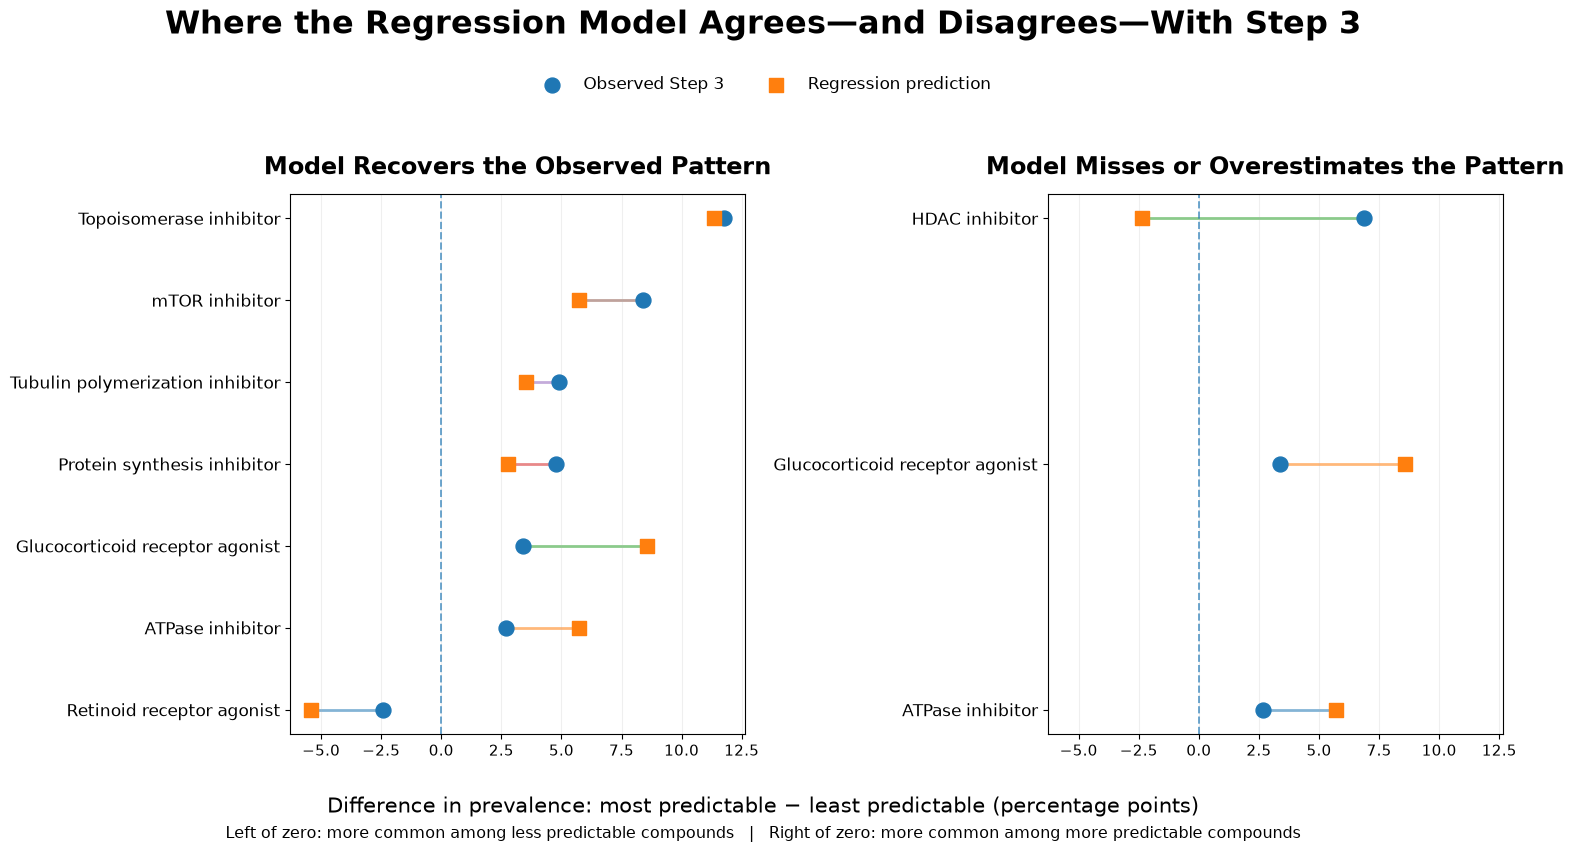


Saved figure:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_moa_agreement_vs_disagreement.png

Saved PDF:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_moa_agreement_vs_disagreement.pdf


In [4]:
# Split MoA results

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# Confirm data

required_columns = [
    "moa",
    "observed_difference",
    "predicted_difference",
]

missing_columns = [
    column
    for column in required_columns
    if column not in plot_data.columns
]

if missing_columns:
    raise KeyError(
        "plot_data is missing required columns: "
        f"{missing_columns}"
    )


# Classify agreement versus disagreement

split_data = plot_data.copy()

# Same direction means both values are positive
# or both values are negative
split_data["same_direction"] = (
    np.sign(split_data["observed_difference"])
    == np.sign(split_data["predicted_difference"])
)

# Difference in effect size 
split_data["model_gap"] = (
    split_data["predicted_difference"]
    - split_data["observed_difference"]
)

split_data["absolute_gap"] = (
    split_data["model_gap"].abs()
)


# Agreement 
agreement_data = (
    split_data[
        split_data["same_direction"]
    ]
    .sort_values(
        "observed_difference",
        ascending=True,
    )
    .reset_index(drop=True)
)


# Disagreement panel
disagreement_data = (
    split_data[
        (~split_data["same_direction"])
        | (split_data["absolute_gap"] >= 3.0)
    ]
    .sort_values(
        "absolute_gap",
        ascending=True,
    )
    .reset_index(drop=True)
)


print("Agreement MoAs:")
display(
    agreement_data[
        [
            "moa",
            "observed_difference",
            "predicted_difference",
            "absolute_gap",
        ]
    ]
)

print("\nDisagreement or overestimation MoAs:")
display(
    disagreement_data[
        [
            "moa",
            "observed_difference",
            "predicted_difference",
            "absolute_gap",
        ]
    ]
)


# Helper function for one panel


def draw_moa_panel(
    ax,
    data,
    panel_title,
):
    y_positions = np.arange(
        len(data)
    )

    observed_values = data[
        "observed_difference"
    ].to_numpy()

    predicted_values = data[
        "predicted_difference"
    ].to_numpy()

    # Connecting lines
    for y, observed_value, predicted_value in zip(
        y_positions,
        observed_values,
        predicted_values,
    ):
        ax.plot(
            [
                observed_value,
                predicted_value,
            ],
            [
                y,
                y,
            ],
            linewidth=2,
            alpha=0.55,
            zorder=1,
        )

    # Observed Step 3 values
    ax.scatter(
        observed_values,
        y_positions,
        s=115,
        label="Observed Step 3",
        zorder=3,
    )

    # Regression-predicted values
    ax.scatter(
        predicted_values,
        y_positions,
        s=115,
        marker="s",
        label="Regression prediction",
        zorder=3,
    )

    # Zero reference line
    ax.axvline(
        0,
        linestyle="--",
        linewidth=1.4,
        alpha=0.65,
    )

    ax.set_yticks(
        y_positions
    )

    ax.set_yticklabels(
        data["moa"],
        fontsize=12,
    )

    ax.set_title(
        panel_title,
        fontsize=17,
        fontweight="bold",
        pad=14,
    )

    ax.grid(
        axis="x",
        alpha=0.2,
    )

    ax.tick_params(
        axis="x",
        labelsize=11,
    )


# Create two-panel figure

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 8.5),
    sharex=True,
)

draw_moa_panel(
    axes[0],
    agreement_data,
    "Model Recovers the Observed Pattern",
)

draw_moa_panel(
    axes[1],
    disagreement_data,
    "Model Misses or Overestimates the Pattern",
)


# Shared labels and title

fig.suptitle(
    "Where the Regression Model Agrees—and Disagrees—With Step 3",
    fontsize=23,
    fontweight="bold",
    y=0.98,
)

fig.text(
    0.5,
    0.035,
    "Difference in prevalence: most predictable − least predictable "
    "(percentage points)",
    ha="center",
    fontsize=15,
)

fig.text(
    0.5,
    0.005,
    "Left of zero: more common among less predictable compounds   |   "
    "Right of zero: more common among more predictable compounds",
    ha="center",
    fontsize=11.5,
)

# One shared legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.92),
    ncol=2,
    frameon=False,
    fontsize=12.5,
)

fig.tight_layout(
    rect=[
        0.02,
        0.08,
        0.98,
        0.88,
    ]
)


# Save outputs

cwd = Path.cwd()

if (cwd / "figures").exists():
    PROJECT_ROOT = cwd

elif (cwd.parent / "figures").exists():
    PROJECT_ROOT = cwd.parent

else:
    PROJECT_ROOT = cwd.parent


FIG_DIR = (
    PROJECT_ROOT
    / "figures"
    / "step4_expanded_n20"
)

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


FIGURE_PATH = (
    FIG_DIR
    / "step4_n20_moa_agreement_vs_disagreement.png"
)

PDF_PATH = (
    FIG_DIR
    / "step4_n20_moa_agreement_vs_disagreement.pdf"
)

fig.savefig(
    FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    PDF_PATH,
    bbox_inches="tight",
)

plt.show()


print("\nSaved figure:")
print(FIGURE_PATH)

print("\nSaved PDF:")
print(PDF_PATH)

Loaded:
/Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/step4_n20_observed_vs_predicted_moa_paired_dot_data.csv

Columns:
['moa', 'observed_difference', 'observed_adjusted_p', 'predicted_difference', 'predicted_adjusted_p', 'significant_in_either', 'largest_absolute_effect']


,moa,observed_difference,predicted_difference
0,Topoisomerase inhibitor,11.774404,11.367663
1,mTOR inhibitor,8.391608,5.714286
2,HDAC inhibitor,6.879300,-2.386489
3,Tubulin polymerization inhibitor,4.895105,3.510520
4,Protein synthesis inhibitor,4.781397,2.796235
5,Glucocorticoid receptor agonist,3.382796,8.571429
6,ATPase inhibitor,2.683495,5.714286
7,Retinoid receptor agonist,-2.439024,-5.426357


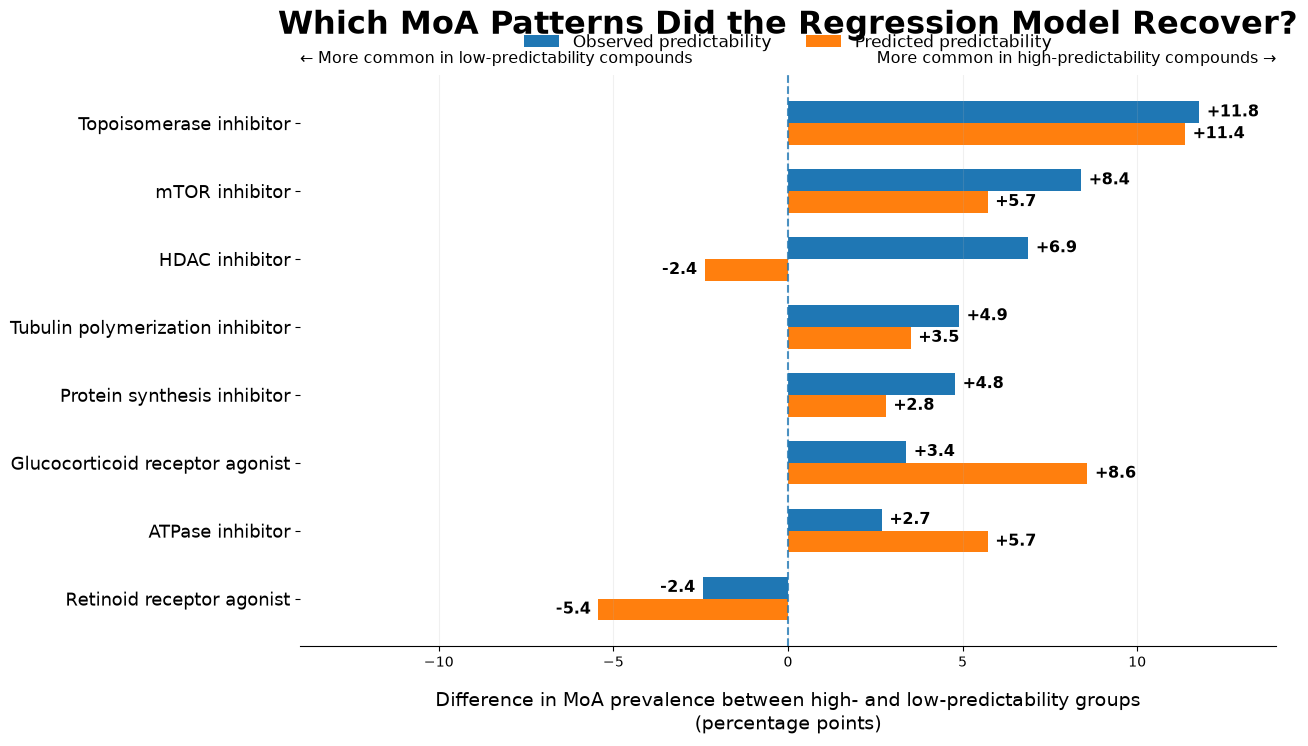


Saved figure:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_moa_observed_vs_predicted_grouped_bars_clean.png

Saved PDF:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_moa_observed_vs_predicted_grouped_bars_clean.pdf


In [11]:
# Clean grouped bar chart

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Locate

cwd = Path.cwd()

if (cwd / "data" / "step3_multimodal").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data" / "step3_multimodal").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        f"Could not locate project root from: {cwd}"
    )

OUTPUT_DIR = (
    PROJECT_ROOT
    / "data"
    / "step3_multimodal"
    / "step4_expanded_n20"
)

FIG_DIR = (
    PROJECT_ROOT
    / "figures"
    / "step4_expanded_n20"
)

FIG_DIR.mkdir(parents=True, exist_ok=True)


# Load saved comparison data

candidate_paths = [
    OUTPUT_DIR / "step4_n20_observed_vs_predicted_moa_paired_dot_data.csv",
    OUTPUT_DIR / "step4_n20_moa_observed_vs_predicted_grouped_bars.csv",
]

DATA_PATH = next(
    (path for path in candidate_paths if path.exists()),
    None,
)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find the saved MoA comparison table.\n"
        + "\n".join(str(path) for path in candidate_paths)
    )

comparison_data = pd.read_csv(DATA_PATH)

print("Loaded:")
print(DATA_PATH)
print("\nColumns:")
print(comparison_data.columns.tolist())


# Check required columns

required_columns = [
    "moa",
    "observed_difference",
    "predicted_difference",
]

missing_columns = [
    column
    for column in required_columns
    if column not in comparison_data.columns
]

if missing_columns:
    raise KeyError(
        f"Missing columns: {missing_columns}\n"
        f"Available columns: {comparison_data.columns.tolist()}"
    )


# Select and order MoAs

moa_order = [
    "Topoisomerase inhibitor",
    "mTOR inhibitor",
    "HDAC inhibitor",
    "Tubulin polymerization inhibitor",
    "Protein synthesis inhibitor",
    "Glucocorticoid receptor agonist",
    "ATPase inhibitor",
    "Retinoid receptor agonist",
]

bar_data = (
    comparison_data.loc[
        comparison_data["moa"].isin(moa_order),
        required_columns,
    ]
    .copy()
)

bar_data["moa"] = pd.Categorical(
    bar_data["moa"],
    categories=moa_order,
    ordered=True,
)

bar_data = (
    bar_data
    .sort_values("moa")
    .reset_index(drop=True)
)

display(bar_data)


# Prepare values

y = np.arange(len(bar_data))
bar_height = 0.32

observed = bar_data["observed_difference"].to_numpy(dtype=float)
predicted = bar_data["predicted_difference"].to_numpy(dtype=float)


# Create figure

fig, ax = plt.subplots(figsize=(13.5, 8.5))

observed_bars = ax.barh(
    y - bar_height / 2,
    observed,
    height=bar_height,
    label="Observed predictability",
)

predicted_bars = ax.barh(
    y + bar_height / 2,
    predicted,
    height=bar_height,
    label="Predicted predictability",
)


# Add value labels

def add_labels(bars):
    for bar in bars:
        value = bar.get_width()

        if value >= 0:
            x = value + 0.22
            ha = "left"
        else:
            x = value - 0.22
            ha = "right"

        ax.text(
            x,
            bar.get_y() + bar.get_height() / 2,
            f"{value:+.1f}",
            ha=ha,
            va="center",
            fontsize=11.5,
            fontweight="bold",
        )


add_labels(observed_bars)
add_labels(predicted_bars)


# Formatting

ax.axvline(
    0,
    linestyle="--",
    linewidth=1.5,
    alpha=0.8,
)

ax.set_yticks(y)
ax.set_yticklabels(
    bar_data["moa"].astype(str),
    fontsize=13,
)
ax.invert_yaxis()

ax.set_title(
    "Which MoA Patterns Did the Regression Model Recover?",
    fontsize=23,
    fontweight="bold",
    pad=30,
)

ax.set_xlabel(
    "Difference in MoA prevalence between high- and "
    "low-predictability groups\n"
    "(percentage points)",
    fontsize=14,
    labelpad=14,
)

ax.text(
    0.00,
    1.015,
    "← More common in low-predictability compounds",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=11.5,
)

ax.text(
    1.00,
    1.015,
    "More common in high-predictability compounds →",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=11.5,
)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.10),
    ncol=2,
    frameon=False,
    fontsize=12.5,
)

ax.grid(axis="x", alpha=0.18)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

largest = np.max(
    np.abs(
        np.concatenate([observed, predicted])
    )
)

ax.set_xlim(
    -largest - 2.2,
    largest + 2.2,
)

fig.tight_layout(rect=[0.02, 0.03, 0.98, 0.92])


# Save

FIGURE_PATH = (
    FIG_DIR
    / "step4_n20_moa_observed_vs_predicted_grouped_bars_clean.png"
)

PDF_PATH = (
    FIG_DIR
    / "step4_n20_moa_observed_vs_predicted_grouped_bars_clean.pdf"
)

fig.savefig(
    FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    PDF_PATH,
    bbox_inches="tight",
)

plt.show()

print("\nSaved figure:")
print(FIGURE_PATH)

print("\nSaved PDF:")
print(PDF_PATH)

,moa,observed_difference,predicted_difference
0,Topoisomerase inhibitor,11.774404,11.367663
1,mTOR inhibitor,8.391608,5.714286
2,HDAC inhibitor,6.879300,-2.386489
3,Tubulin polymerization inhibitor,4.895105,3.510520
4,Protein synthesis inhibitor,4.781397,2.796235
5,Glucocorticoid receptor agonist,3.382796,8.571429
6,ATPase inhibitor,2.683495,5.714286
7,Retinoid receptor agonist,-2.439024,-5.426357


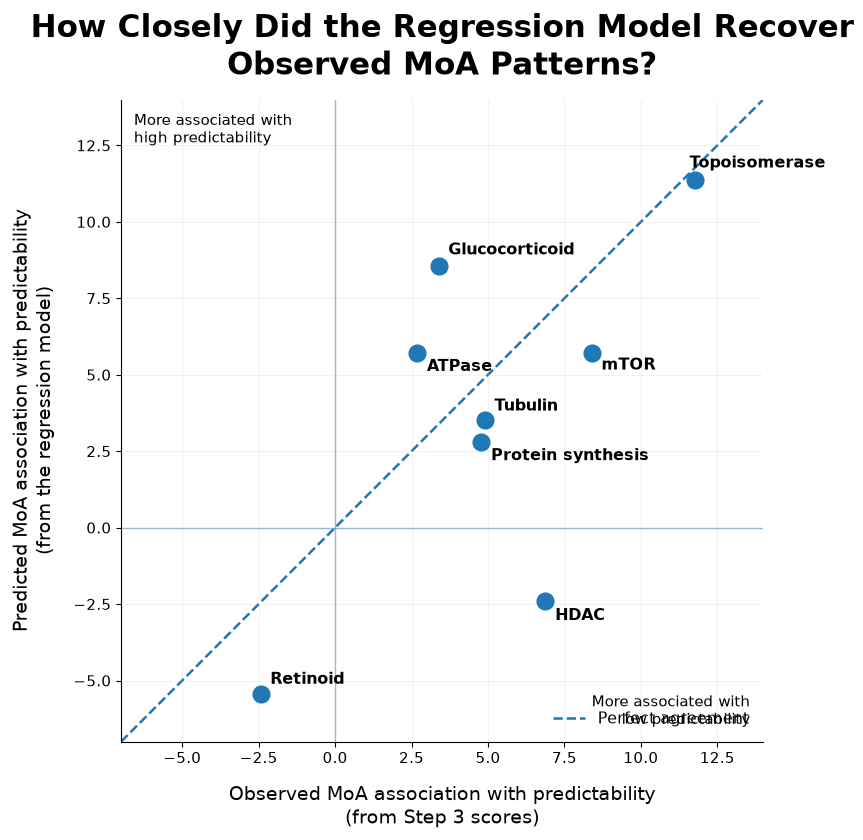


Saved figure:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_observed_vs_predicted_moa_scatter.png

Saved PDF:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_observed_vs_predicted_moa_scatter.pdf


In [12]:
# Scatter plot

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Locate project folders

cwd = Path.cwd()

if (cwd / "data" / "step3_multimodal").exists():
    PROJECT_ROOT = cwd

elif (cwd.parent / "data" / "step3_multimodal").exists():
    PROJECT_ROOT = cwd.parent

else:
    raise FileNotFoundError(
        f"Could not locate the project root from: {cwd}"
    )


OUTPUT_DIR = (
    PROJECT_ROOT
    / "data"
    / "step3_multimodal"
    / "step4_expanded_n20"
)

FIG_DIR = (
    PROJECT_ROOT
    / "figures"
    / "step4_expanded_n20"
)

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# Load the saved MoA comparison table

candidate_paths = [
    OUTPUT_DIR
    / "step4_n20_observed_vs_predicted_moa_paired_dot_data.csv",

    OUTPUT_DIR
    / "step4_n20_moa_observed_vs_predicted_grouped_bars.csv",
]

DATA_PATH = next(
    (
        path
        for path in candidate_paths
        if path.exists()
    ),
    None,
)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find a saved MoA comparison table:\n"
        + "\n".join(
            str(path)
            for path in candidate_paths
        )
    )


comparison_data = pd.read_csv(
    DATA_PATH
)

required_columns = [
    "moa",
    "observed_difference",
    "predicted_difference",
]

missing_columns = [
    column
    for column in required_columns
    if column not in comparison_data.columns
]

if missing_columns:
    raise KeyError(
        f"Missing columns: {missing_columns}\n"
        f"Available columns: {comparison_data.columns.tolist()}"
    )


# Select the same eight MoAs

moa_order = [
    "Topoisomerase inhibitor",
    "mTOR inhibitor",
    "HDAC inhibitor",
    "Tubulin polymerization inhibitor",
    "Protein synthesis inhibitor",
    "Glucocorticoid receptor agonist",
    "ATPase inhibitor",
    "Retinoid receptor agonist",
]

scatter_data = (
    comparison_data.loc[
        comparison_data["moa"].isin(moa_order),
        required_columns,
    ]
    .copy()
)

scatter_data["moa"] = pd.Categorical(
    scatter_data["moa"],
    categories=moa_order,
    ordered=True,
)

scatter_data = (
    scatter_data
    .sort_values("moa")
    .reset_index(drop=True)
)

display(scatter_data)


# Short labels 

short_labels = {
    "Topoisomerase inhibitor": "Topoisomerase",
    "mTOR inhibitor": "mTOR",
    "HDAC inhibitor": "HDAC",
    "Tubulin polymerization inhibitor": "Tubulin",
    "Protein synthesis inhibitor": "Protein synthesis",
    "Glucocorticoid receptor agonist": "Glucocorticoid",
    "ATPase inhibitor": "ATPase",
    "Retinoid receptor agonist": "Retinoid",
}


# Prepare plotting 

observed = scatter_data[
    "observed_difference"
].to_numpy(dtype=float)

predicted = scatter_data[
    "predicted_difference"
].to_numpy(dtype=float)


# Create figure

fig, ax = plt.subplots(
    figsize=(10.5, 8.5)
)

ax.scatter(
    observed,
    predicted,
    s=145,
    zorder=3,
)


# Add perfect-agreement line

all_values = np.concatenate(
    [
        observed,
        predicted,
    ]
)

minimum = np.floor(
    all_values.min() - 1.5
)

maximum = np.ceil(
    all_values.max() + 1.5
)

ax.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
    linewidth=1.8,
    label="Perfect agreement",
    zorder=1,
)


# Zero lines 
ax.axhline(
    0,
    linewidth=1,
    alpha=0.45,
)

ax.axvline(
    0,
    linewidth=1,
    alpha=0.45,
)


# Label each MoA

label_offsets = {
    "Topoisomerase inhibitor": (-4, 9),
    "mTOR inhibitor": (7, -12),
    "HDAC inhibitor": (7, -14),
    "Tubulin polymerization inhibitor": (7, 7),
    "Protein synthesis inhibitor": (7, -13),
    "Glucocorticoid receptor agonist": (7, 8),
    "ATPase inhibitor": (7, -13),
    "Retinoid receptor agonist": (7, 7),
}

for _, row in scatter_data.iterrows():
    moa = str(row["moa"])

    x_offset, y_offset = label_offsets.get(
        moa,
        (6, 6),
    )

    ax.annotate(
        short_labels.get(
            moa,
            moa,
        ),
        (
            row["observed_difference"],
            row["predicted_difference"],
        ),
        xytext=(
            x_offset,
            y_offset,
        ),
        textcoords="offset points",
        fontsize=11.5,
        fontweight="bold",
    )


# Labels and title

ax.set_title(
    "How Closely Did the Regression Model Recover\n"
    "Observed MoA Patterns?",
    fontsize=22,
    fontweight="bold",
    pad=18,
)

ax.set_xlabel(
    "Observed MoA association with predictability\n"
    "(from Step 3 scores)",
    fontsize=14,
    labelpad=12,
)

ax.set_ylabel(
    "Predicted MoA association with predictability\n"
    "(from the regression model)",
    fontsize=14,
    labelpad=12,
)

ax.text(
    0.02,
    0.98,
    "More associated with\nhigh predictability",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10.5,
)

ax.text(
    0.98,
    0.02,
    "More associated with\nlow predictability",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=10.5,
)


# Formatting

ax.set_xlim(
    minimum,
    maximum,
)

ax.set_ylim(
    minimum,
    maximum,
)

ax.set_aspect(
    "equal",
    adjustable="box",
)

ax.grid(
    alpha=0.16,
)

ax.tick_params(
    labelsize=11,
)

ax.legend(
    frameon=False,
    fontsize=11.5,
    loc="lower right",
)

for spine in [
    "top",
    "right",
]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()


# Save figure

FIGURE_PATH = (
    FIG_DIR
    / "step4_n20_observed_vs_predicted_moa_scatter.png"
)

PDF_PATH = (
    FIG_DIR
    / "step4_n20_observed_vs_predicted_moa_scatter.pdf"
)

fig.savefig(
    FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    PDF_PATH,
    bbox_inches="tight",
)

plt.show()

print("\nSaved figure:")
print(FIGURE_PATH)

print("\nSaved PDF:")
print(PDF_PATH)

,moa,observed_difference,predicted_difference
0,Topoisomerase inhibitor,11.774404,11.367663
1,mTOR inhibitor,8.391608,5.714286
2,HDAC inhibitor,6.879300,-2.386489
3,Tubulin polymerization inhibitor,4.895105,3.510520
4,Protein synthesis inhibitor,4.781397,2.796235
5,Glucocorticoid receptor agonist,3.382796,8.571429
6,ATPase inhibitor,2.683495,5.714286
7,Retinoid receptor agonist,-2.439024,-5.426357


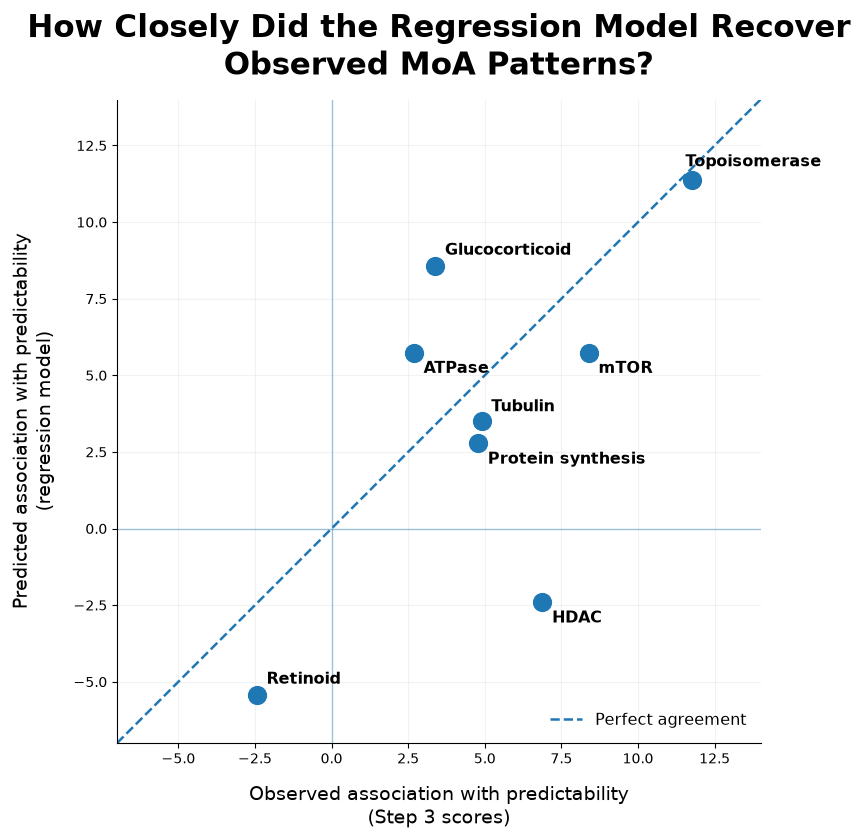


Saved figure:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_observed_vs_predicted_moa_scatter_final.png

Saved PDF:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_observed_vs_predicted_moa_scatter_final.pdf


In [13]:
# Scatter plot

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Locate project

cwd = Path.cwd()

if (cwd / "data" / "step3_multimodal").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data" / "step3_multimodal").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        f"Could not locate project root from: {cwd}"
    )

OUTPUT_DIR = (
    PROJECT_ROOT
    / "data"
    / "step3_multimodal"
    / "step4_expanded_n20"
)

FIG_DIR = (
    PROJECT_ROOT
    / "figures"
    / "step4_expanded_n20"
)

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# Load 

candidate_paths = [
    OUTPUT_DIR
    / "step4_n20_observed_vs_predicted_moa_paired_dot_data.csv",

    OUTPUT_DIR
    / "step4_n20_moa_observed_vs_predicted_grouped_bars.csv",
]

DATA_PATH = next(
    (
        path
        for path in candidate_paths
        if path.exists()
    ),
    None,
)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find the saved MoA comparison table."
    )

comparison_data = pd.read_csv(DATA_PATH)

required_columns = [
    "moa",
    "observed_difference",
    "predicted_difference",
]

missing_columns = [
    column
    for column in required_columns
    if column not in comparison_data.columns
]

if missing_columns:
    raise KeyError(
        f"Missing columns: {missing_columns}\n"
        f"Available: {comparison_data.columns.tolist()}"
    )


# Select the same eight MoAs

moa_order = [
    "Topoisomerase inhibitor",
    "mTOR inhibitor",
    "HDAC inhibitor",
    "Tubulin polymerization inhibitor",
    "Protein synthesis inhibitor",
    "Glucocorticoid receptor agonist",
    "ATPase inhibitor",
    "Retinoid receptor agonist",
]

scatter_data = (
    comparison_data.loc[
        comparison_data["moa"].isin(moa_order),
        required_columns,
    ]
    .copy()
)

scatter_data["moa"] = pd.Categorical(
    scatter_data["moa"],
    categories=moa_order,
    ordered=True,
)

scatter_data = (
    scatter_data
    .sort_values("moa")
    .reset_index(drop=True)
)

display(scatter_data)


short_labels = {
    "Topoisomerase inhibitor": "Topoisomerase",
    "mTOR inhibitor": "mTOR",
    "HDAC inhibitor": "HDAC",
    "Tubulin polymerization inhibitor": "Tubulin",
    "Protein synthesis inhibitor": "Protein synthesis",
    "Glucocorticoid receptor agonist": "Glucocorticoid",
    "ATPase inhibitor": "ATPase",
    "Retinoid receptor agonist": "Retinoid",
}


# Plot

observed = scatter_data[
    "observed_difference"
].to_numpy(dtype=float)

predicted = scatter_data[
    "predicted_difference"
].to_numpy(dtype=float)

all_values = np.concatenate(
    [observed, predicted]
)

axis_min = np.floor(
    all_values.min() - 1.5
)

axis_max = np.ceil(
    all_values.max() + 1.5
)


fig, ax = plt.subplots(
    figsize=(10.5, 8.5)
)

ax.scatter(
    observed,
    predicted,
    s=165,
    zorder=3,
)

ax.plot(
    [axis_min, axis_max],
    [axis_min, axis_max],
    linestyle="--",
    linewidth=1.8,
    label="Perfect agreement",
)

ax.axhline(
    0,
    linewidth=1,
    alpha=0.4,
)

ax.axvline(
    0,
    linewidth=1,
    alpha=0.4,
)


label_offsets = {
    "Topoisomerase inhibitor": (-5, 10),
    "mTOR inhibitor": (7, -14),
    "HDAC inhibitor": (7, -15),
    "Tubulin polymerization inhibitor": (7, 7),
    "Protein synthesis inhibitor": (7, -15),
    "Glucocorticoid receptor agonist": (7, 8),
    "ATPase inhibitor": (7, -14),
    "Retinoid receptor agonist": (7, 8),
}

for _, row in scatter_data.iterrows():
    moa = str(row["moa"])

    x_offset, y_offset = label_offsets.get(
        moa,
        (6, 6),
    )

    ax.annotate(
        short_labels.get(moa, moa),
        (
            row["observed_difference"],
            row["predicted_difference"],
        ),
        xytext=(
            x_offset,
            y_offset,
        ),
        textcoords="offset points",
        fontsize=11.5,
        fontweight="bold",
    )


ax.set_title(
    "How Closely Did the Regression Model Recover\n"
    "Observed MoA Patterns?",
    fontsize=22,
    fontweight="bold",
    pad=18,
)

ax.set_xlabel(
    "Observed association with predictability\n"
    "(Step 3 scores)",
    fontsize=14,
    labelpad=12,
)

ax.set_ylabel(
    "Predicted association with predictability\n"
    "(regression model)",
    fontsize=14,
    labelpad=12,
)

ax.set_xlim(
    axis_min,
    axis_max,
)

ax.set_ylim(
    axis_min,
    axis_max,
)

ax.set_aspect(
    "equal",
    adjustable="box",
)

ax.grid(
    alpha=0.16,
)

ax.legend(
    frameon=False,
    fontsize=11.5,
    loc="lower right",
)

for spine in [
    "top",
    "right",
]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()


FIGURE_PATH = (
    FIG_DIR
    / "step4_n20_observed_vs_predicted_moa_scatter_final.png"
)

PDF_PATH = (
    FIG_DIR
    / "step4_n20_observed_vs_predicted_moa_scatter_final.pdf"
)

fig.savefig(
    FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    PDF_PATH,
    bbox_inches="tight",
)

plt.show()

print("\nSaved figure:")
print(FIGURE_PATH)

print("\nSaved PDF:")
print(PDF_PATH)

,moa,observed_difference,predicted_difference
0,ATPase inhibitor,2.683495,5.714286
1,mTOR inhibitor,8.391608,5.714286
2,Glucocorticoid receptor agonist,3.382796,8.571429
3,Topoisomerase inhibitor,11.774404,11.367663


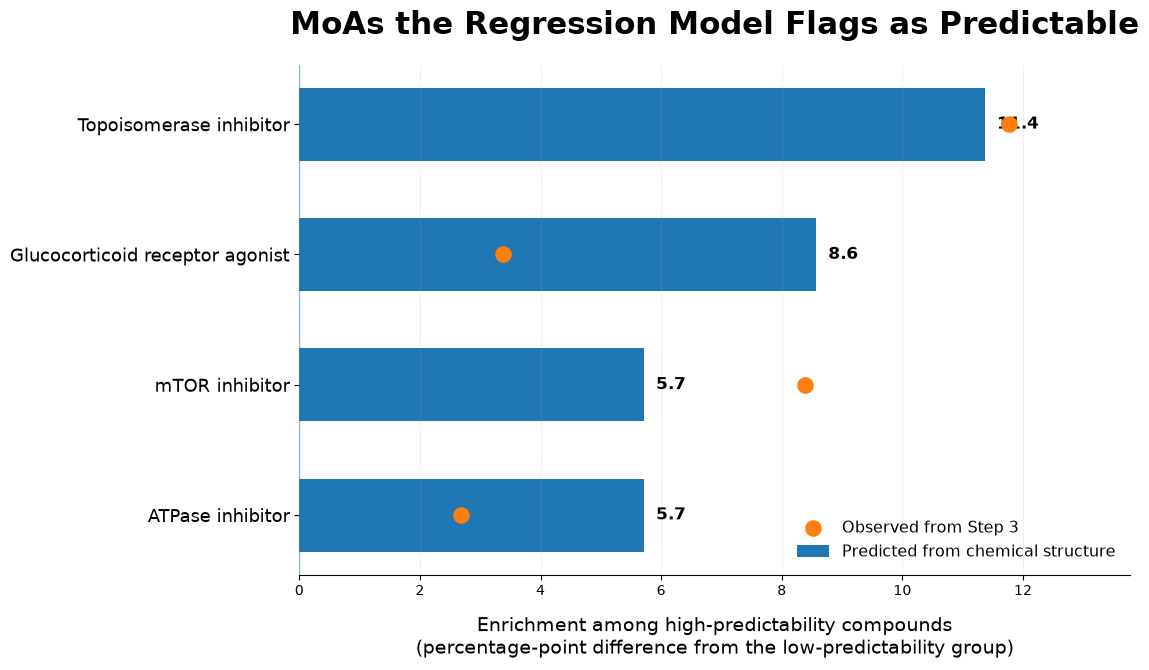


Saved figure:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_moas_model_flags_as_predictable.png

Saved PDF:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_moas_model_flags_as_predictable.pdf

Saved data:
/Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/step4_n20_moas_model_flags_as_predictable.csv


In [15]:


from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



# Locate 

cwd = Path.cwd()

if (cwd / "data" / "step3_multimodal").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data" / "step3_multimodal").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        f"Could not locate project root from: {cwd}"
    )

OUTPUT_DIR = (
    PROJECT_ROOT
    / "data"
    / "step3_multimodal"
    / "step4_expanded_n20"
)

FIG_DIR = (
    PROJECT_ROOT
    / "figures"
    / "step4_expanded_n20"
)

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# Load

candidate_paths = [
    OUTPUT_DIR
    / "step4_n20_observed_vs_predicted_moa_paired_dot_data.csv",

    OUTPUT_DIR
    / "step4_n20_moa_observed_vs_predicted_grouped_bars.csv",
]

DATA_PATH = next(
    (
        path
        for path in candidate_paths
        if path.exists()
    ),
    None,
)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find the saved MoA comparison table."
    )

comparison_data = pd.read_csv(DATA_PATH)

required_columns = [
    "moa",
    "observed_difference",
    "predicted_difference",
]

missing_columns = [
    column
    for column in required_columns
    if column not in comparison_data.columns
]

if missing_columns:
    raise KeyError(
        f"Missing columns: {missing_columns}\n"
        f"Available: {comparison_data.columns.tolist()}"
    )




top_model_moas = (
    comparison_data.loc[
        comparison_data["predicted_difference"] > 0,
        required_columns,
    ]
    .sort_values(
        "predicted_difference",
        ascending=False,
    )
    .head(4)
    .copy()
    .sort_values(
        "predicted_difference",
        ascending=True,
    )
    .reset_index(drop=True)
)

display(top_model_moas)

# Plot

y = np.arange(
    len(top_model_moas)
)

predicted = top_model_moas[
    "predicted_difference"
].to_numpy(dtype=float)

observed = top_model_moas[
    "observed_difference"
].to_numpy(dtype=float)


fig, ax = plt.subplots(
    figsize=(11.5, 6.8)
)

bars = ax.barh(
    y,
    predicted,
    height=0.56,
    label="Predicted from chemical structure",
)

ax.scatter(
    observed,
    y,
    s=120,
    zorder=4,
    label="Observed from Step 3",
)


for bar in bars:
    value = bar.get_width()

    ax.text(
        value + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}",
        ha="left",
        va="center",
        fontsize=12,
        fontweight="bold",
    )


ax.set_yticks(y)

ax.set_yticklabels(
    top_model_moas["moa"],
    fontsize=13,
)

ax.set_title(
    "MoAs the Regression Model Flags as Predictable",
    fontsize=22,
    fontweight="bold",
    pad=22,
)

ax.set_xlabel(
    "Enrichment among high-predictability compounds\n"
    "(percentage-point difference from the low-predictability group)",
    fontsize=13.5,
    labelpad=12,
)

ax.axvline(
    0,
    linewidth=1,
    alpha=0.5,
)

ax.grid(
    axis="x",
    alpha=0.18,
)

ax.legend(
    frameon=False,
    fontsize=11.5,
    loc="lower right",
)

for spine in [
    "top",
    "right",
    "left",
]:
    ax.spines[spine].set_visible(False)

maximum_value = max(
    predicted.max(),
    observed.max(),
)

ax.set_xlim(
    0,
    maximum_value + 2,
)

fig.tight_layout()


FIGURE_PATH = (
    FIG_DIR
    / "step4_n20_moas_model_flags_as_predictable.png"
)

PDF_PATH = (
    FIG_DIR
    / "step4_n20_moas_model_flags_as_predictable.pdf"
)

TABLE_PATH = (
    OUTPUT_DIR
    / "step4_n20_moas_model_flags_as_predictable.csv"
)

fig.savefig(
    FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    PDF_PATH,
    bbox_inches="tight",
)

top_model_moas.to_csv(
    TABLE_PATH,
    index=False,
)

plt.show()

print("\nSaved figure:")
print(FIGURE_PATH)

print("\nSaved PDF:")
print(PDF_PATH)

print("\nSaved data:")
print(TABLE_PATH)

MoA columns:
['compound_embedding_row_index', 'compound_name', 'n_profiles', 'actual_predictability', 'predicted_predictability', 'model_prediction_group', 'observed_predictability_group', 'moa', 'moa_annotation']

Prediction columns:
['compound_embedding_row_index', 'compound_name', 'n_profiles', 'source_normalized_inverted_score', 'actual_predictability', 'predicted_predictability', 'prediction_sd', 'residual', 'absolute_error', 'predicted_rank', 'predicted_quintile']

Merged compound–MoA rows: 266
Unique compounds: 266
Unique MoAs: 201


,moa,n_compounds,observed_mean,observed_ci_lower,observed_ci_upper,predicted_mean,predicted_ci_lower,predicted_ci_upper,prediction_error,absolute_prediction_error
0,ATPase inhibitor,5,0.947097,0.928173,0.969418,0.872911,0.866244,0.880114,-0.074186,0.074186
1,Topoisomerase inhibitor; topoisomerase inhibitor,7,0.941254,0.920376,0.966339,0.885042,0.849958,0.923143,-0.056212,0.056212
2,MTOR inhibitor; mTOR inhibitor,5,0.927392,0.913810,0.939397,0.860188,0.836048,0.885254,-0.067204,0.067204
3,HDAC inhibitor,10,0.913415,0.853239,0.955390,0.824842,0.812920,0.834438,-0.088573,0.088573
4,HSP inhibitor,8,0.822951,0.700744,0.938623,0.845910,0.815556,0.881399,0.022960,0.022960


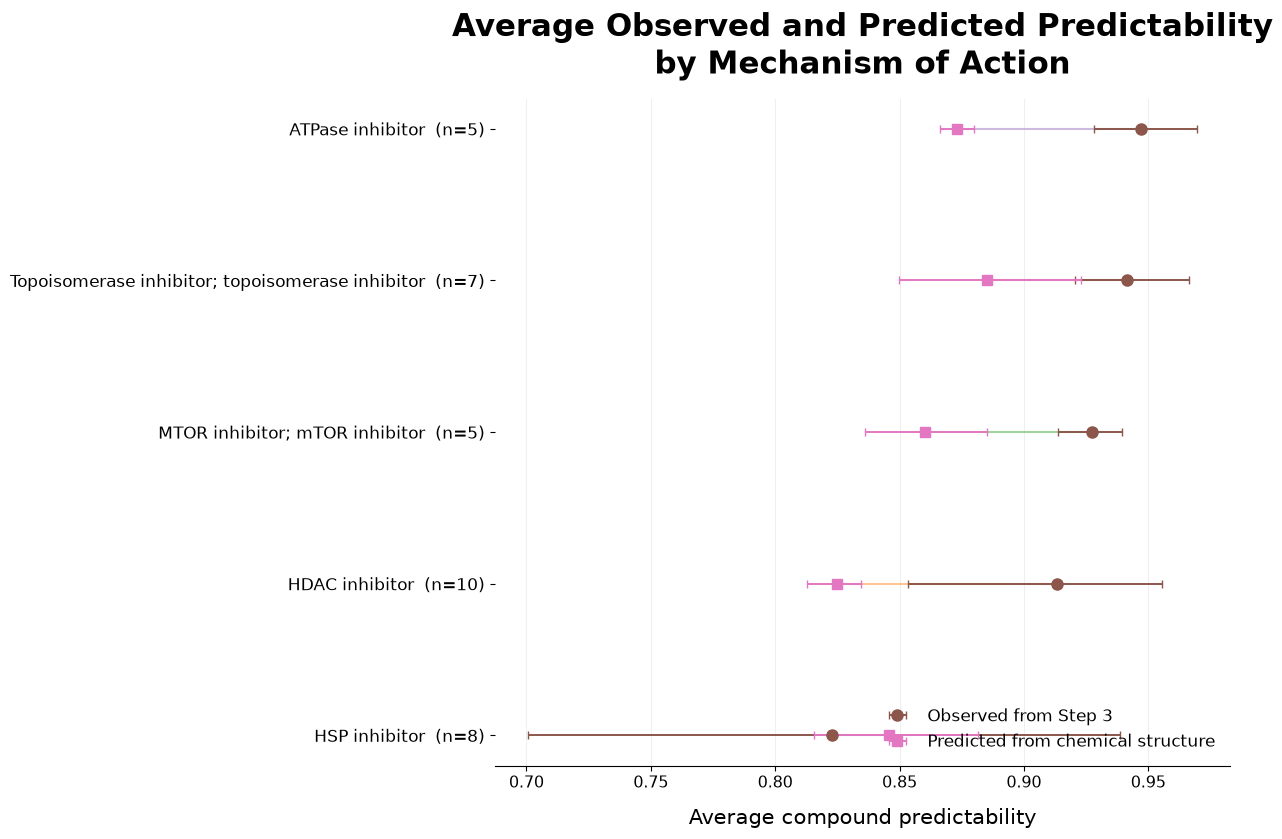


Saved MoA summary:
/Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/step4_n20_average_predictability_by_moa.csv

Saved figure:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_average_predictability_by_moa.png

Saved PDF:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_average_predictability_by_moa.pdf


In [1]:
# Average observed and predicted predictability by MoA

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Locate project 

cwd = Path.cwd()

if (cwd / "data" / "step3_multimodal").exists():
    PROJECT_ROOT = cwd

elif (cwd.parent / "data" / "step3_multimodal").exists():
    PROJECT_ROOT = cwd.parent

else:
    raise FileNotFoundError(
        f"Could not locate the project root from: {cwd}"
    )


OUTPUT_DIR = (
    PROJECT_ROOT
    / "data"
    / "step3_multimodal"
    / "step4_expanded_n20"
)

FIG_DIR = (
    PROJECT_ROOT
    / "figures"
    / "step4_expanded_n20"
)

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# 2. Load compound-level MoA annotations and predictions

MOA_PATH = (
    OUTPUT_DIR
    / "step4_n20_clean_observed_moa_long.csv"
)

PREDICTIONS_PATH = (
    OUTPUT_DIR
    / "step4_extra_trees_n20_oof_predictions_with_groups.csv"
)

if not MOA_PATH.exists():
    raise FileNotFoundError(
        f"Missing MoA file:\n{MOA_PATH}"
    )

if not PREDICTIONS_PATH.exists():
    raise FileNotFoundError(
        f"Missing predictions file:\n{PREDICTIONS_PATH}"
    )


moa_data = pd.read_csv(MOA_PATH)
prediction_data = pd.read_csv(PREDICTIONS_PATH)

print("MoA columns:")
print(moa_data.columns.tolist())

print("\nPrediction columns:")
print(prediction_data.columns.tolist())

# 3. Keep and standardize required columns

compound_key = "compound_embedding_row_index"

required_moa_columns = [
    compound_key,
    "moa",
]

required_prediction_columns = [
    compound_key,
    "actual_predictability",
    "predicted_predictability",
]

for column in required_moa_columns:
    if column not in moa_data.columns:
        raise KeyError(
            f"Missing '{column}' from MoA table."
        )

for column in required_prediction_columns:
    if column not in prediction_data.columns:
        raise KeyError(
            f"Missing '{column}' from prediction table."
        )


compound_moa = (
    moa_data[
        required_moa_columns
    ]
    .copy()
)

compound_scores = (
    prediction_data[
        required_prediction_columns
    ]
    .copy()
)


compound_moa[compound_key] = pd.to_numeric(
    compound_moa[compound_key],
    errors="coerce",
)

compound_scores[compound_key] = pd.to_numeric(
    compound_scores[compound_key],
    errors="coerce",
)

compound_scores["actual_predictability"] = pd.to_numeric(
    compound_scores["actual_predictability"],
    errors="coerce",
)

compound_scores["predicted_predictability"] = pd.to_numeric(
    compound_scores["predicted_predictability"],
    errors="coerce",
)

compound_moa["moa"] = (
    compound_moa["moa"]
    .astype(str)
    .str.strip()
)


compound_moa = (
    compound_moa
    .dropna(
        subset=[
            compound_key,
            "moa",
        ]
    )
    .drop_duplicates(
        subset=[
            compound_key,
            "moa",
        ]
    )
)

compound_scores = (
    compound_scores
    .dropna(
        subset=[
            compound_key,
            "actual_predictability",
            "predicted_predictability",
        ]
    )
    .drop_duplicates(
        subset=compound_key
    )
)


merged = compound_moa.merge(
    compound_scores,
    on=compound_key,
    how="inner",
)

print(
    f"\nMerged compound–MoA rows: {len(merged):,}"
)

print(
    "Unique compounds:",
    merged[compound_key].nunique(),
)

print(
    "Unique MoAs:",
    merged["moa"].nunique(),
)


# 4. Helper

def bootstrap_mean_ci(
    values,
    n_bootstrap=2000,
    confidence_level=0.95,
    random_state=42,
):
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]

    if len(values) == 0:
        return np.nan, np.nan

    rng = np.random.default_rng(random_state)

    bootstrap_means = np.empty(
        n_bootstrap,
        dtype=float,
    )

    for index in range(n_bootstrap):
        sample = rng.choice(
            values,
            size=len(values),
            replace=True,
        )

        bootstrap_means[index] = sample.mean()

    alpha = 1 - confidence_level

    lower = np.quantile(
        bootstrap_means,
        alpha / 2,
    )

    upper = np.quantile(
        bootstrap_means,
        1 - alpha / 2,
    )

    return lower, upper

# 5. Calculate mean predictability for every MoA

MIN_COMPOUNDS = 5

summary_rows = []

for moa, group in merged.groupby("moa"):
    group = group.drop_duplicates(
        subset=compound_key
    )

    n_compounds = group[
        compound_key
    ].nunique()

    if n_compounds < MIN_COMPOUNDS:
        continue

    observed_values = group[
        "actual_predictability"
    ].to_numpy(dtype=float)

    predicted_values = group[
        "predicted_predictability"
    ].to_numpy(dtype=float)

    observed_mean = observed_values.mean()
    predicted_mean = predicted_values.mean()

    observed_lower, observed_upper = bootstrap_mean_ci(
        observed_values,
        random_state=42,
    )

    predicted_lower, predicted_upper = bootstrap_mean_ci(
        predicted_values,
        random_state=43,
    )

    summary_rows.append(
        {
            "moa": moa,
            "n_compounds": n_compounds,
            "observed_mean": observed_mean,
            "observed_ci_lower": observed_lower,
            "observed_ci_upper": observed_upper,
            "predicted_mean": predicted_mean,
            "predicted_ci_lower": predicted_lower,
            "predicted_ci_upper": predicted_upper,
            "prediction_error": (
                predicted_mean
                - observed_mean
            ),
            "absolute_prediction_error": abs(
                predicted_mean
                - observed_mean
            ),
        }
    )


moa_summary = pd.DataFrame(
    summary_rows
)

moa_summary = (
    moa_summary
    .sort_values(
        "observed_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(moa_summary.head(20))


# 6. Select MoAs for the figure

# Show the 12 MoAs with the highest observed average predictability.
# Change if nec

N_MOAS_TO_SHOW = 12

plot_data = (
    moa_summary
    .head(N_MOAS_TO_SHOW)
    .copy()
    .sort_values(
        "observed_mean",
        ascending=True,
    )
    .reset_index(drop=True)
)


# 7. Prepare error bars

y_positions = np.arange(
    len(plot_data)
)

observed_xerr = np.vstack(
    [
        plot_data["observed_mean"]
        - plot_data["observed_ci_lower"],

        plot_data["observed_ci_upper"]
        - plot_data["observed_mean"],
    ]
)

predicted_xerr = np.vstack(
    [
        plot_data["predicted_mean"]
        - plot_data["predicted_ci_lower"],

        plot_data["predicted_ci_upper"]
        - plot_data["predicted_mean"],
    ]
)


# 8. Create horizontal dot plot

fig, ax = plt.subplots(
    figsize=(12.5, 8.5)
)


# Connect observed and predicted means
for y, observed_value, predicted_value in zip(
    y_positions,
    plot_data["observed_mean"],
    plot_data["predicted_mean"],
):
    ax.plot(
        [
            observed_value,
            predicted_value,
        ],
        [
            y,
            y,
        ],
        linewidth=1.5,
        alpha=0.45,
        zorder=1,
    )


ax.errorbar(
    plot_data["observed_mean"],
    y_positions,
    xerr=observed_xerr,
    fmt="o",
    markersize=8,
    capsize=3,
    linewidth=1.4,
    label="Observed from Step 3",
    zorder=3,
)

ax.errorbar(
    plot_data["predicted_mean"],
    y_positions,
    xerr=predicted_xerr,
    fmt="s",
    markersize=7,
    capsize=3,
    linewidth=1.4,
    label="Predicted from chemical structure",
    zorder=3,
)


# 9. Labels and formatting

y_labels = [
    f"{moa}  (n={n})"
    for moa, n in zip(
        plot_data["moa"],
        plot_data["n_compounds"],
    )
]

ax.set_yticks(
    y_positions
)

ax.set_yticklabels(
    y_labels,
    fontsize=12,
)

ax.set_xlabel(
    "Average compound predictability",
    fontsize=15,
    labelpad=12,
)

ax.set_title(
    "Average Observed and Predicted Predictability\n"
    "by Mechanism of Action",
    fontsize=22,
    fontweight="bold",
    pad=18,
)

ax.grid(
    axis="x",
    alpha=0.2,
)

ax.tick_params(
    axis="x",
    labelsize=11.5,
)

ax.legend(
    frameon=False,
    fontsize=12,
    loc="lower right",
)

for spine in [
    "top",
    "right",
    "left",
]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()


# 10. Save results

SUMMARY_PATH = (
    OUTPUT_DIR
    / "step4_n20_average_predictability_by_moa.csv"
)

FIGURE_PATH = (
    FIG_DIR
    / "step4_n20_average_predictability_by_moa.png"
)

PDF_PATH = (
    FIG_DIR
    / "step4_n20_average_predictability_by_moa.pdf"
)

moa_summary.to_csv(
    SUMMARY_PATH,
    index=False,
)

fig.savefig(
    FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    PDF_PATH,
    bbox_inches="tight",
)

plt.show()


print("\nSaved MoA summary:")
print(SUMMARY_PATH)

print("\nSaved figure:")
print(FIGURE_PATH)

print("\nSaved PDF:")
print(PDF_PATH)

,moa,n_compounds,observed_mean,predicted_mean
0,ATPase inhibitor,5,0.947097,0.872911
1,Topoisomerase inhibitor; topoisomerase inhibitor,7,0.941254,0.885042
2,MTOR inhibitor; mTOR inhibitor,5,0.927392,0.860188
3,HDAC inhibitor,10,0.913415,0.824842
4,HSP inhibitor,8,0.822951,0.845910


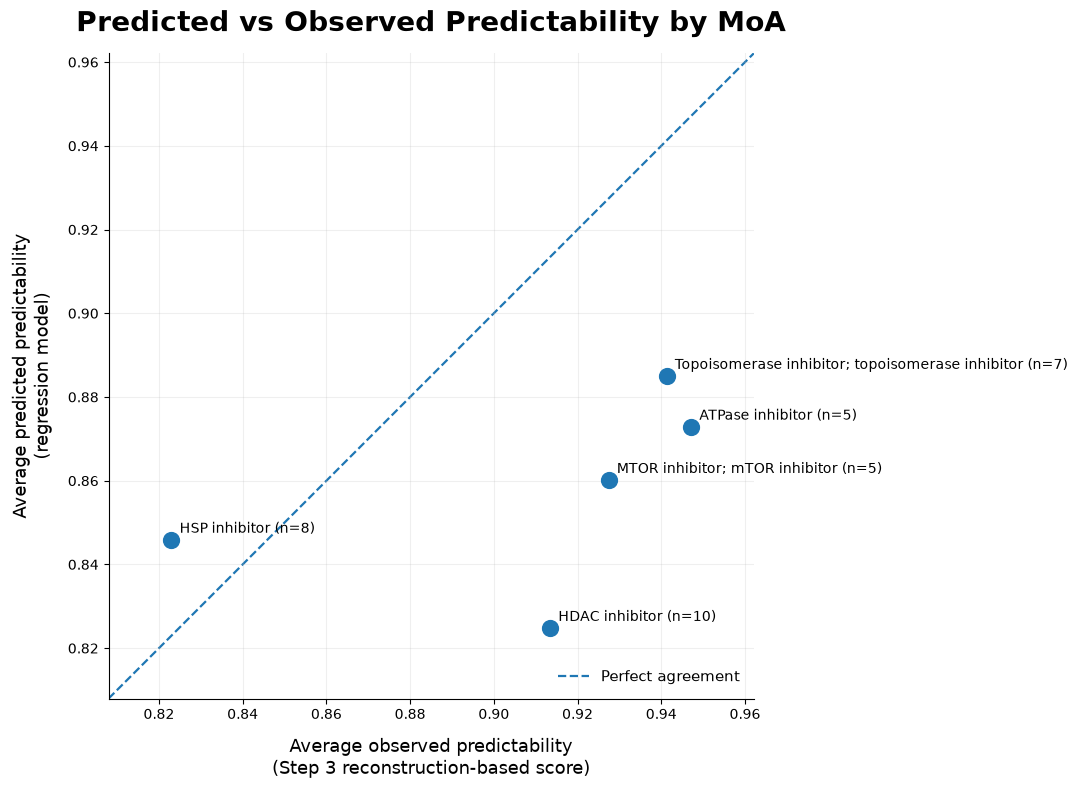


Saved figure:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_average_observed_vs_predicted_moa_xy.png

Saved PDF:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_average_observed_vs_predicted_moa_xy.pdf

Saved data:
/Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/step4_n20_average_observed_vs_predicted_moa_xy.csv


In [4]:
# XY plot of average observed vs average predicted predictability by MoA

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Check summary table

required_columns = [
    "moa",
    "n_compounds",
    "observed_mean",
    "predicted_mean",
]

missing_columns = [
    column
    for column in required_columns
    if column not in moa_summary.columns
]

if missing_columns:
    raise KeyError(
        f"moa_summary is missing columns: {missing_columns}"
    )


# Select MoAs to show

MIN_COMPOUNDS = 5
N_MOAS_TO_SHOW = 12

scatter_data = (
    moa_summary[
        moa_summary["n_compounds"] >= MIN_COMPOUNDS
    ]
    .copy()
)

display(
    scatter_data[
        [
            "moa",
            "n_compounds",
            "observed_mean",
            "predicted_mean",
        ]
    ]
)


# Clean duplicated MoA labels, if present

def clean_moa_label(label):
    parts = [
        part.strip()
        for part in str(label).split(";")
        if part.strip()
    ]

    unique_parts = list(dict.fromkeys(parts))

    return "; ".join(unique_parts)


scatter_data["clean_moa"] = (
    scatter_data["moa"]
    .apply(clean_moa_label)
)


# Create scatter plot

fig, ax = plt.subplots(
    figsize=(10, 8)
)

ax.scatter(
    scatter_data["observed_mean"],
    scatter_data["predicted_mean"],
    s=130,
    zorder=3,
)


# Add perfect-agreement diagonal

all_values = np.concatenate(
    [
        scatter_data["observed_mean"].to_numpy(),
        scatter_data["predicted_mean"].to_numpy(),
    ]
)

axis_min = all_values.min() - 0.015
axis_max = all_values.max() + 0.015

ax.plot(
    [axis_min, axis_max],
    [axis_min, axis_max],
    linestyle="--",
    linewidth=1.6,
    label="Perfect agreement",
    zorder=1,
)


# Label points

for _, row in scatter_data.iterrows():
    ax.annotate(
        f"{row['clean_moa']} (n={int(row['n_compounds'])})",
        (
            row["observed_mean"],
            row["predicted_mean"],
        ),
        xytext=(6, 5),
        textcoords="offset points",
        fontsize=10,
    )


# Titles and labels

ax.set_title(
    "Predicted vs Observed Predictability by MoA",
    fontsize=20,
    fontweight="bold",
    pad=16,
)

ax.set_xlabel(
    "Average observed predictability\n"
    "(Step 3 reconstruction-based score)",
    fontsize=13,
    labelpad=10,
)

ax.set_ylabel(
    "Average predicted predictability\n"
    "(regression model)",
    fontsize=13,
    labelpad=10,
)

ax.set_xlim(
    axis_min,
    axis_max,
)

ax.set_ylim(
    axis_min,
    axis_max,
)

ax.set_aspect(
    "equal",
    adjustable="box",
)

ax.grid(
    alpha=0.2,
)

ax.legend(
    frameon=False,
    fontsize=11,
    loc="lower right",
)

for spine in [
    "top",
    "right",
]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()


# Save figure

FIGURE_PATH = (
    FIG_DIR
    / "step4_n20_average_observed_vs_predicted_moa_xy.png"
)

PDF_PATH = (
    FIG_DIR
    / "step4_n20_average_observed_vs_predicted_moa_xy.pdf"
)

TABLE_PATH = (
    OUTPUT_DIR
    / "step4_n20_average_observed_vs_predicted_moa_xy.csv"
)

fig.savefig(
    FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    PDF_PATH,
    bbox_inches="tight",
)

scatter_data.to_csv(
    TABLE_PATH,
    index=False,
)

plt.show()

print("\nSaved figure:")
print(FIGURE_PATH)

print("\nSaved PDF:")
print(PDF_PATH)

print("\nSaved data:")
print(TABLE_PATH)

Number of MoAs: 5
Pearson r: 0.500 (p=0.391)
Spearman rho: 0.800 (p=0.104)
MAE: 0.0618
RMSE: 0.0657
R²: -1.104
Plotting 5 MoAs with at least 5 compounds.


,moa,clean_moa,n_compounds,observed_mean,predicted_mean
0,ATPase inhibitor,ATPase inhibitor,5,0.947097,0.872911
1,Topoisomerase inhibitor; topoisomerase inhibitor,Topoisomerase inhibitor,7,0.941254,0.885042
2,MTOR inhibitor; mTOR inhibitor,MTOR inhibitor,5,0.927392,0.860188
3,HDAC inhibitor,HDAC inhibitor,10,0.913415,0.824842
4,HSP inhibitor,HSP inhibitor,8,0.822951,0.845910


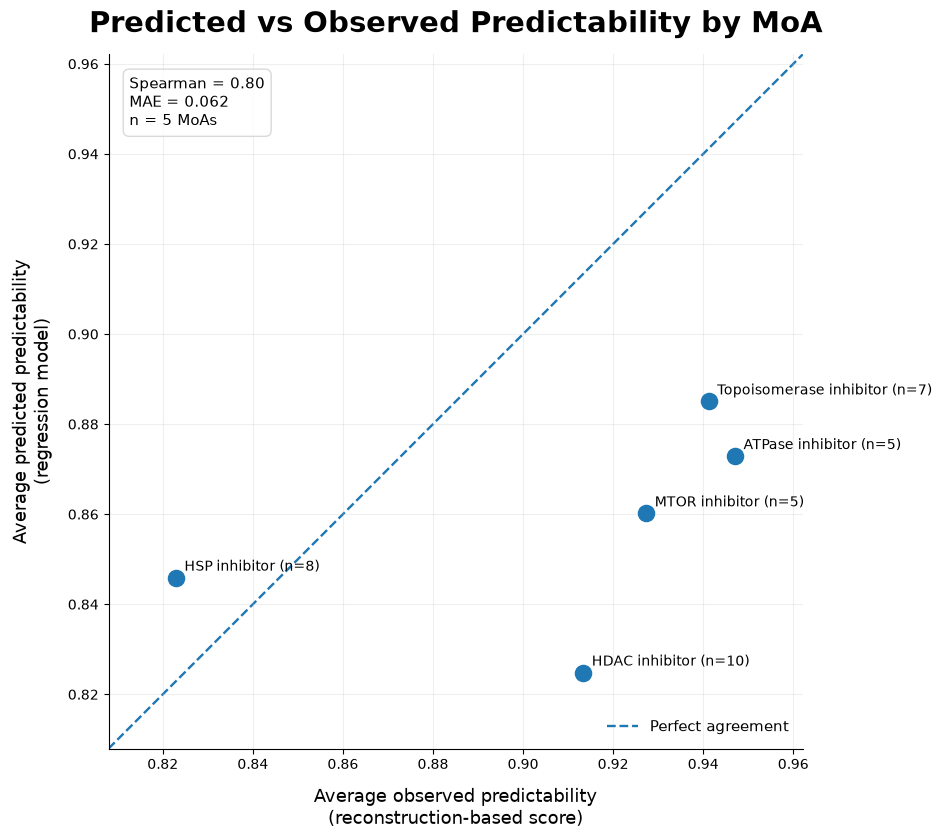


Saved figure:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_average_observed_vs_predicted_moa_xy_clean.png

Saved PDF:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_average_observed_vs_predicted_moa_xy_clean.pdf

Saved data:
/Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/step4_n20_average_observed_vs_predicted_moa_xy_clean.csv


In [6]:
# XY plot corrected
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Locate project folders

cwd = Path.cwd()

if (cwd / "data" / "step3_multimodal").exists():
    PROJECT_ROOT = cwd

elif (cwd.parent / "data" / "step3_multimodal").exists():
    PROJECT_ROOT = cwd.parent

else:
    raise FileNotFoundError(
        f"Could not locate project root from: {cwd}"
    )


OUTPUT_DIR = (
    PROJECT_ROOT
    / "data"
    / "step3_multimodal"
    / "step4_expanded_n20"
)

FIG_DIR = (
    PROJECT_ROOT
    / "figures"
    / "step4_expanded_n20"
)

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# Load MoA summary

SUMMARY_PATH = (
    OUTPUT_DIR
    / "step4_n20_average_predictability_by_moa.csv"
)

if not SUMMARY_PATH.exists():
    raise FileNotFoundError(
        f"Missing MoA summary file:\n{SUMMARY_PATH}"
    )

moa_summary = pd.read_csv(
    SUMMARY_PATH
)


required_columns = [
    "moa",
    "n_compounds",
    "observed_mean",
    "predicted_mean",
]

missing_columns = [
    column
    for column in required_columns
    if column not in moa_summary.columns
]

if missing_columns:
    raise KeyError(
        f"Missing columns: {missing_columns}\n"
        f"Available columns: {moa_summary.columns.tolist()}"
    )


# Clean duplicated MoA labels

def clean_moa_label(label):
    parts = [
        part.strip()
        for part in str(label).split(";")
        if part.strip()
    ]

    unique_parts = []

    for part in parts:
        if part.lower() not in {
            existing.lower()
            for existing in unique_parts
        }:
            unique_parts.append(part)

    return "; ".join(unique_parts)


moa_summary["clean_moa"] = (
    moa_summary["moa"]
    .apply(clean_moa_label)
)


# Include all MoAs represented by at least 5 compounds

MIN_COMPOUNDS = 5

scatter_data = (
    moa_summary.loc[
        moa_summary["n_compounds"] >= MIN_COMPOUNDS,
        [
            "moa",
            "clean_moa",
            "n_compounds",
            "observed_mean",
            "predicted_mean",
        ],
    ]
    .copy()
    .sort_values(
        "observed_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

observed = scatter_data["observed_mean"].to_numpy(dtype=float)
predicted = scatter_data["predicted_mean"].to_numpy(dtype=float)

pearson_r, pearson_p = pearsonr(observed, predicted)
spearman_r, spearman_p = spearmanr(observed, predicted)

mae = mean_absolute_error(observed, predicted)
rmse = mean_squared_error(observed, predicted) ** 0.5
r2 = r2_score(observed, predicted)

print(f"Number of MoAs: {len(scatter_data)}")
print(f"Pearson r: {pearson_r:.3f} (p={pearson_p:.3g})")
print(f"Spearman rho: {spearman_r:.3f} (p={spearman_p:.3g})")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.3f}")

print(
    f"Plotting {len(scatter_data)} MoAs "
    f"with at least {MIN_COMPOUNDS} compounds."
)

display(scatter_data)


# Prepare plotting range

observed = scatter_data[
    "observed_mean"
].to_numpy(dtype=float)

predicted = scatter_data[
    "predicted_mean"
].to_numpy(dtype=float)

all_values = np.concatenate(
    [
        observed,
        predicted,
    ]
)

axis_min = all_values.min() - 0.015
axis_max = all_values.max() + 0.015


# Create XY plot

fig, ax = plt.subplots(
    figsize=(10.5, 8.5)
)

ax.scatter(
    observed,
    predicted,
    s=135,
    zorder=3,
)


# Perfect-agreement line
ax.plot(
    [axis_min, axis_max],
    [axis_min, axis_max],
    linestyle="--",
    linewidth=1.7,
    label="Perfect agreement",
    zorder=1,
)


# Label each point with cleaned MoA name

for _, row in scatter_data.iterrows():
    ax.annotate(
        (
            f"{row['clean_moa']} "
            f"(n={int(row['n_compounds'])})"
        ),
        (
            row["observed_mean"],
            row["predicted_mean"],
        ),
        xytext=(6, 5),
        textcoords="offset points",
        fontsize=10,
    )


# Titles and axis labels

ax.set_title(
    "Predicted vs Observed Predictability by MoA",
    fontsize=21,
    fontweight="bold",
    pad=16,
)

ax.set_xlabel(
    "Average observed predictability\n"
    "(reconstruction-based score)",
    fontsize=13,
    labelpad=10,
)

ax.set_ylabel(
    "Average predicted predictability\n"
    "(regression model)",
    fontsize=13,
    labelpad=10,
)

ax.set_xlim(
    axis_min,
    axis_max,
)

ax.set_ylim(
    axis_min,
    axis_max,
)

ax.set_aspect(
    "equal",
    adjustable="box",
)

ax.grid(
    alpha=0.2,
)

ax.legend(
    frameon=False,
    fontsize=11,
    loc="lower right",
)

for spine in [
    "top",
    "right",
]:
    ax.spines[spine].set_visible(False)

metrics_text = (
    f"Spearman = {spearman_r:.2f}\n"
    f"MAE = {mae:.3f}\n"
    f"n = {len(scatter_data)} MoAs"
)

ax.text(
    0.03,
    0.97,
    metrics_text,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=11,
    bbox={
        "boxstyle": "round,pad=0.4",
        "facecolor": "white",
        "alpha": 0.85,
        "edgecolor": "lightgray",
    },
)

fig.tight_layout()


# Save outputs

FIGURE_PATH = (
    FIG_DIR
    / "step4_n20_average_observed_vs_predicted_moa_xy_clean.png"
)

PDF_PATH = (
    FIG_DIR
    / "step4_n20_average_observed_vs_predicted_moa_xy_clean.pdf"
)

TABLE_PATH = (
    OUTPUT_DIR
    / "step4_n20_average_observed_vs_predicted_moa_xy_clean.csv"
)

fig.savefig(
    FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    PDF_PATH,
    bbox_inches="tight",
)

scatter_data.to_csv(
    TABLE_PATH,
    index=False,
)

plt.show()


print("\nSaved figure:")
print(FIGURE_PATH)

print("\nSaved PDF:")
print(PDF_PATH)

print("\nSaved data:")
print(TABLE_PATH)

In [1]:
# Find

from pathlib import Path
import pandas as pd

# Locate

cwd = Path.cwd()

if (cwd / "data" / "step3_multimodal").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data" / "step3_multimodal").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        f"Could not locate project root from: {cwd}"
    )

OUTPUT_DIR = (
    PROJECT_ROOT
    / "data"
    / "step3_multimodal"
    / "step4_expanded_n20"
)

print("Project root:", PROJECT_ROOT)
print("Output folder:", OUTPUT_DIR)


# Load the 801-compound table

PREDICTIONS_PATH = (
    OUTPUT_DIR
    / "step4_extra_trees_n20_oof_predictions_with_groups.csv"
)

if not PREDICTIONS_PATH.exists():
    raise FileNotFoundError(
        f"Missing prediction file:\n{PREDICTIONS_PATH}"
    )

predictions = pd.read_csv(PREDICTIONS_PATH)

print("\nPrediction table")
print("----------------")
print("Rows:", len(predictions))
print("Columns:", predictions.columns.tolist())

if "compound_embedding_row_index" in predictions.columns:
    print(
        "Unique compounds:",
        predictions["compound_embedding_row_index"].nunique()
    )

if "predicted_quintile" in predictions.columns:
    print("\nPredicted quintile counts:")
    print(
        predictions["predicted_quintile"]
        .value_counts(dropna=False)
        .sort_index()
    )

# Inspect every MoA CSV 

moa_files = sorted(
    OUTPUT_DIR.glob("*moa*.csv")
)

print("\n\nMoA-related files found")
print("=======================")

if not moa_files:
    print("No MoA CSV files found.")

audit_rows = []

for path in moa_files:
    try:
        df = pd.read_csv(path)

        row = {
            "file": path.name,
            "rows": len(df),
            "columns": ", ".join(df.columns),
            "unique_compounds": None,
            "unique_moas": None,
            "prediction_groups": None,
            "observed_groups": None,
        }

        if "compound_embedding_row_index" in df.columns:
            row["unique_compounds"] = (
                df["compound_embedding_row_index"]
                .nunique()
            )

        if "moa" in df.columns:
            row["unique_moas"] = (
                df["moa"]
                .dropna()
                .astype(str)
                .nunique()
            )

        if "model_prediction_group" in df.columns:
            row["prediction_groups"] = (
                ", ".join(
                    sorted(
                        df["model_prediction_group"]
                        .dropna()
                        .astype(str)
                        .unique()
                    )
                )
            )

        if "observed_predictability_group" in df.columns:
            row["observed_groups"] = (
                ", ".join(
                    sorted(
                        df["observed_predictability_group"]
                        .dropna()
                        .astype(str)
                        .unique()
                    )
                )
            )

        audit_rows.append(row)

    except Exception as error:
        audit_rows.append(
            {
                "file": path.name,
                "rows": None,
                "columns": f"ERROR: {error}",
                "unique_compounds": None,
                "unique_moas": None,
                "prediction_groups": None,
                "observed_groups": None,
            }
        )


audit = pd.DataFrame(audit_rows)

display(
    audit[
        [
            "file",
            "rows",
            "unique_compounds",
            "unique_moas",
            "prediction_groups",
            "observed_groups",
        ]
    ]
)

# Inspect the file used in the previous analysis

OLD_MOA_PATH = (
    OUTPUT_DIR
    / "step4_n20_clean_observed_moa_long.csv"
)

if OLD_MOA_PATH.exists():
    old_moa = pd.read_csv(OLD_MOA_PATH)

    print("\n\nPreviously used MoA table")
    print("=========================")
    print("File:", OLD_MOA_PATH.name)
    print("Rows:", len(old_moa))
    print("Columns:", old_moa.columns.tolist())

    if "compound_embedding_row_index" in old_moa.columns:
        print(
            "Unique compounds:",
            old_moa["compound_embedding_row_index"].nunique()
        )

    if "moa" in old_moa.columns:
        print(
            "Unique raw MoA labels:",
            old_moa["moa"].nunique()
        )

    for group_column in [
        "model_prediction_group",
        "observed_predictability_group",
    ]:
        if group_column in old_moa.columns:
            print(
                f"\n{group_column} counts:"
            )
            print(
                old_moa[group_column]
                .value_counts(dropna=False)
            )

    display(old_moa.head(10))

Project root: /Users/mell/predicting-predictability
Output folder: /Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20

Prediction table
----------------
Rows: 801
Columns: ['compound_embedding_row_index', 'compound_name', 'n_profiles', 'source_normalized_inverted_score', 'actual_predictability', 'predicted_predictability', 'prediction_sd', 'residual', 'absolute_error', 'predicted_rank', 'predicted_quintile']
Unique compounds: 801

Predicted quintile counts:
predicted_quintile
Higher                160
Least\npredictable    161
Lower                 160
Middle                160
Most\npredictable     160
Name: count, dtype: int64


MoA-related files found


,file,rows,unique_compounds,unique_moas,prediction_groups,observed_groups
0,step4_n20_average_observed_vs_predicted_moa_xy...,5,NaN,5.0,NaN,NaN
1,step4_n20_average_observed_vs_predicted_moa_xy...,5,NaN,5.0,NaN,NaN
2,step4_n20_average_predictability_by_moa.csv,5,NaN,5.0,NaN,NaN
3,step4_n20_clean_observed_moa_comparison.csv,260,NaN,NaN,NaN,NaN
4,step4_n20_clean_observed_moa_enrichment.csv,14,NaN,14.0,NaN,NaN
5,step4_n20_clean_observed_moa_long.csv,445,266.0,201.0,"Higher, Least predictable, Lower, Middle, Most...","Highest observed predictability, Lowest observ..."
6,step4_n20_clean_predicted_moa_comparison.csv,259,NaN,NaN,NaN,NaN
7,step4_n20_clean_predicted_moa_enrichment.csv,18,NaN,18.0,NaN,NaN
8,step4_n20_clean_predicted_moa_long.csv,444,269.0,211.0,"Least predictable, Most predictable","Higher, Highest observed predictability, Lower..."
9,step4_n20_clean_predicted_vs_observed_moa.csv,22,NaN,22.0,NaN,NaN




Previously used MoA table
File: step4_n20_clean_observed_moa_long.csv
Rows: 445
Columns: ['compound_embedding_row_index', 'compound_name', 'n_profiles', 'actual_predictability', 'predicted_predictability', 'model_prediction_group', 'observed_predictability_group', 'moa', 'moa_annotation']
Unique compounds: 266
Unique raw MoA labels: 201

model_prediction_group counts:
model_prediction_group
Middle               97
Most predictable     96
Lower                89
Higher               87
Least predictable    76
Name: count, dtype: int64

observed_predictability_group counts:
observed_predictability_group
Highest observed predictability    228
Lowest observed predictability     217
Name: count, dtype: int64


,compound_embedding_row_index,compound_name,n_profiles,actual_predictability,predicted_predictability,model_prediction_group,observed_predictability_group,moa,moa_annotation
0,5185,Doxorubicin (hydrochloride); Doxorubicin Hydro...,280,0.969265,0.953787,Most predictable,Highest observed predictability,dna polymerase inhibitor | topoisomerase inhib...,DNA polymerase inhibitor
1,5185,Doxorubicin (hydrochloride); Doxorubicin Hydro...,280,0.969265,0.953787,Most predictable,Highest observed predictability,dna polymerase inhibitor | topoisomerase inhib...,Topoisomerase inhibitor
2,5134,Idarubicin (hydrochloride); Idarubicin Hydroch...,142,0.960813,0.958234,Most predictable,Highest observed predictability,inhibitor/antagonist; topoisomerase inhibitor,Topoisomerase inhibitor
3,5150,Doxycycline (monohydrate); Invertin,139,0.946269,0.845221,Higher,Highest observed predictability,bacterial 30S ribosomal subunit inhibitor | me...,Bacterial 30S ribosomal subunit inhibitor
4,5150,Doxycycline (monohydrate); Invertin,139,0.946269,0.845221,Higher,Highest observed predictability,bacterial 30S ribosomal subunit inhibitor | me...,metalloproteinase inhibitor
5,5137,Docetaxel (Trihydrate); Docetaxel Trihydrate,136,0.942327,0.880282,Most predictable,Highest observed predictability,tubulin polymerization inhibitor; unclear,Tubulin polymerization inhibitor
6,3111,Temuterkib,143,0.940575,0.838711,Higher,Highest observed predictability,ERK inhibitor; inhibitor/antagonist,ERK inhibitor
7,611,Silodosin,135,0.942513,0.830471,Higher,Highest observed predictability,adrenergic receptor antagonist; inhibitor/anta...,Adrenergic receptor antagonist
8,2020,Erdafitinib,138,0.935477,0.795010,Least predictable,Highest observed predictability,FGFR inhibitor; inhibitor/antagonist,FGFR inhibitor
9,5198,Mitoxantrone (dihydrochloride); Mitoxantrone H...,144,0.923218,0.877534,Most predictable,Highest observed predictability,inhibitor/antagonist; topoisomerase inhibitor,Topoisomerase inhibitor


In [2]:
# Find Full

from pathlib import Path
import pandas as pd


candidate_rows = []

# Search all CSV files in the project
for path in PROJECT_ROOT.rglob("*.csv"):
    try:
        # Read only the header first
        columns = pd.read_csv(
            path,
            nrows=0,
        ).columns.tolist()

        lower_columns = [
            column.lower()
            for column in columns
        ]

        has_moa = any(
            "moa" in column
            or "mechanism" in column
            for column in lower_columns
        )

        has_compound_identifier = any(
            term in column
            for column in lower_columns
            for term in [
                "compound",
                "pert_id",
                "drug",
                "embedding_row_index",
            ]
        )

        if not (
            has_moa
            and has_compound_identifier
        ):
            continue

        df = pd.read_csv(path)

        # Identify likely columns
        moa_columns = [
            column
            for column in df.columns
            if (
                "moa" in column.lower()
                or "mechanism" in column.lower()
            )
        ]

        compound_columns = [
            column
            for column in df.columns
            if any(
                term in column.lower()
                for term in [
                    "compound_embedding_row_index",
                    "compound_id",
                    "compound_name",
                    "pert_id",
                    "drug_id",
                    "drug_name",
                ]
            )
        ]

        row = {
            "file": str(
                path.relative_to(PROJECT_ROOT)
            ),
            "rows": len(df),
            "moa_columns": ", ".join(moa_columns),
            "compound_columns": ", ".join(
                compound_columns
            ),
            "unique_moa_values": None,
            "unique_compounds": None,
        }

        if moa_columns:
            row["unique_moa_values"] = (
                df[moa_columns[0]]
                .dropna()
                .astype(str)
                .nunique()
            )

        # Embedding row index if available
        preferred_compound_columns = [
            "compound_embedding_row_index",
            "compound_id",
            "pert_id",
            "compound_name",
            "drug_name",
        ]

        chosen_compound_column = next(
            (
                column
                for column in preferred_compound_columns
                if column in df.columns
            ),
            compound_columns[0]
            if compound_columns
            else None,
        )

        if chosen_compound_column is not None:
            row["unique_compounds"] = (
                df[chosen_compound_column]
                .dropna()
                .nunique()
            )

        candidate_rows.append(row)

    except Exception:
        continue


candidate_tables = (
    pd.DataFrame(candidate_rows)
    .sort_values(
        [
            "unique_compounds",
            "rows",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(candidate_tables.head(30))

/var/folders/fn/ctr407bj6j96h5nhl6snwxqr0000gn/T/ipykernel_66566/2738235771.py:46: DtypeWarning: Columns (0: compound_name, 1: inchi_key, 2: pubchem_cid, 3: moa, 4: target, 5: pert_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/var/folders/fn/ctr407bj6j96h5nhl6snwxqr0000gn/T/ipykernel_66566/2738235771.py:46: DtypeWarning: Columns (0: signature_brd_primary) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/var/folders/fn/ctr407bj6j96h5nhl6snwxqr0000gn/T/ipykernel_66566/2738235771.py:46: DtypeWarning: Columns (0: signature_brd_primary) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/var/folders/fn/ctr407bj6j96h5nhl6snwxqr0000gn/T/ipykernel_66566/2738235771.py:46: DtypeWarning: Columns (0: compound_name, 1: inchi_key, 2: pubchem_cid, 3: moa, 4: target, 5: pert_id) have mixed types. Specify dtype option on import or set low_memory=Fa

,file,rows,moa_columns,compound_columns,unique_moa_values,unique_compounds
0,data/step1_compound_registry_expanded_clean_fa...,3765890,moa,"compound_name, pert_id",3283,2893894.0
1,data/step1_fingerprints/step1_compound_registr...,3765890,moa,"compound_name, pert_id",3283,2893894.0
2,data/step1_embeddings/step1_compound_embedding...,3765890,moa,"compound_name, pert_id",3283,2893894.0
3,data/morgan_autoencoder_latent15.csv,6779,moa,drug_name,1435,6779.0
4,data/morgan_autoencoder_latent15_umap.csv,6779,moa,drug_name,1435,6779.0
5,data/step3_multimodal/step3_signature_to_compo...,155722,moa,"compound_embedding_row_index, compound_name, p...",2261,6605.0
6,data/step3_multimodal/step3_multimodal_model_t...,112974,moa,"compound_embedding_row_index, compound_name, p...",2261,6605.0
7,data/step1_compound_registry_clean.csv,31711,moa,"compound_name, pert_id",4005,5492.0
8,data/drugseq_registry_overlap_status.csv,3764,moa,pert_id,2325,3764.0
9,data/drugseq_usable_compounds_with_smiles.csv,3764,moa,pert_id,2325,3764.0


In [3]:
# Test

import pandas as pd
import re

# MoA table

registry_relative_path = candidate_tables.iloc[0]["file"]
REGISTRY_PATH = PROJECT_ROOT / registry_relative_path

print("Testing registry:")
print(REGISTRY_PATH)


registry = pd.read_csv(
    REGISTRY_PATH,
    low_memory=False,
)

print("\nRegistry columns:")
print(registry.columns.tolist())

print("\nRegression columns:")
print(predictions.columns.tolist())


# Confirm required columns

required_registry_columns = [
    "compound_name",
    "moa",
]

missing_registry_columns = [
    column
    for column in required_registry_columns
    if column not in registry.columns
]

if missing_registry_columns:
    raise KeyError(
        f"Registry is missing: {missing_registry_columns}"
    )

if "compound_name" not in predictions.columns:
    raise KeyError(
        "Prediction table does not contain compound_name."
    )


# Normalize compound names for matching

def normalize_compound_name(value):
    if pd.isna(value):
        return None

    value = str(value).lower().strip()

    # Replace punctuation and repeated spaces
    value = re.sub(r"[^a-z0-9]+", " ", value)
    value = re.sub(r"\s+", " ", value).strip()

    return value or None


registry["normalized_compound_name"] = (
    registry["compound_name"]
    .apply(normalize_compound_name)
)

predictions["normalized_compound_name"] = (
    predictions["compound_name"]
    .apply(normalize_compound_name)
)


# Keep rows with usable MoA annotations

registry_moa = (
    registry[
        [
            "compound_name",
            "normalized_compound_name",
            "moa",
        ]
    ]
    .dropna(
        subset=[
            "normalized_compound_name",
            "moa",
        ]
    )
    .copy()
)

registry_moa["moa"] = (
    registry_moa["moa"]
    .astype(str)
    .str.strip()
)

registry_moa = registry_moa[
    ~registry_moa["moa"].str.lower().isin(
        [
            "",
            "nan",
            "none",
            "unknown",
            "unclear",
        ]
    )
]

registry_moa = registry_moa.drop_duplicates()


# Measure overlap with the 801 regression compounds

prediction_names = set(
    predictions[
        "normalized_compound_name"
    ].dropna()
)

registry_names_with_moa = set(
    registry_moa[
        "normalized_compound_name"
    ].dropna()
)

matched_names = (
    prediction_names
    & registry_names_with_moa
)

print("\nMatch summary")
print("=============")
print(
    "Regression compounds:",
    len(prediction_names),
)

print(
    "Regression compounds matched to at least one MoA:",
    len(matched_names),
)

print(
    "Percent matched:",
    f"{100 * len(matched_names) / len(prediction_names):.1f}%",
)


# Create a preliminary full compound–MoA table

full_compound_moa = (
    predictions[
        [
            "compound_embedding_row_index",
            "compound_name",
            "normalized_compound_name",
            "actual_predictability",
            "predicted_predictability",
            "n_profiles",
        ]
    ]
    .merge(
        registry_moa[
            [
                "normalized_compound_name",
                "moa",
            ]
        ],
        on="normalized_compound_name",
        how="inner",
    )
    .drop_duplicates(
        subset=[
            "compound_embedding_row_index",
            "moa",
        ]
    )
)

print("\nPreliminary merged table")
print("========================")
print(
    "Unique matched compounds:",
    full_compound_moa[
        "compound_embedding_row_index"
    ].nunique(),
)

print(
    "Unique raw MoA annotations:",
    full_compound_moa["moa"].nunique(),
)

print(
    "Compound–MoA rows:",
    len(full_compound_moa),
)

# Show the MoAs with the most compounds

moa_counts_preview = (
    full_compound_moa
    .groupby("moa")[
        "compound_embedding_row_index"
    ]
    .nunique()
    .sort_values(
        ascending=False
    )
    .rename("n_compounds")
    .reset_index()
)

display(
    moa_counts_preview.head(30)
)

Testing registry:
/Users/mell/predicting-predictability/data/step1_compound_registry_expanded_clean_fast.csv

Registry columns:
['source', 'compound_name', 'smiles', 'inchi_key', 'pubchem_cid', 'moa', 'target', 'pert_id', 'canonical_smiles']

Regression columns:
['compound_embedding_row_index', 'compound_name', 'n_profiles', 'source_normalized_inverted_score', 'actual_predictability', 'predicted_predictability', 'prediction_sd', 'residual', 'absolute_error', 'predicted_rank', 'predicted_quintile']

Match summary
Regression compounds: 801
Regression compounds matched to at least one MoA: 704
Percent matched: 87.9%

Preliminary merged table
Unique matched compounds: 704
Unique raw MoA annotations: 456
Compound–MoA rows: 722


,moa,n_compounds
0,inhibitor/antagonist,39
1,HDAC inhibitor,15
2,Glucocorticoid receptor agonist; glucocorticoi...,12
3,HSP inhibitor,11
4,Topoisomerase inhibitor; topoisomerase inhibitor,10
5,Aurora kinase inhibitor,9
6,ATPase inhibitor,7
7,EGFR inhibitor,7
8,MTOR inhibitor; mTOR inhibitor,7
9,CDK inhibitor,6


In [4]:
# Clean MoAs

import re
import numpy as np
import pandas as pd


# Confirm 
if "full_compound_moa" not in globals():
    raise NameError(
        "full_compound_moa is not available. "
        "Rerun the previous registry-matching cell first."
    )


# Normalize one individual MoA term

def normalize_moa_term(term):
    if pd.isna(term):
        return None

    term = str(term).strip()

    # Remove repeated whitespace
    term = re.sub(r"\s+", " ", term)

    if not term:
        return None

    # Standardize common capitalization
    replacements = {
        "mtor": "mTOR",
        "hdac": "HDAC",
        "hsp": "HSP",
        "egfr": "EGFR",
        "pi3k": "PI3K",
        "cdk": "CDK",
        "jak": "JAK",
        "mapk": "MAPK",
        "mek": "MEK",
        "ikk": "IKK",
        "pkc": "PKC",
        "plk": "PLK",
        "parp": "PARP",
        "hmgcr": "HMGCR",
        "flt3": "FLT3",
        "bcr-abl": "Bcr-Abl",
        "atpase": "ATPase",
    }

    words = term.split()

    standardized_words = []

    for word in words:
        lower_word = word.lower()

        if lower_word in replacements:
            standardized_words.append(
                replacements[lower_word]
            )
        else:
            standardized_words.append(word)

    term = " ".join(standardized_words)

    # Normalize the first character only when needed
    if term and term[0].islower() and not any(
        term.startswith(prefix)
        for prefix in [
            "mTOR",
        ]
    ):
        term = term[0].upper() + term[1:]

    return term


# Terms that are too broad to be useful

vague_terms = {
    "unclear",
    "unknown",
    "none",
    "nan",
    "inhibitor",
    "antagonist",
    "inhibitor/antagonist",
    "activator",
    "agonist",
    "activator/agonist",
}


# Split each raw annotation into specific MoAs

def parse_moa_annotation(annotation):
    if pd.isna(annotation):
        return []

    # Split annotations separated by semicolon, pipe, or comma
    raw_terms = re.split(
        r"[;|,]+",
        str(annotation),
    )

    cleaned_terms = []

    for raw_term in raw_terms:
        term = normalize_moa_term(raw_term)

        if term is None:
            continue

        if term.lower() in vague_terms:
            continue

        # Avoid repeating the same MoA for one compound
        if term.lower() not in {
            existing.lower()
            for existing in cleaned_terms
        }:
            cleaned_terms.append(term)

    return cleaned_terms


# Apply

clean_full_moa = full_compound_moa.copy()

clean_full_moa["clean_moa_list"] = (
    clean_full_moa["moa"]
    .apply(parse_moa_annotation)
)

clean_full_moa = (
    clean_full_moa
    .explode("clean_moa_list")
    .rename(
        columns={
            "clean_moa_list": "clean_moa"
        }
    )
    .dropna(
        subset=["clean_moa"]
    )
    .drop_duplicates(
        subset=[
            "compound_embedding_row_index",
            "clean_moa",
        ]
    )
    .reset_index(drop=True)
)


# Count compounds per cleaned MoA

clean_moa_counts = (
    clean_full_moa
    .groupby("clean_moa")[
        "compound_embedding_row_index"
    ]
    .nunique()
    .sort_values(ascending=False)
    .rename("n_compounds")
    .reset_index()
)


print("Cleaned full MoA table")
print("======================")
print(
    "Unique compounds with a cleaned MoA:",
    clean_full_moa[
        "compound_embedding_row_index"
    ].nunique(),
)

print(
    "Unique cleaned MoAs:",
    clean_full_moa["clean_moa"].nunique(),
)

print(
    "Compound–MoA rows:",
    len(clean_full_moa),
)


print("\nMoAs available at each minimum size")
print("===================================")

for threshold in [2, 3, 5, 10, 15]:
    n_moas = (
        clean_moa_counts["n_compounds"]
        >= threshold
    ).sum()

    print(
        f"n ≥ {threshold}: {n_moas} MoAs"
    )


display(
    clean_moa_counts.head(40)
)

# Save the cleaned full annotation table

CLEAN_FULL_MOA_PATH = (
    OUTPUT_DIR
    / "step4_n20_full_clean_compound_moa.csv"
)

clean_full_moa.to_csv(
    CLEAN_FULL_MOA_PATH,
    index=False,
)

print("\nSaved cleaned full compound–MoA table:")
print(CLEAN_FULL_MOA_PATH)

Cleaned full MoA table
Unique compounds with a cleaned MoA: 660
Unique cleaned MoAs: 406
Compound–MoA rows: 1002

MoAs available at each minimum size
n ≥ 2: 156 MoAs
n ≥ 3: 97 MoAs
n ≥ 5: 54 MoAs
n ≥ 10: 17 MoAs
n ≥ 15: 10 MoAs


,clean_moa,n_compounds
0,Topoisomerase inhibitor,22
1,Glucocorticoid receptor agonist,21
2,PI3K inhibitor,19
3,EGFR inhibitor,19
4,HDAC inhibitor,19
5,Aurora kinase inhibitor,17
6,mTOR inhibitor,17
7,CDK inhibitor,17
8,Tubulin polymerization inhibitor,16
9,VEGFR inhibitor,15



Saved cleaned full compound–MoA table:
/Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/step4_n20_full_clean_compound_moa.csv


In [5]:
# New MoA Analysis !

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error


# Confirm cleaned table

if "clean_full_moa" not in globals():
    CLEAN_FULL_MOA_PATH = (
        OUTPUT_DIR
        / "step4_n20_full_clean_compound_moa.csv"
    )

    clean_full_moa = pd.read_csv(
        CLEAN_FULL_MOA_PATH
    )


# Calculate average observed and predicted predictability for every MoA

MIN_COMPOUNDS = 5

moa_summary_full = (
    clean_full_moa
    .groupby("clean_moa")
    .agg(
        n_compounds=(
            "compound_embedding_row_index",
            "nunique",
        ),
        observed_mean=(
            "actual_predictability",
            "mean",
        ),
        predicted_mean=(
            "predicted_predictability",
            "mean",
        ),
        observed_median=(
            "actual_predictability",
            "median",
        ),
        predicted_median=(
            "predicted_predictability",
            "median",
        ),
    )
    .reset_index()
)

moa_summary_full = (
    moa_summary_full[
        moa_summary_full["n_compounds"]
        >= MIN_COMPOUNDS
    ]
    .copy()
)

moa_summary_full["prediction_error"] = (
    moa_summary_full["predicted_mean"]
    - moa_summary_full["observed_mean"]
)

moa_summary_full["absolute_error"] = (
    moa_summary_full["prediction_error"]
    .abs()
)

moa_summary_full = (
    moa_summary_full
    .sort_values(
        "observed_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)


# Overall relationship across MoAs

spearman_r, spearman_p = spearmanr(
    moa_summary_full["observed_mean"],
    moa_summary_full["predicted_mean"],
)

mae = mean_absolute_error(
    moa_summary_full["observed_mean"],
    moa_summary_full["predicted_mean"],
)

print(
    f"MoAs included: {len(moa_summary_full)}"
)

print(
    f"Spearman correlation: {spearman_r:.3f} "
    f"(p={spearman_p:.3g})"
)

print(
    f"Mean absolute error: {mae:.4f}"
)

display(
    moa_summary_full.head(20)
)


# Save 

SUMMARY_PATH = (
    OUTPUT_DIR
    / "step4_n20_full_average_predictability_by_moa_n5.csv"
)

moa_summary_full.to_csv(
    SUMMARY_PATH,
    index=False,
)

print("\nSaved summary:")
print(SUMMARY_PATH)

MoAs included: 54
Spearman correlation: 0.737 (p=2.02e-10)
Mean absolute error: 0.0260


,clean_moa,n_compounds,observed_mean,predicted_mean,observed_median,predicted_median,prediction_error,absolute_error
0,Proteasome inhibitor,7,0.916754,0.835253,0.923313,0.835601,-0.081502,0.081502
1,Topoisomerase inhibitor,22,0.913312,0.895697,0.921532,0.893450,-0.017615,0.017615
2,mTOR inhibitor,17,0.912359,0.850884,0.931513,0.845613,-0.061475,0.061475
3,Protein synthesis inhibitor,10,0.902096,0.852453,0.911618,0.855779,-0.049643,0.049643
4,Ribonucleotide reductase inhibitor,5,0.891717,0.832058,0.902831,0.833948,-0.059659,0.059659
5,PLK inhibitor,7,0.890367,0.820829,0.878222,0.816602,-0.069538,0.069538
6,ATPase inhibitor,10,0.887034,0.865977,0.893296,0.871769,-0.021057,0.021057
7,HDAC inhibitor,19,0.880000,0.818444,0.902482,0.814960,-0.061556,0.061556
8,Tubulin polymerization inhibitor,16,0.874842,0.839908,0.889987,0.830606,-0.034935,0.034935
9,PI3K inhibitor,19,0.874575,0.836784,0.882922,0.832408,-0.037790,0.037790



Saved summary:
/Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/step4_n20_full_average_predictability_by_moa_n5.csv


MoAs included: 52
Spearman correlation: 0.731 (p=7.5e-10)
Mean absolute error: 0.0256
Mean prediction bias: -0.0082
Negative bias means the regression model underpredicts on average.


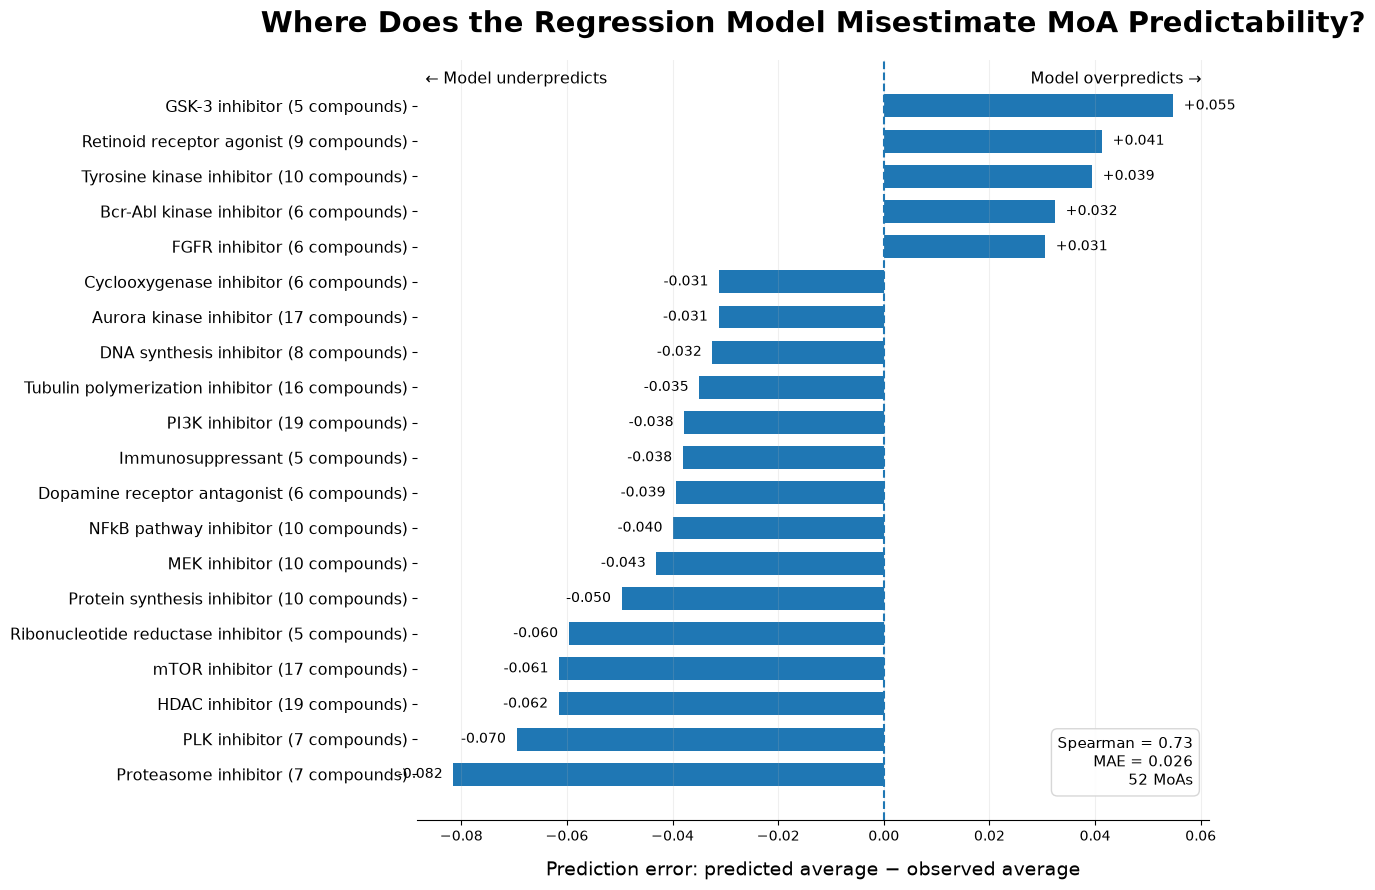


Saved final summary:
/Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/step4_n20_final_average_predictability_by_moa_n5.csv

Saved figure:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_prediction_error_by_moa.png

Saved PDF:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_prediction_error_by_moa.pdf


In [10]:
# Error Plot

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error


# Locate

cwd = Path.cwd()

if (cwd / "data" / "step3_multimodal").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data" / "step3_multimodal").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        f"Could not locate project root from: {cwd}"
    )

OUTPUT_DIR = (
    PROJECT_ROOT
    / "data"
    / "step3_multimodal"
    / "step4_expanded_n20"
)

FIG_DIR = (
    PROJECT_ROOT
    / "figures"
    / "step4_expanded_n20"
)

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# Load 

FULL_MOA_PATH = (
    OUTPUT_DIR
    / "step4_n20_full_clean_compound_moa.csv"
)

if not FULL_MOA_PATH.exists():
    raise FileNotFoundError(
        f"Missing file:\n{FULL_MOA_PATH}"
    )

final_moa_data = pd.read_csv(
    FULL_MOA_PATH
)


required_columns = [
    "compound_embedding_row_index",
    "clean_moa",
    "actual_predictability",
    "predicted_predictability",
]

missing_columns = [
    column
    for column in required_columns
    if column not in final_moa_data.columns
]

if missing_columns:
    raise KeyError(
        f"Missing columns: {missing_columns}\n"
        f"Available columns: {final_moa_data.columns.tolist()}"
    )


# Standardize

moa_replacements = {
    "NFKB pathway inhibitor":
        "NFkB pathway inhibitor",

    "NF-kB pathway inhibitor":
        "NFkB pathway inhibitor",

    "Nfkb pathway inhibitor":
        "NFkB pathway inhibitor",

    "Tubulin inhibitor":
        "Tubulin polymerization inhibitor",

    "MTOR inhibitor":
        "mTOR inhibitor",

    "Mtor inhibitor":
        "mTOR inhibitor",

    "Topoisomerase inhibitor; topoisomerase inhibitor":
        "Topoisomerase inhibitor",

    "Glucocorticoid receptor agonist; glucocorticoid receptor agonist":
        "Glucocorticoid receptor agonist",
}


final_moa_data["final_moa"] = (
    final_moa_data["clean_moa"]
    .replace(moa_replacements)
    .astype(str)
    .str.strip()
)


# Remove duplicate compound–MoA pairs 
final_moa_data = (
    final_moa_data
    .drop_duplicates(
        subset=[
            "compound_embedding_row_index",
            "final_moa",
        ]
    )
    .reset_index(drop=True)
)


# Calculate

MIN_COMPOUNDS = 5

final_moa_summary = (
    final_moa_data
    .groupby("final_moa")
    .agg(
        n_compounds=(
            "compound_embedding_row_index",
            "nunique",
        ),
        observed_mean=(
            "actual_predictability",
            "mean",
        ),
        predicted_mean=(
            "predicted_predictability",
            "mean",
        ),
        observed_median=(
            "actual_predictability",
            "median",
        ),
        predicted_median=(
            "predicted_predictability",
            "median",
        ),
    )
    .reset_index()
)

final_moa_summary = (
    final_moa_summary[
        final_moa_summary["n_compounds"]
        >= MIN_COMPOUNDS
    ]
    .copy()
)


# Negative = regression underpredicts
# Positive = regression overpredicts
final_moa_summary["prediction_error"] = (
    final_moa_summary["predicted_mean"]
    - final_moa_summary["observed_mean"]
)

final_moa_summary["absolute_error"] = (
    final_moa_summary["prediction_error"]
    .abs()
)


# Overall metrics

spearman_r, spearman_p = spearmanr(
    final_moa_summary["observed_mean"],
    final_moa_summary["predicted_mean"],
)

mae = mean_absolute_error(
    final_moa_summary["observed_mean"],
    final_moa_summary["predicted_mean"],
)

mean_bias = (
    final_moa_summary["prediction_error"]
    .mean()
)


print(
    f"MoAs included: {len(final_moa_summary)}"
)

print(
    f"Spearman correlation: {spearman_r:.3f} "
    f"(p={spearman_p:.3g})"
)

print(
    f"Mean absolute error: {mae:.4f}"
)

print(
    f"Mean prediction bias: {mean_bias:.4f}"
)

print(
    "Negative bias means the regression model "
    "underpredicts on average."
)


# Select

N_TO_SHOW = 20

plot_data = (
    final_moa_summary
    .sort_values(
        "absolute_error",
        ascending=False,
    )
    .head(N_TO_SHOW)
    .sort_values(
        "prediction_error",
        ascending=True,
    )
    .reset_index(drop=True)
)


# Create horizontal error plot

fig, ax = plt.subplots(
    figsize=(12.5, 9)
)

y_positions = np.arange(
    len(plot_data)
)

bars = ax.barh(
    y_positions,
    plot_data["prediction_error"],
    height=0.65,
)


ax.axvline(
    0,
    linestyle="--",
    linewidth=1.5,
)


y_labels = [
    (
        f"{moa} "
        f"({int(count)} compounds)"
    )
    for moa, count in zip(
        plot_data["final_moa"],
        plot_data["n_compounds"],
    )
]

ax.set_yticks(
    y_positions
)

ax.set_yticklabels(
    y_labels,
    fontsize=11.5,
)


# Title and axis labels

ax.set_title(
    "Where Does the Regression Model Misestimate MoA Predictability?",
    fontsize=21,
    fontweight="bold",
    pad=20,
)

ax.set_xlabel(
    "Prediction error: predicted average − observed average",
    fontsize=14,
    labelpad=12,
)

ax.text(
    0.01,
    0.985,
    "← Model underpredicts",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=11.5,
)

ax.text(
    0.99,
    0.985,
    "Model overpredicts →",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=11.5,
)


# Add error values to bar ends

for bar, value in zip(
    bars,
    plot_data["prediction_error"],
):
    if value >= 0:
        x_position = value + 0.002
        alignment = "left"
    else:
        x_position = value - 0.002
        alignment = "right"

    ax.text(
        x_position,
        bar.get_y() + bar.get_height() / 2,
        f"{value:+.3f}",
        ha=alignment,
        va="center",
        fontsize=10,
    )


# Metrics box

metrics_text = (
    f"Spearman = {spearman_r:.2f}\n"
    f"MAE = {mae:.3f}\n"
    f"{len(final_moa_summary)} MoAs"
)

ax.text(
    0.98,
    0.04,
    metrics_text,
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=11,
    bbox={
        "boxstyle": "round,pad=0.4",
        "facecolor": "white",
        "alpha": 0.9,
        "edgecolor": "lightgray",
    },
)


# Clean formatting

ax.grid(
    axis="x",
    alpha=0.2,
)

for spine in [
    "top",
    "right",
    "left",
]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()


# Save 

FINAL_SUMMARY_PATH = (
    OUTPUT_DIR
    / "step4_n20_final_average_predictability_by_moa_n5.csv"
)

FIGURE_PATH = (
    FIG_DIR
    / "step4_n20_prediction_error_by_moa.png"
)

PDF_PATH = (
    FIG_DIR
    / "step4_n20_prediction_error_by_moa.pdf"
)

final_moa_summary.to_csv(
    FINAL_SUMMARY_PATH,
    index=False,
)

fig.savefig(
    FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    PDF_PATH,
    bbox_inches="tight",
)

plt.show()


print("\nSaved final summary:")
print(FINAL_SUMMARY_PATH)

print("\nSaved figure:")
print(FIGURE_PATH)

print("\nSaved PDF:")
print(PDF_PATH)

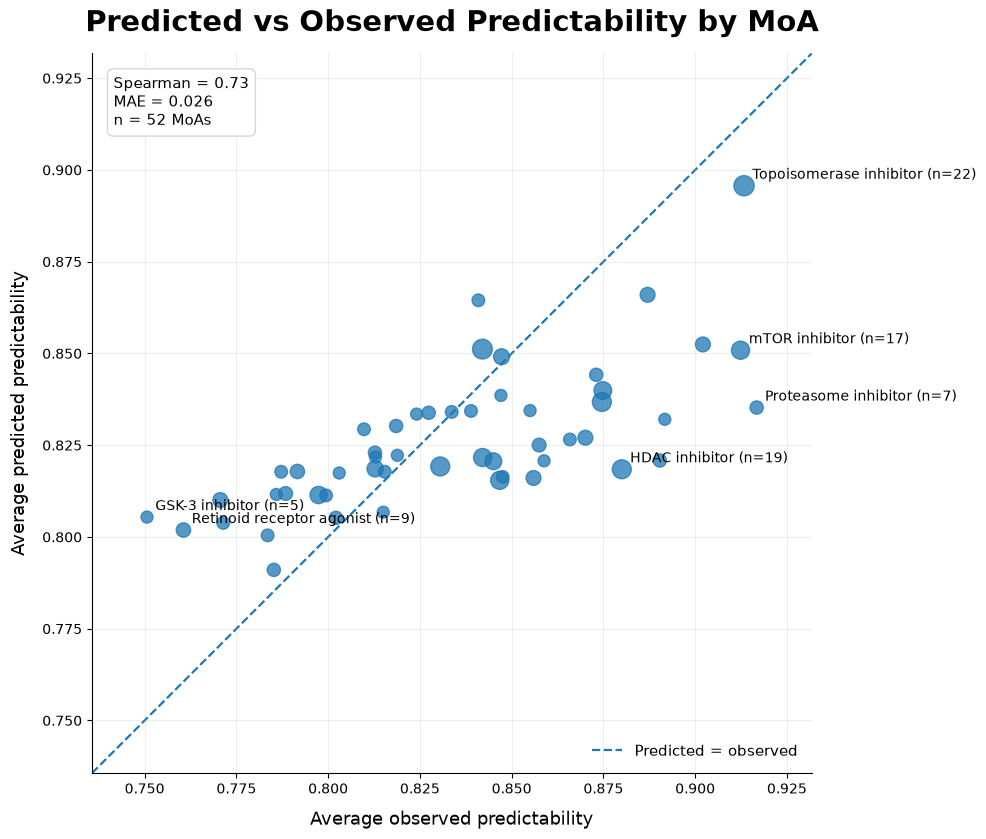


Saved XY figure:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_final_observed_vs_predicted_moa_xy.png

Saved XY PDF:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_final_observed_vs_predicted_moa_xy.pdf


In [11]:
# New XY Plot 

import numpy as np
import matplotlib.pyplot as plt


# Confirm

if "final_moa_summary" not in globals():
    FINAL_SUMMARY_PATH = (
        OUTPUT_DIR
        / "step4_n20_final_average_predictability_by_moa_n5.csv"
    )

    final_moa_summary = pd.read_csv(
        FINAL_SUMMARY_PATH
    )


# Prepare values

xy_data = final_moa_summary.copy()

observed = xy_data[
    "observed_mean"
].to_numpy(dtype=float)

predicted = xy_data[
    "predicted_mean"
].to_numpy(dtype=float)

all_values = np.concatenate(
    [
        observed,
        predicted,
    ]
)

axis_min = all_values.min() - 0.015
axis_max = all_values.max() + 0.015

# Create figure

fig, ax = plt.subplots(
    figsize=(10.5, 8.5)
)

# Size points by number of compounds
point_sizes = (
    35
    + 8 * xy_data["n_compounds"]
)

ax.scatter(
    observed,
    predicted,
    s=point_sizes,
    alpha=0.75,
    zorder=3,
)


# Perfect-agreement line
ax.plot(
    [axis_min, axis_max],
    [axis_min, axis_max],
    linestyle="--",
    linewidth=1.6,
    label="Predicted = observed",
    zorder=1,
)


# Label only selected important MoAs

label_moas = {
    "Topoisomerase inhibitor",
    "mTOR inhibitor",
    "HDAC inhibitor",
    "Proteasome inhibitor",
    "GSK-3 inhibitor",
    "Retinoid receptor agonist",
}

for _, row in xy_data.iterrows():
    if row["final_moa"] not in label_moas:
        continue

    ax.annotate(
        (
            f"{row['final_moa']} "
            f"(n={int(row['n_compounds'])})"
        ),
        (
            row["observed_mean"],
            row["predicted_mean"],
        ),
        xytext=(6, 5),
        textcoords="offset points",
        fontsize=10,
    )


# Metrics box

metrics_text = (
    f"Spearman = {spearman_r:.2f}\n"
    f"MAE = {mae:.3f}\n"
    f"n = {len(xy_data)} MoAs"
)

ax.text(
    0.03,
    0.97,
    metrics_text,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=11,
    bbox={
        "boxstyle": "round,pad=0.4",
        "facecolor": "white",
        "alpha": 0.9,
        "edgecolor": "lightgray",
    },
)


# Labels and formatting

ax.set_title(
    "Predicted vs Observed Predictability by MoA",
    fontsize=21,
    fontweight="bold",
    pad=16,
)

ax.set_xlabel(
    "Average observed predictability",
    fontsize=13,
    labelpad=10,
)

ax.set_ylabel(
    "Average predicted predictability",
    fontsize=13,
    labelpad=10,
)

ax.set_xlim(
    axis_min,
    axis_max,
)

ax.set_ylim(
    axis_min,
    axis_max,
)

ax.set_aspect(
    "equal",
    adjustable="box",
)

ax.grid(
    alpha=0.2,
)

ax.legend(
    frameon=False,
    fontsize=11,
    loc="lower right",
)

for spine in [
    "top",
    "right",
]:
    ax.spines[spine].set_visible(False)

FIG_DIR = (
    PROJECT_ROOT
    / "figures"
    / "step4_expanded_n20"
)

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

fig.tight_layout()


# Save

XY_FIGURE_PATH = (
    FIG_DIR
    / "step4_n20_final_observed_vs_predicted_moa_xy.png"
)

XY_PDF_PATH = (
    FIG_DIR
    / "step4_n20_final_observed_vs_predicted_moa_xy.pdf"
)

fig.savefig(
    XY_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    XY_PDF_PATH,
    bbox_inches="tight",
)

plt.show()

print("\nSaved XY figure:")
print(XY_FIGURE_PATH)

print("\nSaved XY PDF:")
print(XY_PDF_PATH)

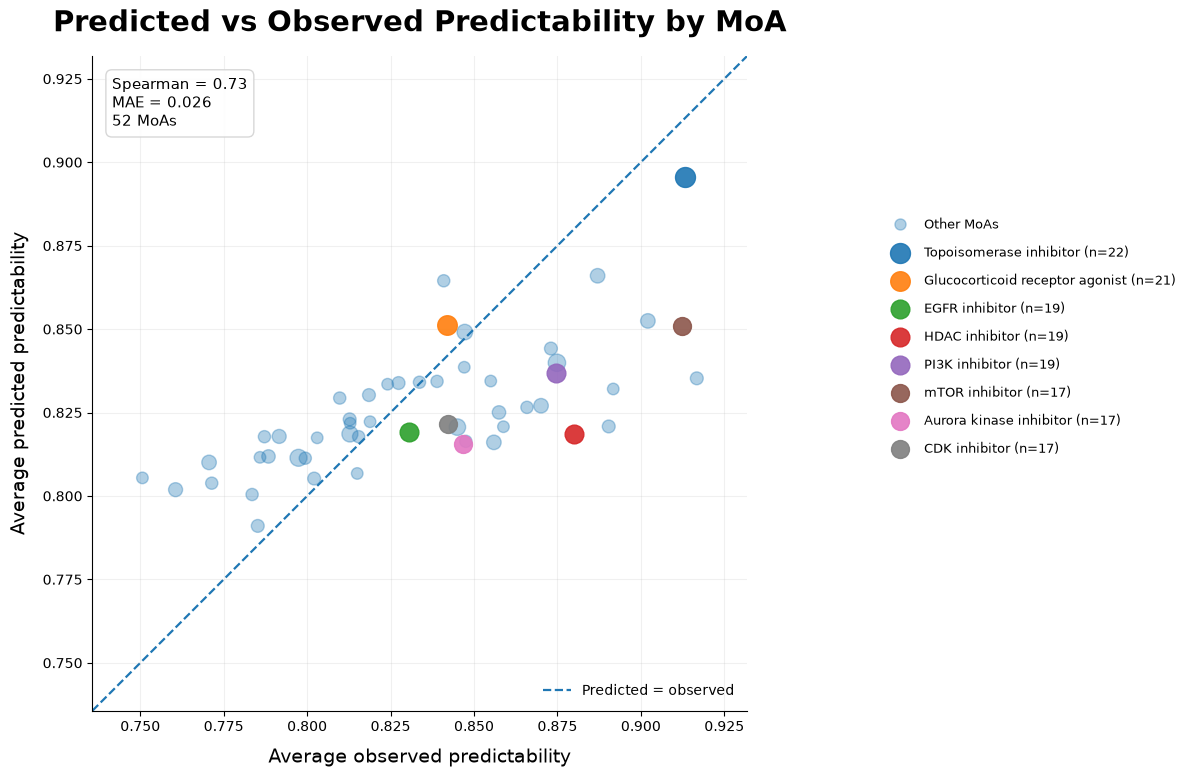


Saved XY figure:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_final_observed_vs_predicted_moa_xy_highlighted.png

Saved XY PDF:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_final_observed_vs_predicted_moa_xy_highlighted.pdf


In [18]:
# XY Again

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error
from matplotlib.lines import Line2D


# Loc

cwd = Path.cwd()

if (cwd / "data" / "step3_multimodal").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data" / "step3_multimodal").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        f"Could not locate project root from: {cwd}"
    )

OUTPUT_DIR = (
    PROJECT_ROOT
    / "data"
    / "step3_multimodal"
    / "step4_expanded_n20"
)

FIG_DIR = (
    PROJECT_ROOT
    / "figures"
    / "step4_expanded_n20"
)

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# Load

SUMMARY_PATH = (
    OUTPUT_DIR
    / "step4_n20_final_average_predictability_by_moa_n5.csv"
)

if not SUMMARY_PATH.exists():
    raise FileNotFoundError(
        f"Missing final MoA summary:\n{SUMMARY_PATH}"
    )

xy_data = pd.read_csv(SUMMARY_PATH)


required_columns = [
    "final_moa",
    "n_compounds",
    "observed_mean",
    "predicted_mean",
    "prediction_error",
    "absolute_error",
]

missing_columns = [
    column
    for column in required_columns
    if column not in xy_data.columns
]

if missing_columns:
    raise KeyError(
        f"Missing columns: {missing_columns}\n"
        f"Available columns: {xy_data.columns.tolist()}"
    )


# Calculate metrics

spearman_r, spearman_p = spearmanr(
    xy_data["observed_mean"],
    xy_data["predicted_mean"],
)

mae = mean_absolute_error(
    xy_data["observed_mean"],
    xy_data["predicted_mean"],
)


# Highlight the 8 MoAs with the most compounds

N_HIGHLIGHT = 8

highlight_moas = (
    xy_data
    .sort_values(
        "n_compounds",
        ascending=False,
    )
    .head(N_HIGHLIGHT)["final_moa"]
    .tolist()
)

highlight_data = (
    xy_data[
        xy_data["final_moa"].isin(highlight_moas)
    ]
    .copy()
)

background_data = (
    xy_data[
        ~xy_data["final_moa"].isin(highlight_moas)
    ]
    .copy()
)


# Prepare axis range

all_values = np.concatenate(
    [
        xy_data["observed_mean"].to_numpy(),
        xy_data["predicted_mean"].to_numpy(),
    ]
)

axis_min = all_values.min() - 0.015
axis_max = all_values.max() + 0.015


# Create figure

fig, ax = plt.subplots(
    figsize=(13.5, 8.5)
)


# Plot all other MoAs in gray

background_sizes = (
    30
    + 8 * background_data["n_compounds"]
)

background_scatter = ax.scatter(
    background_data["observed_mean"],
    background_data["predicted_mean"],
    s=background_sizes,
    alpha=0.35,
    zorder=2,
)


# Plot highlighted MoAs

default_colors = plt.rcParams[
    "axes.prop_cycle"
].by_key()["color"]

highlight_handles = []
highlight_labels = []

for index, moa in enumerate(highlight_moas):
    row = highlight_data[
        highlight_data["final_moa"] == moa
    ].iloc[0]

    point_size = (
        30
        + 8 * row["n_compounds"]
    )

    color = default_colors[
        index % len(default_colors)
    ]

    handle = ax.scatter(
        row["observed_mean"],
        row["predicted_mean"],
        s=point_size,
        color=color,
        alpha=0.9,
        zorder=4,
    )

    highlight_handles.append(handle)

    highlight_labels.append(
        f"{moa} (n={int(row['n_compounds'])})"
    )


# Draw agreement line

ax.plot(
    [axis_min, axis_max],
    [axis_min, axis_max],
    linestyle="--",
    linewidth=1.6,
    zorder=1,
)


# Metrics box

metrics_text = (
    f"Spearman = {spearman_r:.2f}\n"
    f"MAE = {mae:.3f}\n"
    f"{len(xy_data)} MoAs"
)

ax.text(
    0.03,
    0.97,
    metrics_text,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=11,
    bbox={
        "boxstyle": "round,pad=0.4",
        "facecolor": "white",
        "alpha": 0.9,
        "edgecolor": "lightgray",
    },
)


# Titles

ax.set_title(
    "Predicted vs Observed Predictability by MoA",
    fontsize=21,
    fontweight="bold",
    pad=18,
)

ax.set_xlabel(
    "Average observed predictability",
    fontsize=13.5,
    labelpad=10,
)

ax.set_ylabel(
    "Average predicted predictability",
    fontsize=13.5,
    labelpad=10,
)

ax.set_xlim(
    axis_min,
    axis_max,
)

ax.set_ylim(
    axis_min,
    axis_max,
)

ax.set_aspect(
    "equal",
    adjustable="box",
)

ax.grid(
    alpha=0.18,
)

for spine in [
    "top",
    "right",
]:
    ax.spines[spine].set_visible(False)



# MoA Legend 

other_handle = Line2D(
    [0],
    [0],
    marker="o",
    linestyle="none",
    markersize=8,
    alpha=0.35,
)

main_handles = [
    other_handle,
    *highlight_handles,
]

main_labels = [
    "Other MoAs",
    *highlight_labels,
]

fig.legend(
    handles=main_handles,
    labels=main_labels,
    frameon=False,
    fontsize=9.5,
    loc="center left",
    bbox_to_anchor=(0.76, 0.55),
    labelspacing=1.05,
    handletextpad=0.8,
)


# Line key 

agreement_handle = Line2D(
    [0],
    [0],
    linestyle="--",
    linewidth=1.6,
)

ax.legend(
    handles=[agreement_handle],
    labels=["Predicted = observed"],
    loc="lower right",
    frameon=False,
    fontsize=10,
)


# Reserve space
fig.subplots_adjust(
    right=0.72
)



# Save

XY_FIGURE_PATH = (
    FIG_DIR
    / "step4_n20_final_observed_vs_predicted_moa_xy_highlighted.png"
)

XY_PDF_PATH = (
    FIG_DIR
    / "step4_n20_final_observed_vs_predicted_moa_xy_highlighted.pdf"
)

fig.savefig(
    XY_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    XY_PDF_PATH,
    bbox_inches="tight",
)

plt.show()

print("\nSaved XY figure:")
print(XY_FIGURE_PATH)

print("\nSaved XY PDF:")
print(XY_PDF_PATH)

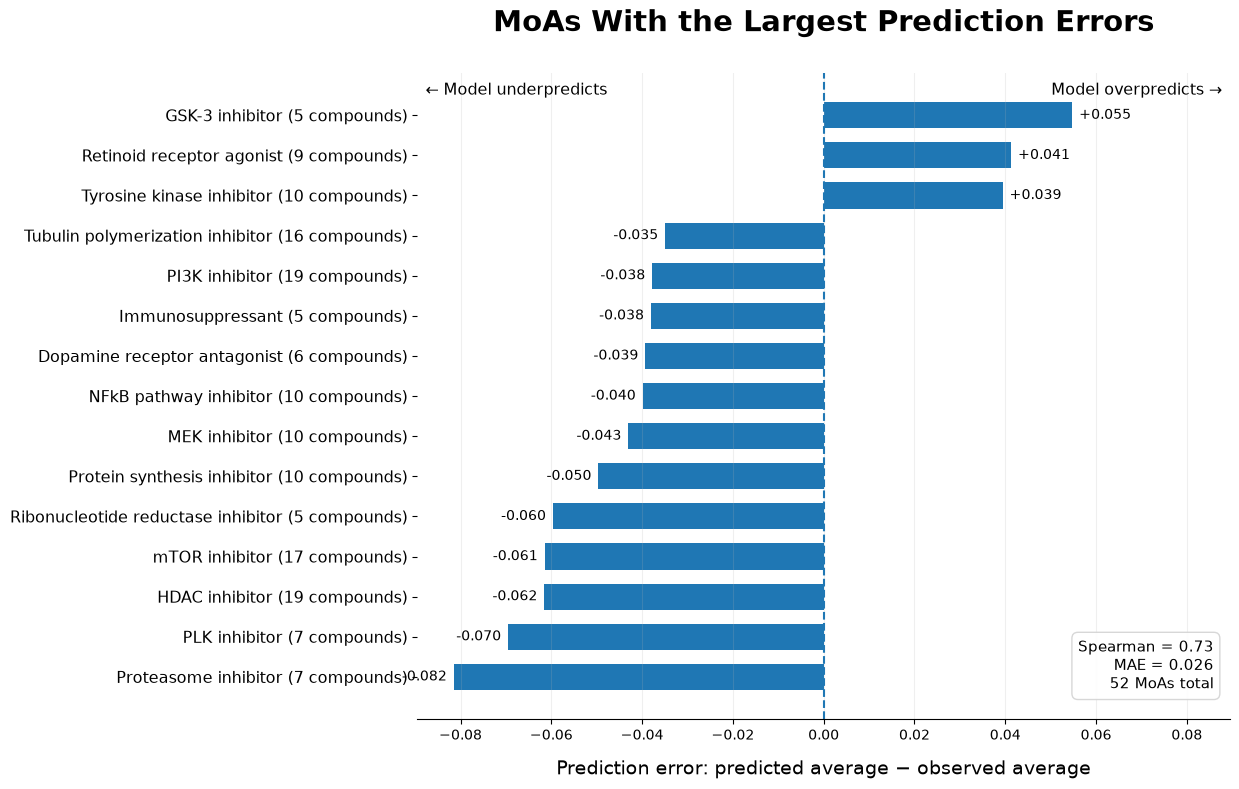

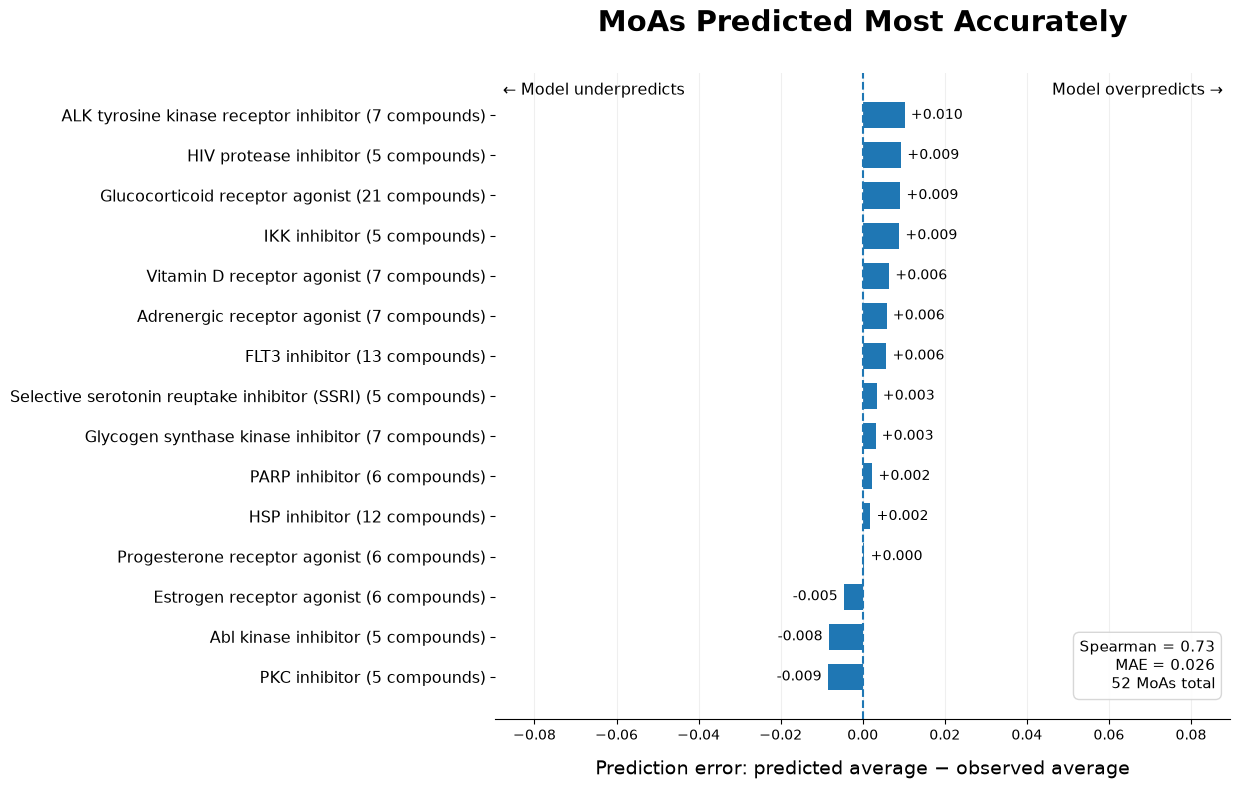


Saved largest-error figure:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_15_largest_prediction_errors_by_moa.png

Saved smallest-error figure:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_15_smallest_prediction_errors_by_moa.png


In [13]:
# Error plot again 

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error


# Loc

cwd = Path.cwd()

if (cwd / "data" / "step3_multimodal").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data" / "step3_multimodal").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        f"Could not locate project root from: {cwd}"
    )

OUTPUT_DIR = (
    PROJECT_ROOT
    / "data"
    / "step3_multimodal"
    / "step4_expanded_n20"
)

FIG_DIR = (
    PROJECT_ROOT
    / "figures"
    / "step4_expanded_n20"
)

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# Load

SUMMARY_PATH = (
    OUTPUT_DIR
    / "step4_n20_final_average_predictability_by_moa_n5.csv"
)

if not SUMMARY_PATH.exists():
    raise FileNotFoundError(
        f"Missing summary:\n{SUMMARY_PATH}"
    )

error_data = pd.read_csv(
    SUMMARY_PATH
)


# Metrics 

spearman_r, spearman_p = spearmanr(
    error_data["observed_mean"],
    error_data["predicted_mean"],
)

mae = mean_absolute_error(
    error_data["observed_mean"],
    error_data["predicted_mean"],
)


# Use 15

N_TO_SHOW = 15

largest_errors = (
    error_data
    .sort_values(
        "absolute_error",
        ascending=False,
    )
    .head(N_TO_SHOW)
    .sort_values(
        "prediction_error",
        ascending=True,
    )
    .reset_index(drop=True)
)

smallest_errors = (
    error_data
    .sort_values(
        "absolute_error",
        ascending=True,
    )
    .head(N_TO_SHOW)
    .sort_values(
        "prediction_error",
        ascending=True,
    )
    .reset_index(drop=True)
)


# Use the same x-axis range for both figures
shared_limit = max(
    largest_errors["absolute_error"].max(),
    smallest_errors["absolute_error"].max(),
) + 0.008



def create_error_plot(
    plot_data,
    title,
    figure_path,
    pdf_path,
    include_metrics=True,
):
    fig, ax = plt.subplots(
        figsize=(12.5, 8)
    )

    y_positions = np.arange(
        len(plot_data)
    )

    bars = ax.barh(
        y_positions,
        plot_data["prediction_error"],
        height=0.65,
    )

    ax.axvline(
        0,
        linestyle="--",
        linewidth=1.5,
    )

    labels = [
        (
            f"{moa} "
            f"({int(count)} compounds)"
        )
        for moa, count in zip(
            plot_data["final_moa"],
            plot_data["n_compounds"],
        )
    ]

    ax.set_yticks(
        y_positions
    )

    ax.set_yticklabels(
        labels,
        fontsize=11.5,
    )

    ax.set_title(
        title,
        fontsize=21,
        fontweight="bold",
        pad=30,
    )

    ax.set_xlabel(
        "Prediction error: predicted average − observed average",
        fontsize=14,
        labelpad=12,
    )


    ax.text(
        0.01,
        0.985,
        "← Model underpredicts",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11.5,
    )

    ax.text(
        0.99,
        0.985,
        "Model overpredicts →",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=11.5,
    )

    for bar, value in zip(
        bars,
        plot_data["prediction_error"],
    ):
        if value >= 0:
            x_position = value + 0.0015
            alignment = "left"
        else:
            x_position = value - 0.0015
            alignment = "right"

        ax.text(
            x_position,
            bar.get_y()
            + bar.get_height() / 2,
            f"{value:+.3f}",
            ha=alignment,
            va="center",
            fontsize=10,
        )

    if include_metrics:
        metrics_text = (
            f"Spearman = {spearman_r:.2f}\n"
            f"MAE = {mae:.3f}\n"
            f"{len(error_data)} MoAs total"
        )

        ax.text(
            0.98,
            0.04,
            metrics_text,
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=11,
            bbox={
                "boxstyle": "round,pad=0.4",
                "facecolor": "white",
                "alpha": 0.9,
                "edgecolor": "lightgray",
            },
        )

    ax.set_xlim(
        -shared_limit,
        shared_limit,
    )

    ax.grid(
        axis="x",
        alpha=0.2,
    )

    for spine in [
        "top",
        "right",
        "left",
    ]:
        ax.spines[spine].set_visible(False)

    fig.tight_layout()

    fig.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight",
    )

    plt.show()


# Figure 1: largest errors

LARGEST_FIGURE_PATH = (
    FIG_DIR
    / "step4_n20_15_largest_prediction_errors_by_moa.png"
)

LARGEST_PDF_PATH = (
    FIG_DIR
    / "step4_n20_15_largest_prediction_errors_by_moa.pdf"
)

create_error_plot(
    plot_data=largest_errors,
    title="MoAs With the Largest Prediction Errors",
    figure_path=LARGEST_FIGURE_PATH,
    pdf_path=LARGEST_PDF_PATH,
)


# Figure 2: smallest errors

SMALLEST_FIGURE_PATH = (
    FIG_DIR
    / "step4_n20_15_smallest_prediction_errors_by_moa.png"
)

SMALLEST_PDF_PATH = (
    FIG_DIR
    / "step4_n20_15_smallest_prediction_errors_by_moa.pdf"
)

create_error_plot(
    plot_data=smallest_errors,
    title="MoAs Predicted Most Accurately",
    figure_path=SMALLEST_FIGURE_PATH,
    pdf_path=SMALLEST_PDF_PATH,
)


print("\nSaved largest-error figure:")
print(LARGEST_FIGURE_PATH)

print("\nSaved smallest-error figure:")
print(SMALLEST_FIGURE_PATH)

Compounds included: 801
Spearman correlation: 0.379 (p=7.81e-29)
Pearson correlation: 0.370 (p=2.37e-27)
R²: 0.136
MAE: 0.0633
RMSE: 0.0828


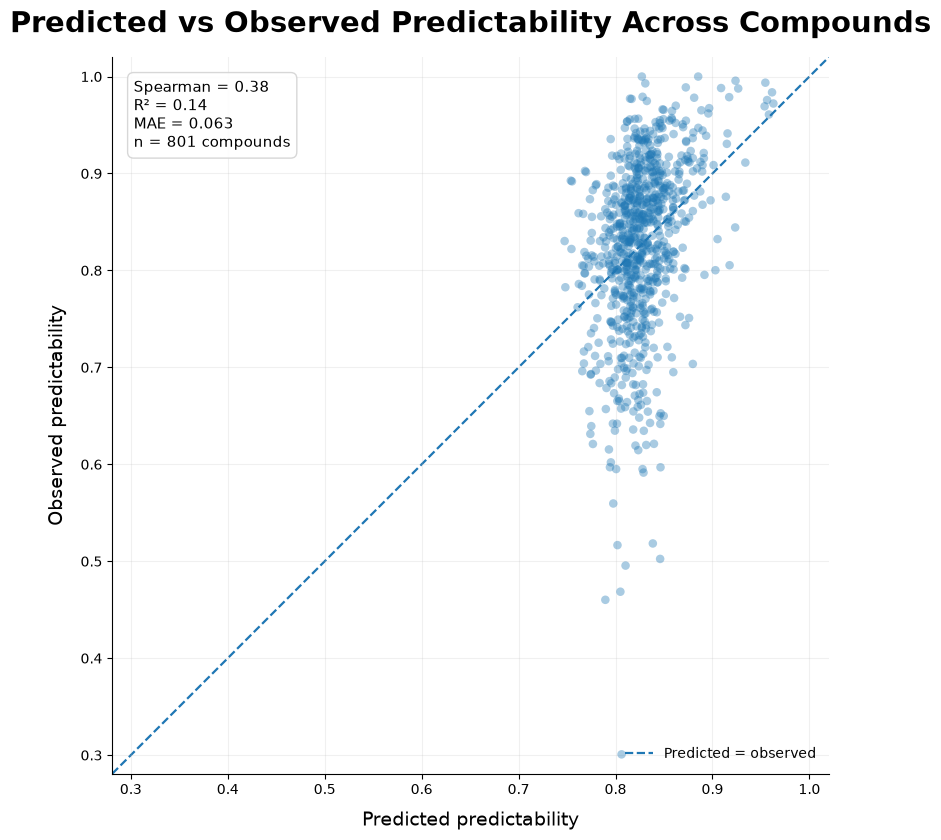


Saved figure:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_compound_level_observed_vs_predicted.png

Saved PDF:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/step4_n20_compound_level_observed_vs_predicted.pdf

Saved data:
/Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/step4_n20_compound_level_observed_vs_predicted.csv


In [19]:
# Prev Plot - Remove Bins 

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)


# Loc

cwd = Path.cwd()

if (cwd / "data" / "step3_multimodal").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data" / "step3_multimodal").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        f"Could not locate project root from: {cwd}"
    )

OUTPUT_DIR = (
    PROJECT_ROOT
    / "data"
    / "step3_multimodal"
    / "step4_expanded_n20"
)

FIG_DIR = (
    PROJECT_ROOT
    / "figures"
    / "step4_expanded_n20"
)

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# Load

PREDICTIONS_PATH = (
    OUTPUT_DIR
    / "step4_extra_trees_n20_oof_predictions_with_groups.csv"
)

if not PREDICTIONS_PATH.exists():
    raise FileNotFoundError(
        f"Missing prediction file:\n{PREDICTIONS_PATH}"
    )

compound_data = pd.read_csv(
    PREDICTIONS_PATH
)


required_columns = [
    "compound_embedding_row_index",
    "actual_predictability",
    "predicted_predictability",
]

missing_columns = [
    column
    for column in required_columns
    if column not in compound_data.columns
]

if missing_columns:
    raise KeyError(
        f"Missing columns: {missing_columns}\n"
        f"Available columns: {compound_data.columns.tolist()}"
    )


compound_data = (
    compound_data[
        required_columns
        + (
            ["compound_name"]
            if "compound_name" in compound_data.columns
            else []
        )
    ]
    .dropna(
        subset=[
            "actual_predictability",
            "predicted_predictability",
        ]
    )
    .drop_duplicates(
        subset="compound_embedding_row_index"
    )
    .copy()
)


# Calc

observed = compound_data[
    "actual_predictability"
].to_numpy(dtype=float)

predicted = compound_data[
    "predicted_predictability"
].to_numpy(dtype=float)


spearman_r, spearman_p = spearmanr(
    observed,
    predicted,
)

pearson_r, pearson_p = pearsonr(
    observed,
    predicted,
)

mae = mean_absolute_error(
    observed,
    predicted,
)

rmse = mean_squared_error(
    observed,
    predicted,
) ** 0.5

r2 = r2_score(
    observed,
    predicted,
)


print(
    f"Compounds included: {len(compound_data)}"
)

print(
    f"Spearman correlation: {spearman_r:.3f} "
    f"(p={spearman_p:.3g})"
)

print(
    f"Pearson correlation: {pearson_r:.3f} "
    f"(p={pearson_p:.3g})"
)

print(
    f"R²: {r2:.3f}"
)

print(
    f"MAE: {mae:.4f}"
)

print(
    f"RMSE: {rmse:.4f}"
)


# Prep

all_values = np.concatenate(
    [
        observed,
        predicted,
    ]
)

axis_min = all_values.min() - 0.02
axis_max = all_values.max() + 0.02


# Plot

fig, ax = plt.subplots(
    figsize=(10.5, 8.5)
)


ax.scatter(
    predicted,
    observed,
    s=38,
    alpha=0.38,
    edgecolors="none",
    zorder=2,
)


# Perfect-prediction diagonal
ax.plot(
    [axis_min, axis_max],
    [axis_min, axis_max],
    linestyle="--",
    linewidth=1.6,
    label="Predicted = observed",
    zorder=1,
)


# Box

metrics_text = (
    f"Spearman = {spearman_r:.2f}\n"
    f"R² = {r2:.2f}\n"
    f"MAE = {mae:.3f}\n"
    f"n = {len(compound_data)} compounds"
)

ax.text(
    0.03,
    0.97,
    metrics_text,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=11,
    bbox={
        "boxstyle": "round,pad=0.4",
        "facecolor": "white",
        "alpha": 0.9,
        "edgecolor": "lightgray",
    },
)


# Titles

ax.set_title(
    "Predicted vs Observed Predictability Across Compounds",
    fontsize=21,
    fontweight="bold",
    pad=18,
)

ax.set_xlabel(
    "Predicted predictability",
    fontsize=13.5,
    labelpad=10,
)

ax.set_ylabel(
    "Observed predictability",
    fontsize=13.5,
    labelpad=10,
)

ax.set_xlim(
    axis_min,
    axis_max,
)

ax.set_ylim(
    axis_min,
    axis_max,
)

ax.set_aspect(
    "equal",
    adjustable="box",
)

ax.grid(
    alpha=0.18,
)

ax.legend(
    frameon=False,
    fontsize=10,
    loc="lower right",
)

for spine in [
    "top",
    "right",
]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()


# Save

FIGURE_PATH = (
    FIG_DIR
    / "step4_n20_compound_level_observed_vs_predicted.png"
)

PDF_PATH = (
    FIG_DIR
    / "step4_n20_compound_level_observed_vs_predicted.pdf"
)

TABLE_PATH = (
    OUTPUT_DIR
    / "step4_n20_compound_level_observed_vs_predicted.csv"
)

compound_data.to_csv(
    TABLE_PATH,
    index=False,
)

fig.savefig(
    FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    PDF_PATH,
    bbox_inches="tight",
)

plt.show()


print("\nSaved figure:")
print(FIGURE_PATH)

print("\nSaved PDF:")
print(PDF_PATH)

print("\nSaved data:")
print(TABLE_PATH)

In [3]:
# Structural Analysis - Step 1 

from pathlib import Path
import re

import numpy as np
import pandas as pd


# Locate

cwd = Path.cwd()

if (cwd / "data" / "step3_multimodal").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data" / "step3_multimodal").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        f"Could not locate project root from: {cwd}"
    )

OUTPUT_DIR = (
    PROJECT_ROOT
    / "data"
    / "step3_multimodal"
    / "step4_expanded_n20"
)

STRUCTURE_OUTPUT_DIR = (
    OUTPUT_DIR
    / "structural_analysis"
)

STRUCTURE_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIG_DIR = (
    PROJECT_ROOT
    / "figures"
    / "step4_expanded_n20"
    / "structural_analysis"
)

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# Load

PREDICTIONS_PATH = (
    OUTPUT_DIR
    / "step4_extra_trees_n20_oof_predictions_with_groups.csv"
)

if not PREDICTIONS_PATH.exists():
    raise FileNotFoundError(
        f"Missing prediction file:\n{PREDICTIONS_PATH}"
    )

predictions = pd.read_csv(
    PREDICTIONS_PATH
)

required_prediction_columns = [
    "compound_embedding_row_index",
    "compound_name",
    "n_profiles",
    "actual_predictability",
    "predicted_predictability",
]

missing_prediction_columns = [
    column
    for column in required_prediction_columns
    if column not in predictions.columns
]

if missing_prediction_columns:
    raise KeyError(
        f"Missing prediction columns: {missing_prediction_columns}\n"
        f"Available columns: {predictions.columns.tolist()}"
    )

predictions = (
    predictions[
        required_prediction_columns
    ]
    .drop_duplicates(
        subset="compound_embedding_row_index"
    )
    .copy()
)


# Load 2

REGISTRY_PATH = (
    PROJECT_ROOT
    / "data"
    / "step1_compound_registry_expanded_clean_fast.csv"
)

if not REGISTRY_PATH.exists():
    raise FileNotFoundError(
        f"Missing structure registry:\n{REGISTRY_PATH}"
    )

registry_columns = [
    "compound_name",
    "smiles",
    "canonical_smiles",
    "inchi_key",
    "pubchem_cid",
    "pert_id",
]

registry = pd.read_csv(
    REGISTRY_PATH,
    usecols=lambda column: column in registry_columns,
    low_memory=False,
)

print("Project root:", PROJECT_ROOT)
print("Regression compounds:", len(predictions))
print("Registry rows:", len(registry))
print("Registry columns:", registry.columns.tolist())

Project root: /Users/mell/predicting-predictability
Regression compounds: 801
Registry rows: 3765890
Registry columns: ['compound_name', 'smiles', 'inchi_key', 'pubchem_cid', 'pert_id', 'canonical_smiles']


In [4]:
# Step 2 

try:
    from rdkit import Chem
except ImportError as error:
    raise ImportError(
        "RDKit is required for the structural analysis.\n"
        "In Terminal, run:\n"
        "conda install -c conda-forge rdkit"
    ) from error


# Normalize names

def normalize_compound_name(value):
    if pd.isna(value):
        return None

    value = str(value).lower().strip()
    value = re.sub(r"[^a-z0-9]+", " ", value)
    value = re.sub(r"\s+", " ", value).strip()

    return value or None


predictions["normalized_compound_name"] = (
    predictions["compound_name"]
    .apply(normalize_compound_name)
)

registry["normalized_compound_name"] = (
    registry["compound_name"]
    .apply(normalize_compound_name)
)


# Choose the best available raw SMILES 

if "canonical_smiles" in registry.columns:
    registry["raw_smiles"] = registry["canonical_smiles"]
else:
    registry["raw_smiles"] = np.nan

if "smiles" in registry.columns:
    registry["raw_smiles"] = (
        registry["raw_smiles"]
        .fillna(registry["smiles"])
    )


registry_structures = (
    registry[
        [
            "normalized_compound_name",
            "compound_name",
            "raw_smiles",
        ]
    ]
    .dropna(
        subset=[
            "normalized_compound_name",
            "raw_smiles",
        ]
    )
    .copy()
)


# Clean each structure
# Keep the largest fragment to reduce salts/counterions

def clean_smiles(smiles):
    if pd.isna(smiles):
        return None

    smiles = str(smiles).strip()

    if not smiles:
        return None

    try:
        molecule = Chem.MolFromSmiles(smiles)

        if molecule is None:
            return None

        fragments = Chem.GetMolFrags(
            molecule,
            asMols=True,
            sanitizeFrags=True,
        )

        if not fragments:
            return None

        largest_fragment = max(
            fragments,
            key=lambda fragment: fragment.GetNumHeavyAtoms(),
        )

        return Chem.MolToSmiles(
            largest_fragment,
            canonical=True,
            isomericSmiles=True,
        )

    except Exception:
        return None


registry_structures["clean_smiles"] = (
    registry_structures["raw_smiles"]
    .apply(clean_smiles)
)

registry_structures = (
    registry_structures
    .dropna(
        subset=["clean_smiles"]
    )
    .drop_duplicates(
        subset=[
            "normalized_compound_name",
            "clean_smiles",
        ]
    )
)


# Find names that map to multiple different structures

structure_counts_by_name = (
    registry_structures
    .groupby("normalized_compound_name")[
        "clean_smiles"
    ]
    .nunique()
    .rename("n_unique_structures")
    .reset_index()
)

ambiguous_names = structure_counts_by_name[
    structure_counts_by_name["n_unique_structures"] > 1
].copy()

# For each name, choose the most frequently listed structure

structure_frequency = (
    registry_structures
    .groupby(
        [
            "normalized_compound_name",
            "clean_smiles",
        ]
    )
    .size()
    .rename("registry_frequency")
    .reset_index()
)

best_structure_per_name = (
    structure_frequency
    .sort_values(
        [
            "normalized_compound_name",
            "registry_frequency",
            "clean_smiles",
        ],
        ascending=[
            True,
            False,
            True,
        ],
    )
    .drop_duplicates(
        subset="normalized_compound_name",
        keep="first",
    )
)


# Merge structures

structure_data = (
    predictions
    .merge(
        best_structure_per_name,
        on="normalized_compound_name",
        how="left",
    )
    .merge(
        structure_counts_by_name,
        on="normalized_compound_name",
        how="left",
    )
)

structure_data["has_valid_structure"] = (
    structure_data["clean_smiles"]
    .notna()
)

structure_data["structure_name_is_ambiguous"] = (
    structure_data["n_unique_structures"]
    .fillna(0)
    .gt(1)
)


# Audit

n_total = len(structure_data)

n_valid = int(
    structure_data["has_valid_structure"]
    .sum()
)

n_missing = n_total - n_valid

n_ambiguous = int(
    structure_data[
        "structure_name_is_ambiguous"
    ].sum()
)

n_unique_structures = (
    structure_data["clean_smiles"]
    .dropna()
    .nunique()
)

print("Structure matching summary")
print("==========================")
print("Regression compounds:", n_total)
print("Compounds with valid structures:", n_valid)
print(
    "Structure coverage:",
    f"{100 * n_valid / n_total:.1f}%",
)
print("Compounds without valid structures:", n_missing)
print("Compounds with ambiguous name matches:", n_ambiguous)
print("Unique cleaned structures:", n_unique_structures)


# Save

FULL_STRUCTURE_PATH = (
    STRUCTURE_OUTPUT_DIR
    / "step4_n20_compound_structure_match_audit.csv"
)

VALID_STRUCTURE_PATH = (
    STRUCTURE_OUTPUT_DIR
    / "step4_n20_compounds_with_valid_structures.csv"
)

structure_data.to_csv(
    FULL_STRUCTURE_PATH,
    index=False,
)

valid_structure_data = (
    structure_data[
        structure_data["has_valid_structure"]
    ]
    .copy()
)

valid_structure_data.to_csv(
    VALID_STRUCTURE_PATH,
    index=False,
)

print("\nSaved full audit:")
print(FULL_STRUCTURE_PATH)

print("\nSaved valid structure table:")
print(VALID_STRUCTURE_PATH)

display(
    structure_data[
        [
            "compound_name",
            "actual_predictability",
            "predicted_predictability",
            "clean_smiles",
            "n_unique_structures",
            "has_valid_structure",
        ]
    ]
    .head(20)
)

[00:13:23] WARNING: not removing hydrogen atom without neighbors
[00:14:11] WARNING: not removing hydrogen atom without neighbors
[00:14:11] WARNING: not removing hydrogen atom without neighbors
[00:17:26] WARNING: not removing hydrogen atom without neighbors
[00:18:08] WARNING: not removing hydrogen atom without neighbors
[00:18:13] WARNING: not removing hydrogen atom without neighbors
[00:18:16] WARNING: not removing hydrogen atom without neighbors
[00:19:21] WARNING: not removing hydrogen atom without neighbors
[00:19:21] WARNING: not removing hydrogen atom without neighbors
[00:19:21] WARNING: not removing hydrogen atom without neighbors
[00:19:45] WARNING: not removing hydrogen atom without neighbors
[00:19:45] WARNING: not removing hydrogen atom without neighbors
[00:19:45] WARNING: not removing hydrogen atom without neighbors
[00:19:45] WARNING: not removing hydrogen atom without neighbors


Structure matching summary
Regression compounds: 801
Compounds with valid structures: 801
Structure coverage: 100.0%
Compounds without valid structures: 0
Compounds with ambiguous name matches: 35
Unique cleaned structures: 786

Saved full audit:
/Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/structural_analysis/step4_n20_compound_structure_match_audit.csv

Saved valid structure table:
/Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/structural_analysis/step4_n20_compounds_with_valid_structures.csv


,compound_name,actual_predictability,predicted_predictability,clean_smiles,n_unique_structures,has_valid_structure
0,Doxorubicin (hydrochloride); Doxorubicin Hydro...,0.969265,0.953787,COc1cccc2c1C(=O)c1c(O)c3c(c(O)c1C2=O)CC(O)(C(=...,1,True
1,Idarubicin (hydrochloride); Idarubicin Hydroch...,0.960813,0.958234,CC(=O)C1(O)Cc2c(O)c3c(c(O)c2C(OC2CC(N)C(O)C(C)...,1,True
2,Doxycycline (monohydrate); Invertin,0.946269,0.845221,CC1c2cccc(O)c2C(O)=C2C(=O)C3(O)C(O)=C(C(N)=O)C...,1,True
3,Docetaxel (Trihydrate); Docetaxel Trihydrate,0.942327,0.880282,CC(=O)OC12COC1CC(O)C1(C)C(=O)C(O)C3=C(C)C(OC(=...,1,True
4,Temuterkib,0.940575,0.838711,Cn1nccc1Nc1nccc(-c2cc3c(s2)C(C)(C)N(CCN2CCOCC2...,1,True
5,Silodosin,0.942513,0.830471,CC(Cc1cc2c(c(C(N)=O)c1)N(CCCO)CC2)NCCOc1ccccc1...,1,True
6,Erdafitinib,0.935477,0.795010,COc1cc(OC)cc(N(CCNC(C)C)c2ccc3ncc(-c4cnn(C)c4)...,1,True
7,Mitoxantrone (dihydrochloride); Mitoxantrone H...,0.923218,0.877534,O=C1c2c(O)ccc(O)c2C(=O)c2c(NCCNCCO)ccc(NCCNCCO...,1,True
8,Simotinib,0.916930,0.831032,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCN1CC2(CC2...,1,True
9,Bimiralisib,0.916127,0.842866,Nc1cc(C(F)(F)F)c(-c2nc(N3CCOCC3)nc(N3CCOCC3)n2...,1,True


In [5]:
# Step 3 - Extract Scaffolds 

from rdkit.Chem.Scaffolds import MurckoScaffold


if "valid_structure_data" not in globals():
    VALID_STRUCTURE_PATH = (
        STRUCTURE_OUTPUT_DIR
        / "step4_n20_compounds_with_valid_structures.csv"
    )

    valid_structure_data = pd.read_csv(
        VALID_STRUCTURE_PATH
    )


# Extract one scaffold per compound

def extract_murcko_scaffold(smiles):
    if pd.isna(smiles):
        return None

    try:
        molecule = Chem.MolFromSmiles(
            str(smiles)
        )

        if molecule is None:
            return None

        scaffold = MurckoScaffold.GetScaffoldForMol(
            molecule
        )

        if scaffold is None:
            return None

        if scaffold.GetNumAtoms() == 0:
            return None

        return Chem.MolToSmiles(
            scaffold,
            canonical=True,
            isomericSmiles=False,
        )

    except Exception:
        return None


scaffold_data = valid_structure_data.copy()

scaffold_data["murcko_scaffold"] = (
    scaffold_data["clean_smiles"]
    .apply(extract_murcko_scaffold)
)

scaffold_data["has_murcko_scaffold"] = (
    scaffold_data["murcko_scaffold"]
    .notna()
)


# Scaffold counts

scaffold_counts = (
    scaffold_data[
        scaffold_data["has_murcko_scaffold"]
    ]
    .groupby("murcko_scaffold")[
        "compound_embedding_row_index"
    ]
    .nunique()
    .sort_values(ascending=False)
    .rename("n_compounds")
    .reset_index()
)


print("Murcko scaffold summary")
print("=======================")

print(
    "Compounds with a Murcko scaffold:",
    scaffold_data[
        "has_murcko_scaffold"
    ].sum(),
)

print(
    "Unique Murcko scaffolds:",
    scaffold_counts["murcko_scaffold"]
    .nunique(),
)

print("\nScaffolds available at each minimum size")
print("========================================")

for threshold in [2, 3, 5, 10, 15, 20]:
    n_scaffolds = (
        scaffold_counts["n_compounds"]
        >= threshold
    ).sum()

    print(
        f"n ≥ {threshold}: {n_scaffolds} scaffolds"
    )


# Save scaffold tables

SCAFFOLD_DATA_PATH = (
    STRUCTURE_OUTPUT_DIR
    / "step4_n20_compounds_with_murcko_scaffolds.csv"
)

SCAFFOLD_COUNTS_PATH = (
    STRUCTURE_OUTPUT_DIR
    / "step4_n20_murcko_scaffold_counts.csv"
)

scaffold_data.to_csv(
    SCAFFOLD_DATA_PATH,
    index=False,
)

scaffold_counts.to_csv(
    SCAFFOLD_COUNTS_PATH,
    index=False,
)


display(
    scaffold_counts.head(40)
)

print("\nSaved compound-scaffold table:")
print(SCAFFOLD_DATA_PATH)

print("\nSaved scaffold counts:")
print(SCAFFOLD_COUNTS_PATH)

Murcko scaffold summary
Compounds with a Murcko scaffold: 785
Unique Murcko scaffolds: 634

Scaffolds available at each minimum size
n ≥ 2: 74 scaffolds
n ≥ 3: 23 scaffolds
n ≥ 5: 6 scaffolds
n ≥ 10: 2 scaffolds
n ≥ 15: 1 scaffolds
n ≥ 20: 1 scaffolds


,murcko_scaffold,n_compounds
0,c1ccccc1,32
1,O=C1C=CC2C(=C1)CCC1C3CCCC3CCC21,14
2,O=C1c2ccccc2C(=O)c2cc3c(cc21)CCCC3OC1CCCCO1,7
3,O=C1C=C2CCC3C4CCCC4CCC3C2CC1,6
4,c1ncc2ncn(C3CCCO3)c2n1,5
5,C=C1CCCCC1=CC=C1CCCC2CCCC12,5
6,O=c1ncccn1C1CCCO1,4
7,O=c1ccn(C2CCCO2)c(=O)[nH]1,4
8,O=C1Cc2cc3n(c(=O)c2CO1)Cc1cc2ccccc2nc1-3,4
9,O=C1C=CC2C(=C1)CCC1C2CCC2C1CC1OCOC12,3



Saved compound-scaffold table:
/Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/structural_analysis/step4_n20_compounds_with_murcko_scaffolds.csv

Saved scaffold counts:
/Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/structural_analysis/step4_n20_murcko_scaffold_counts.csv


In [6]:
# Step 4 - Averages 

MIN_SCAFFOLD_COMPOUNDS = 3


scaffold_summary = (
    scaffold_data[
        scaffold_data["has_murcko_scaffold"]
    ]
    .groupby("murcko_scaffold")
    .agg(
        n_compounds=(
            "compound_embedding_row_index",
            "nunique",
        ),
        observed_mean=(
            "actual_predictability",
            "mean",
        ),
        observed_median=(
            "actual_predictability",
            "median",
        ),
        observed_std=(
            "actual_predictability",
            "std",
        ),
        predicted_mean=(
            "predicted_predictability",
            "mean",
        ),
        predicted_median=(
            "predicted_predictability",
            "median",
        ),
    )
    .reset_index()
)


scaffold_summary["prediction_error"] = (
    scaffold_summary["predicted_mean"]
    - scaffold_summary["observed_mean"]
)

scaffold_summary["absolute_error"] = (
    scaffold_summary["prediction_error"]
    .abs()
)


eligible_scaffold_summary = (
    scaffold_summary[
        scaffold_summary["n_compounds"]
        >= MIN_SCAFFOLD_COMPOUNDS
    ]
    .sort_values(
        "observed_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)


print(
    "Eligible scaffolds:",
    len(eligible_scaffold_summary),
)

print(
    "Minimum compounds per scaffold:",
    MIN_SCAFFOLD_COMPOUNDS,
)


SCAFFOLD_SUMMARY_PATH = (
    STRUCTURE_OUTPUT_DIR
    / "step4_n20_murcko_scaffold_predictability_n3.csv"
)

eligible_scaffold_summary.to_csv(
    SCAFFOLD_SUMMARY_PATH,
    index=False,
)


display(
    eligible_scaffold_summary.head(30)
)

print("\nSaved scaffold predictability summary:")
print(SCAFFOLD_SUMMARY_PATH)

Eligible scaffolds: 23
Minimum compounds per scaffold: 3


,murcko_scaffold,n_compounds,observed_mean,observed_median,observed_std,predicted_mean,predicted_median,prediction_error,absolute_error
0,O=C1C=C2CCCCCCC=CCCC=CC=CC(=O)NC(=C1)C2=O,3,0.987370,0.987674,0.008478,0.922532,0.923778,-0.064838,0.064838
1,O=C1c2ccccc2C(=O)c2cc3c(cc21)CCCC3OC1CCCCO1,7,0.967313,0.972176,0.025039,0.948340,0.956359,-0.018973,0.018973
2,O=C1Cc2cc3n(c(=O)c2CO1)Cc1cc2ccccc2nc1-3,4,0.950655,0.951620,0.032510,0.913529,0.912224,-0.037127,0.037127
3,c1ccc(-c2ccc3c(N4CCOCC4)nc(N4CCOCC4)nc3n2)cc1,3,0.943061,0.954936,0.021223,0.857290,0.858229,-0.085772,0.085772
4,O=C(CCc1ccccc1)OC1C=C2CC(=O)C3CCC4OCC4C3C(OC(=...,3,0.911374,0.915839,0.033411,0.891281,0.880282,-0.020092,0.020092
5,O=C1CCC=CCC(=O)CC(CCC2CCCCC2)OC(=O)C2CCCCN2C(=...,3,0.894337,0.902035,0.019364,0.892389,0.889777,-0.001948,0.001948
6,c1ccc2c(c1)CCC1C2CCC2CCCC21,3,0.894020,0.907057,0.036320,0.843986,0.842550,-0.050034,0.050034
7,c1ccc2[nH]cnc2c1,3,0.891026,0.902636,0.034626,0.801648,0.814955,-0.089378,0.089378
8,O=c1ncccn1C1CCCO1,4,0.886106,0.879084,0.040510,0.851698,0.850859,-0.034408,0.034408
9,O=C1C=CC2C(=O)C3=Cc4ccccc4CC3CC2C1,3,0.883004,0.902519,0.074953,0.865284,0.847601,-0.017720,0.017720



Saved scaffold predictability summary:
/Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/structural_analysis/step4_n20_murcko_scaffold_predictability_n3.csv


In [7]:
# Another audit 

AMBIGUOUS_PATH = (
    STRUCTURE_OUTPUT_DIR
    / "step4_n20_ambiguous_structure_matches.csv"
)

ambiguous_compounds = (
    structure_data[
        structure_data["structure_name_is_ambiguous"]
    ]
    .copy()
    .sort_values(
        "actual_predictability",
        ascending=False,
    )
)

print(
    "Ambiguous compounds:",
    len(ambiguous_compounds),
)

display(
    ambiguous_compounds[
        [
            "compound_name",
            "actual_predictability",
            "predicted_predictability",
            "n_unique_structures",
            "clean_smiles",
        ]
    ]
)

ambiguous_compounds.to_csv(
    AMBIGUOUS_PATH,
    index=False,
)

print("\nSaved ambiguity audit:")
print(AMBIGUOUS_PATH)

Ambiguous compounds: 35


,compound_name,actual_predictability,predicted_predictability,n_unique_structures,clean_smiles
281,emetine,0.965197,0.888537,2,CC[C@H]1CN2CCc3cc(OC)c(OC)cc3C2C[C@@H]1CC1NCCc...
292,NVP-AUY922,0.952999,0.841292,2,CCNC(=O)C1=C(c2ccc(CN3CCOCC3)cc2)C(=C2C=C(C(C)...
205,verteporfin,0.947792,0.869760,2,C=Cc1c(C)c2cc3nc(cc4[nH]c(cc5nc(cc1[nH]2)C(C)=...
33,Erythromycin,0.911467,0.866774,2,CCC1OC(=O)C(C)C(OC2CC(C)(OC)C(O)C(C)O2)C(C)C(O...
19,Hesperidin,0.909233,0.852465,2,COc1ccc(C2CC(=O)c3c(O)cc(OC4OC(COC5OC(C)C(O)C(...
277,Tofacitinib,0.906078,0.819766,2,CC1CCN(C(=O)CC#N)CC1N(C)c1ncnc2[nH]ccc12
366,thiostrepton,0.904925,0.823758,2,C=C(NC(=O)C(=C)NC(=O)c1csc(C2=NC3c4csc(n4)C4NC...
29,Demeclocycline,0.902519,0.847601,3,CN(C)C1C(=O)C(C(N)=O)=C(O)C2(O)C(=O)C3=C(O)c4c...
20,Rifaximin,0.889460,0.873710,3,COC1C=COC2(C)Oc3c(C)c(O)c4c(O)c(c5c(nc6cc(C)cc...
174,Artesunate,0.887369,0.851524,4,CC1CCC2C(C)C(OC(=O)CCC(=O)O)OC3OC4(C)CCC1C32OO4



Saved ambiguity audit:
/Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/structural_analysis/step4_n20_ambiguous_structure_matches.csv


Scaffolds included: 23
Spearman: 0.708 (p=0.000155)
Pearson: 0.808 (p=3.05e-06)
R²: 0.521
MAE: 0.0281

Highlighted scaffolds:


,scaffold_id,n_compounds,observed_mean,predicted_mean,prediction_error
0,Scaffold A,32,0.791077,0.792065,0.000987
1,Scaffold B,14,0.845841,0.855204,0.009363
2,Scaffold C,7,0.967313,0.948340,-0.018973
3,Scaffold D,6,0.860529,0.829528,-0.031001
4,Scaffold E,5,0.819291,0.834437,0.015146
5,Scaffold F,5,0.809487,0.816447,0.006960


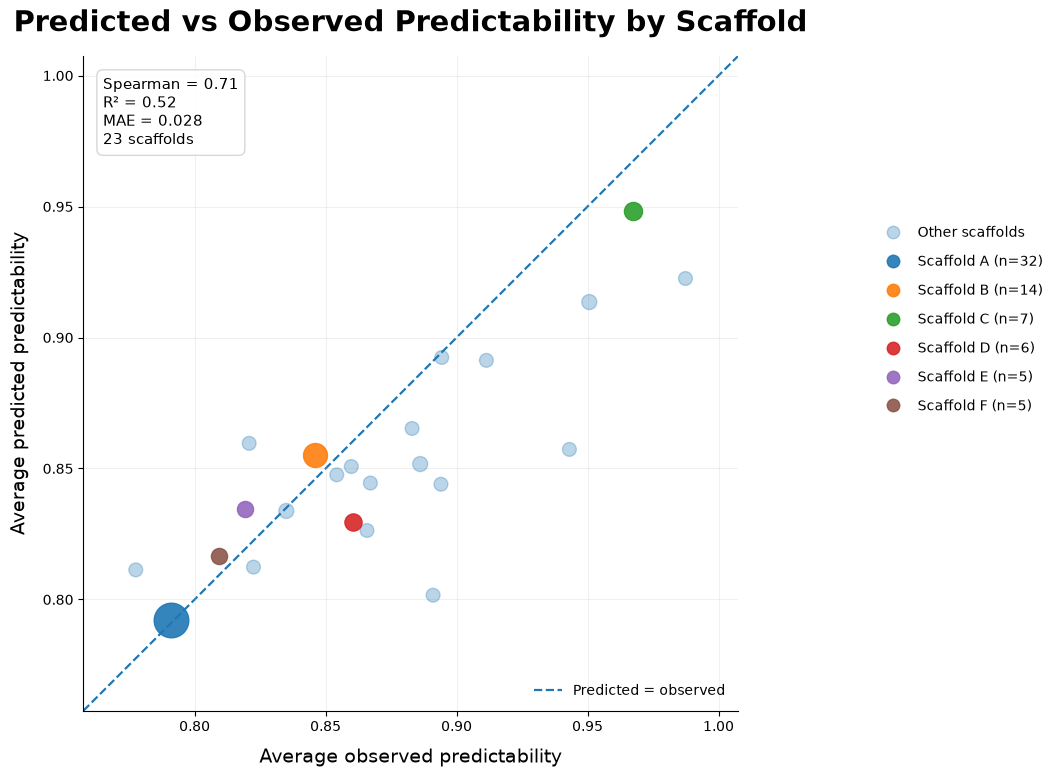


Saved scaffold XY figure:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/structural_analysis/step4_n20_scaffold_observed_vs_predicted_n3_highlighted.png

Saved scaffold XY PDF:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/structural_analysis/step4_n20_scaffold_observed_vs_predicted_n3_highlighted.pdf

Saved scaffold ID mapping:
/Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/structural_analysis/step4_n20_highlighted_scaffold_id_mapping.csv


In [14]:
# Observed v Predicted Predictability by Scaffold 


from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
)
from matplotlib.lines import Line2D


# Loc

cwd = Path.cwd()

if (cwd / "data" / "step3_multimodal").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data" / "step3_multimodal").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        f"Could not locate project root from: {cwd}"
    )

STRUCTURE_OUTPUT_DIR = (
    PROJECT_ROOT
    / "data"
    / "step3_multimodal"
    / "step4_expanded_n20"
    / "structural_analysis"
)

FIG_DIR = (
    PROJECT_ROOT
    / "figures"
    / "step4_expanded_n20"
    / "structural_analysis"
)

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# Load

SCAFFOLD_SUMMARY_PATH = (
    STRUCTURE_OUTPUT_DIR
    / "step4_n20_murcko_scaffold_predictability_n3.csv"
)

if not SCAFFOLD_SUMMARY_PATH.exists():
    raise FileNotFoundError(
        f"Missing scaffold summary:\n{SCAFFOLD_SUMMARY_PATH}"
    )

scaffold_plot_data = pd.read_csv(
    SCAFFOLD_SUMMARY_PATH
)


required_columns = [
    "murcko_scaffold",
    "n_compounds",
    "observed_mean",
    "predicted_mean",
    "prediction_error",
    "absolute_error",
]

missing_columns = [
    column
    for column in required_columns
    if column not in scaffold_plot_data.columns
]

if missing_columns:
    raise KeyError(
        f"Missing columns: {missing_columns}\n"
        f"Available columns: {scaffold_plot_data.columns.tolist()}"
    )


# Calculate 

scaffold_spearman, scaffold_spearman_p = spearmanr(
    scaffold_plot_data["observed_mean"],
    scaffold_plot_data["predicted_mean"],
)

scaffold_pearson, scaffold_pearson_p = pearsonr(
    scaffold_plot_data["observed_mean"],
    scaffold_plot_data["predicted_mean"],
)

scaffold_mae = mean_absolute_error(
    scaffold_plot_data["observed_mean"],
    scaffold_plot_data["predicted_mean"],
)

scaffold_r2 = r2_score(
    scaffold_plot_data["observed_mean"],
    scaffold_plot_data["predicted_mean"],
)


print(
    f"Scaffolds included: {len(scaffold_plot_data)}"
)

print(
    f"Spearman: {scaffold_spearman:.3f} "
    f"(p={scaffold_spearman_p:.3g})"
)

print(
    f"Pearson: {scaffold_pearson:.3f} "
    f"(p={scaffold_pearson_p:.3g})"
)

print(
    f"R²: {scaffold_r2:.3f}"
)

print(
    f"MAE: {scaffold_mae:.4f}"
)


# Highlight the 6 scaffolds with the most compounds

N_HIGHLIGHT = 6

highlight_data = (
    scaffold_plot_data
    .sort_values(
        [
            "n_compounds",
            "observed_mean",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .head(N_HIGHLIGHT)
    .copy()
    .reset_index(drop=True)
)

background_data = (
    scaffold_plot_data[
        ~scaffold_plot_data[
            "murcko_scaffold"
        ].isin(
            highlight_data[
                "murcko_scaffold"
            ]
        )
    ]
    .copy()
)


# Short IDs
scaffold_letters = [
    chr(ord("A") + index)
    for index in range(
        len(highlight_data)
    )
]

highlight_data["scaffold_id"] = [
    f"Scaffold {letter}"
    for letter in scaffold_letters
]


# Save 
SCAFFOLD_ID_PATH = (
    STRUCTURE_OUTPUT_DIR
    / "step4_n20_highlighted_scaffold_id_mapping.csv"
)

highlight_data[
    [
        "scaffold_id",
        "murcko_scaffold",
        "n_compounds",
        "observed_mean",
        "predicted_mean",
        "prediction_error",
        "absolute_error",
    ]
].to_csv(
    SCAFFOLD_ID_PATH,
    index=False,
)


print("\nHighlighted scaffolds:")
display(
    highlight_data[
        [
            "scaffold_id",
            "n_compounds",
            "observed_mean",
            "predicted_mean",
            "prediction_error",
        ]
    ]
)

# Prep axis

all_values = np.concatenate(
    [
        scaffold_plot_data[
            "observed_mean"
        ].to_numpy(),
        scaffold_plot_data[
            "predicted_mean"
        ].to_numpy(),
    ]
)

axis_min = all_values.min() - 0.02
axis_max = all_values.max() + 0.02

# Create figure

fig, ax = plt.subplots(
    figsize=(13.5, 8.5)
)


# Plot background scaffolds

background_sizes = (
    45
    + 18 * background_data[
        "n_compounds"
    ]
)

ax.scatter(
    background_data["observed_mean"],
    background_data["predicted_mean"],
    s=background_sizes,
    alpha=0.30,
    zorder=2,
)

# Plot

default_colors = plt.rcParams[
    "axes.prop_cycle"
].by_key()["color"]

highlight_handles = []
highlight_labels = []


for index, row in highlight_data.iterrows():
    point_size = (
        45
        + 18 * row["n_compounds"]
    )

    color = default_colors[
        index % len(default_colors)
    ]

    handle = ax.scatter(
        row["observed_mean"],
        row["predicted_mean"],
        s=point_size,
        color=color,
        alpha=0.90,
        zorder=4,
    )

    highlight_handles.append(
        handle
    )

    highlight_labels.append(
        (
            f"{row['scaffold_id']} "
            f"(n={int(row['n_compounds'])})"
        )
    )


# Perfect-agreement line

ax.plot(
    [
        axis_min,
        axis_max,
    ],
    [
        axis_min,
        axis_max,
    ],
    linestyle="--",
    linewidth=1.6,
    zorder=1,
)


# Metrics box

metrics_text = (
    f"Spearman = {scaffold_spearman:.2f}\n"
    f"R² = {scaffold_r2:.2f}\n"
    f"MAE = {scaffold_mae:.3f}\n"
    f"{len(scaffold_plot_data)} scaffolds"
)

ax.text(
    0.03,
    0.97,
    metrics_text,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=11,
    bbox={
        "boxstyle": "round,pad=0.4",
        "facecolor": "white",
        "alpha": 0.9,
        "edgecolor": "lightgray",
    },
)


# Titles and axes

ax.set_title(
    "Predicted vs Observed Predictability by Scaffold",
    fontsize=21,
    fontweight="bold",
    pad=18,
)

ax.set_xlabel(
    "Average observed predictability",
    fontsize=13.5,
    labelpad=10,
)

ax.set_ylabel(
    "Average predicted predictability",
    fontsize=13.5,
    labelpad=10,
)

ax.set_xlim(
    axis_min,
    axis_max,
)

ax.set_ylim(
    axis_min,
    axis_max,
)

ax.set_aspect(
    "equal",
    adjustable="box",
)

ax.grid(
    alpha=0.18,
)

for spine in [
    "top",
    "right",
]:
    ax.spines[spine].set_visible(
        False
    )


# Legend

legend_marker_size = 9

other_handle = Line2D(
    [0],
    [0],
    marker="o",
    linestyle="none",
    markersize=legend_marker_size,
    alpha=0.30,
)

highlight_legend_handles = []

for index in range(len(highlight_data)):
    color = default_colors[
        index % len(default_colors)
    ]

    highlight_legend_handles.append(
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="none",
            markersize=legend_marker_size,
            markerfacecolor=color,
            markeredgecolor=color,
            alpha=0.90,
        )
    )

main_handles = [
    other_handle,
    *highlight_legend_handles,
]

main_labels = [
    "Other scaffolds",
    *highlight_labels,
]

fig.legend(
    handles=main_handles,
    labels=main_labels,
    frameon=False,
    fontsize=10,
    loc="center left",
    bbox_to_anchor=(
        0.76,
        0.57,
    ),
    labelspacing=1.05,
    handletextpad=0.8,
)


# Agreement-line key 

agreement_handle = Line2D(
    [0],
    [0],
    linestyle="--",
    linewidth=1.6,
)

ax.legend(
    handles=[
        agreement_handle
    ],
    labels=[
        "Predicted = observed"
    ],
    loc="lower right",
    frameon=False,
    fontsize=10,
)


# Room for legend 
fig.subplots_adjust(
    right=0.72
)


# Save 

SCAFFOLD_XY_PATH = (
    FIG_DIR
    / "step4_n20_scaffold_observed_vs_predicted_n3_highlighted.png"
)

SCAFFOLD_XY_PDF_PATH = (
    FIG_DIR
    / "step4_n20_scaffold_observed_vs_predicted_n3_highlighted.pdf"
)

fig.savefig(
    SCAFFOLD_XY_PATH,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    SCAFFOLD_XY_PDF_PATH,
    bbox_inches="tight",
)

plt.show()


print("\nSaved scaffold XY figure:")
print(SCAFFOLD_XY_PATH)

print("\nSaved scaffold XY PDF:")
print(SCAFFOLD_XY_PDF_PATH)

print("\nSaved scaffold ID mapping:")
print(SCAFFOLD_ID_PATH)

In [9]:
# Most and least predictable scaffolds

N_SHOW = 6

highest_predictability_scaffolds = (
    scaffold_plot_data
    .sort_values(
        "observed_mean",
        ascending=False,
    )
    .head(N_SHOW)
    .copy()
)

lowest_predictability_scaffolds = (
    scaffold_plot_data
    .sort_values(
        "observed_mean",
        ascending=True,
    )
    .head(N_SHOW)
    .copy()
)

highest_predictability_scaffolds[
    "scaffold_group"
] = "Highest observed predictability"

lowest_predictability_scaffolds[
    "scaffold_group"
] = "Lowest observed predictability"

extreme_scaffolds = pd.concat(
    [
        highest_predictability_scaffolds,
        lowest_predictability_scaffolds,
    ],
    ignore_index=True,
)

EXTREME_SCAFFOLD_PATH = (
    STRUCTURE_OUTPUT_DIR
    / "step4_n20_highest_and_lowest_predictability_scaffolds_n3.csv"
)

extreme_scaffolds.to_csv(
    EXTREME_SCAFFOLD_PATH,
    index=False,
)

print("Highest observed predictability scaffolds")
display(
    highest_predictability_scaffolds[
        [
            "murcko_scaffold",
            "n_compounds",
            "observed_mean",
            "predicted_mean",
            "prediction_error",
        ]
    ]
)

print("\nLowest observed predictability scaffolds")
display(
    lowest_predictability_scaffolds[
        [
            "murcko_scaffold",
            "n_compounds",
            "observed_mean",
            "predicted_mean",
            "prediction_error",
        ]
    ]
)

print("\nSaved extreme scaffold table:")
print(EXTREME_SCAFFOLD_PATH)

Highest observed predictability scaffolds


,murcko_scaffold,n_compounds,observed_mean,predicted_mean,prediction_error
0,O=C1C=C2CCCCCCC=CCCC=CC=CC(=O)NC(=C1)C2=O,3,0.987370,0.922532,-0.064838
1,O=C1c2ccccc2C(=O)c2cc3c(cc21)CCCC3OC1CCCCO1,7,0.967313,0.948340,-0.018973
2,O=C1Cc2cc3n(c(=O)c2CO1)Cc1cc2ccccc2nc1-3,4,0.950655,0.913529,-0.037127
3,c1ccc(-c2ccc3c(N4CCOCC4)nc(N4CCOCC4)nc3n2)cc1,3,0.943061,0.857290,-0.085772
4,O=C(CCc1ccccc1)OC1C=C2CC(=O)C3CCC4OCC4C3C(OC(=...,3,0.911374,0.891281,-0.020092
5,O=C1CCC=CCC(=O)CC(CCC2CCCCC2)OC(=O)C2CCCCN2C(=...,3,0.894337,0.892389,-0.001948



Lowest observed predictability scaffolds


,murcko_scaffold,n_compounds,observed_mean,predicted_mean,prediction_error
22,O=C(NCCc1ccccc1)C(Nc1ccccc1)c1cccs1,3,0.777523,0.811299,0.033775
21,c1ccccc1,32,0.791077,0.792065,0.000987
20,c1ncc2ncn(C3CCCO3)c2n1,5,0.809487,0.816447,0.006960
19,C=C1CCCCC1=CC=C1CCCC2CCCC12,5,0.819291,0.834437,0.015146
18,O=C1CCOC2CCC3CCCCC3C12,3,0.820807,0.859600,0.038792
17,c1ccc(Nc2ncnc3ccccc23)cc1,3,0.822473,0.812364,-0.010109



Saved extreme scaffold table:
/Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/structural_analysis/step4_n20_highest_and_lowest_predictability_scaffolds_n3.csv


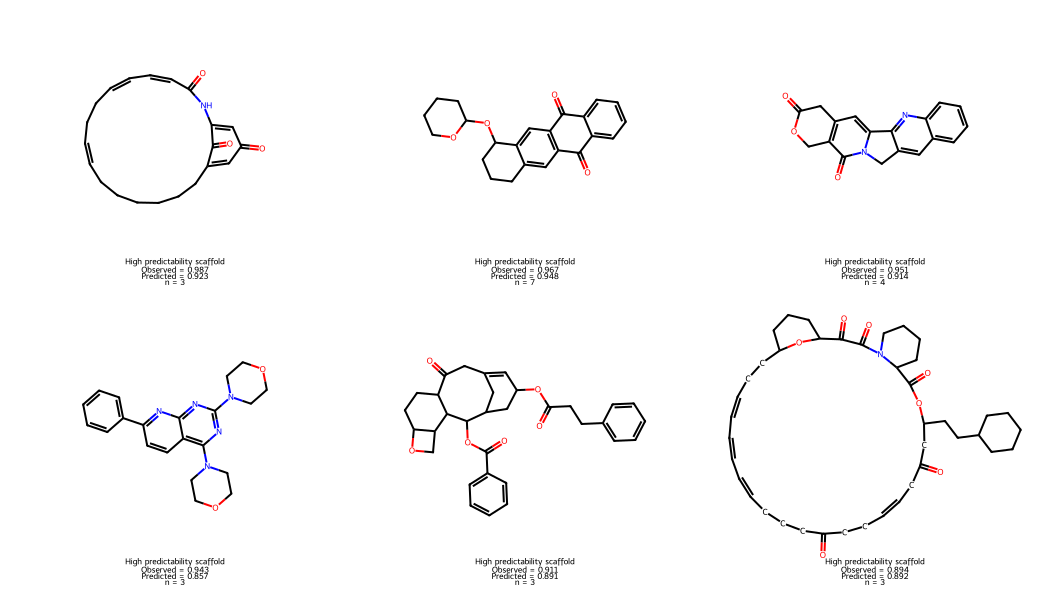

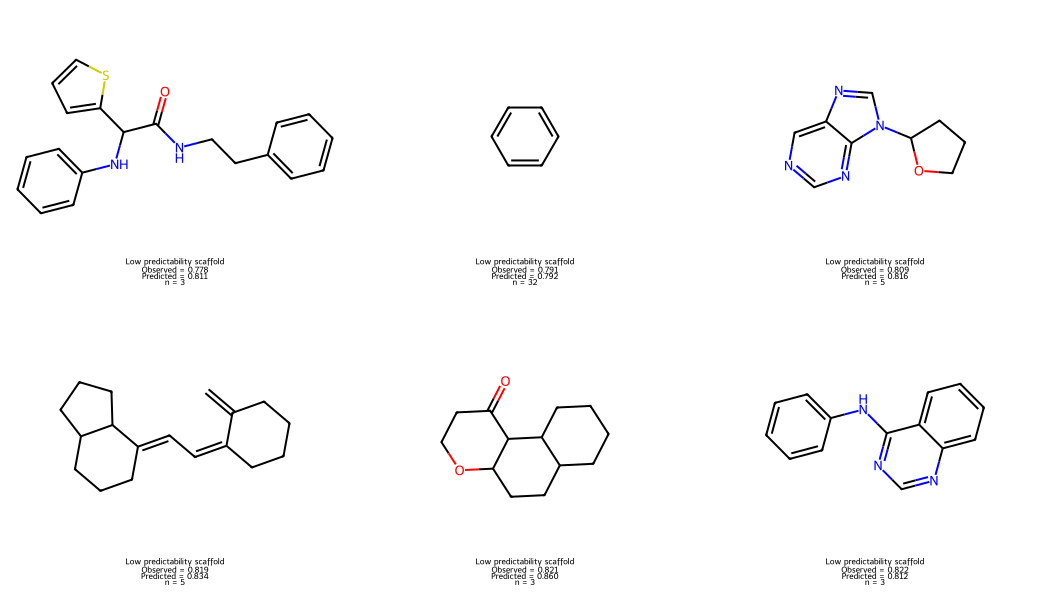


Saved high-predictability scaffold figure:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/structural_analysis/step4_n20_highest_predictability_scaffolds_n3.png

Saved low-predictability scaffold figure:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/structural_analysis/step4_n20_lowest_predictability_scaffolds_n3.png


In [12]:
# Make most and least predictable scaffolds

import io

from PIL import Image
from rdkit import Chem
from rdkit.Chem import Draw


def create_scaffold_grid(
    scaffold_table,
    title_prefix,
    output_path,
):
    molecules = []
    legends = []

    for _, row in scaffold_table.iterrows():
        molecule = Chem.MolFromSmiles(
            row["murcko_scaffold"]
        )

        if molecule is None:
            continue

        molecules.append(molecule)

        legends.append(
            (
                f"{title_prefix}\n"
                f"Observed = {row['observed_mean']:.3f}\n"
                f"Predicted = {row['predicted_mean']:.3f}\n"
                f"n = {int(row['n_compounds'])}"
            )
        )

    if not molecules:
        raise ValueError(
            "No valid scaffold molecules were available to render."
        )

    grid_image = Draw.MolsToGridImage(
        molecules,
        legends=legends,
        molsPerRow=3,
        subImgSize=(350, 300),
        useSVG=False,
    )

    # Convert if nec
    if isinstance(grid_image, Image.Image):
        pil_image = grid_image

    elif hasattr(grid_image, "data"):
        pil_image = Image.open(
            io.BytesIO(grid_image.data)
        )

    else:
        pil_image = Image.open(
            io.BytesIO(grid_image)
        )

    pil_image.save(
        output_path
    )

    return pil_image


# Output paths

HIGH_SCAFFOLD_FIGURE_PATH = (
    FIG_DIR
    / "step4_n20_highest_predictability_scaffolds_n3.png"
)

LOW_SCAFFOLD_FIGURE_PATH = (
    FIG_DIR
    / "step4_n20_lowest_predictability_scaffolds_n3.png"
)


# Create and save 

high_grid = create_scaffold_grid(
    highest_predictability_scaffolds,
    "High predictability scaffold",
    HIGH_SCAFFOLD_FIGURE_PATH,
)

low_grid = create_scaffold_grid(
    lowest_predictability_scaffolds,
    "Low predictability scaffold",
    LOW_SCAFFOLD_FIGURE_PATH,
)


# Display result

display(high_grid)
display(low_grid)


print("\nSaved high-predictability scaffold figure:")
print(HIGH_SCAFFOLD_FIGURE_PATH)

print("\nSaved low-predictability scaffold figure:")
print(LOW_SCAFFOLD_FIGURE_PATH)

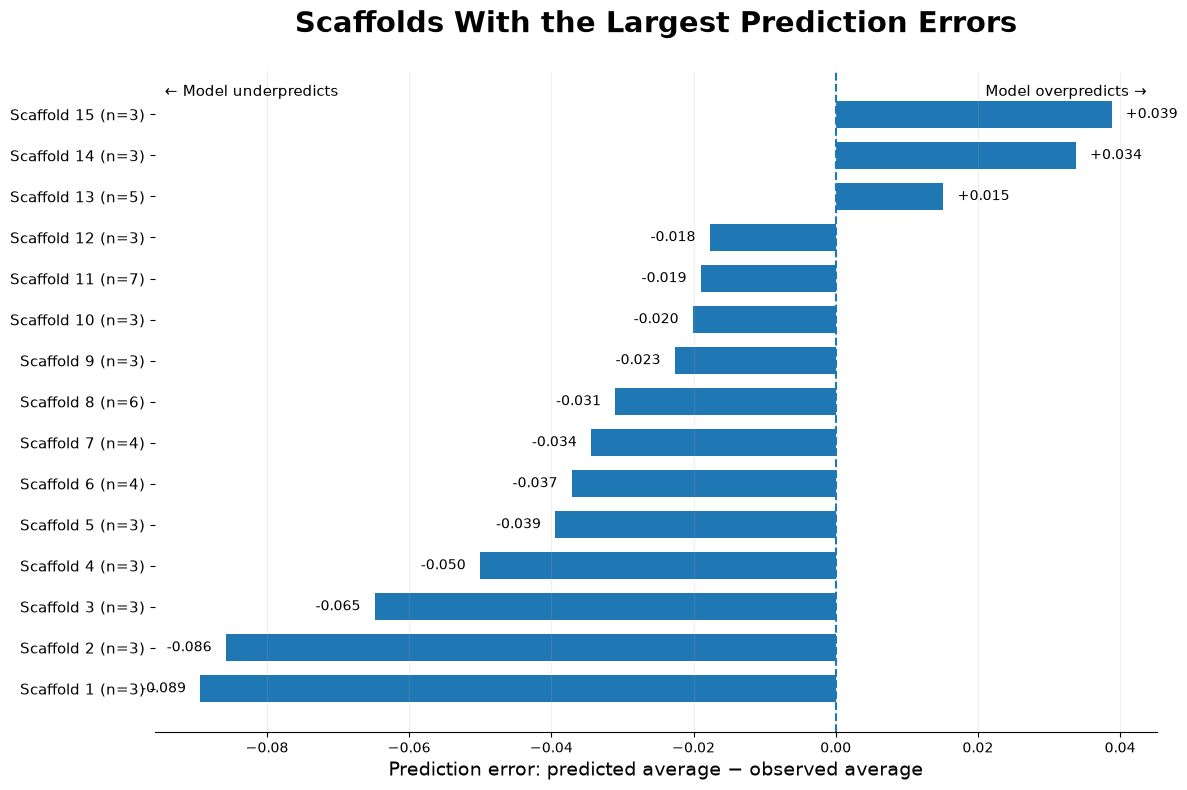


Saved scaffold error figure:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/structural_analysis/step4_n20_scaffold_largest_prediction_errors_n3.png


In [15]:
# Prediction Error by Scaffold 

N_ERROR_SCAFFOLDS = 15

scaffold_error_data = (
    scaffold_plot_data
    .sort_values(
        "absolute_error",
        ascending=False,
    )
    .head(N_ERROR_SCAFFOLDS)
    .sort_values(
        "prediction_error",
        ascending=True,
    )
    .reset_index(drop=True)
)


fig, ax = plt.subplots(
    figsize=(12, 8)
)

y_positions = np.arange(
    len(scaffold_error_data)
)

bars = ax.barh(
    y_positions,
    scaffold_error_data["prediction_error"],
    height=0.65,
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1.5,
)

labels = [
    f"Scaffold {index + 1} (n={int(row['n_compounds'])})"
    for index, row in scaffold_error_data.iterrows()
]

ax.set_yticks(
    y_positions
)

ax.set_yticklabels(
    labels,
    fontsize=11,
)

ax.set_title(
    "Scaffolds With the Largest Prediction Errors",
    fontsize=21,
    fontweight="bold",
    pad=28,
)

ax.set_xlabel(
    "Prediction error: predicted average − observed average",
    fontsize=13.5,
)

ax.text(
    0.01,
    0.98,
    "← Model underpredicts",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=11,
)

ax.text(
    0.99,
    0.98,
    "Model overpredicts →",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=11,
)

for bar, value in zip(
    bars,
    scaffold_error_data["prediction_error"],
):
    if value >= 0:
        text_x = value + 0.002
        alignment = "left"
    else:
        text_x = value - 0.002
        alignment = "right"

    ax.text(
        text_x,
        bar.get_y() + bar.get_height() / 2,
        f"{value:+.3f}",
        ha=alignment,
        va="center",
        fontsize=10,
    )

ax.grid(
    axis="x",
    alpha=0.2,
)

for spine in [
    "top",
    "right",
    "left",
]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()


SCAFFOLD_ERROR_PATH = (
    FIG_DIR
    / "step4_n20_scaffold_largest_prediction_errors_n3.png"
)

SCAFFOLD_ERROR_PDF_PATH = (
    FIG_DIR
    / "step4_n20_scaffold_largest_prediction_errors_n3.pdf"
)

fig.savefig(
    SCAFFOLD_ERROR_PATH,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    SCAFFOLD_ERROR_PDF_PATH,
    bbox_inches="tight",
)

plt.show()

print("\nSaved scaffold error figure:")
print(SCAFFOLD_ERROR_PATH)

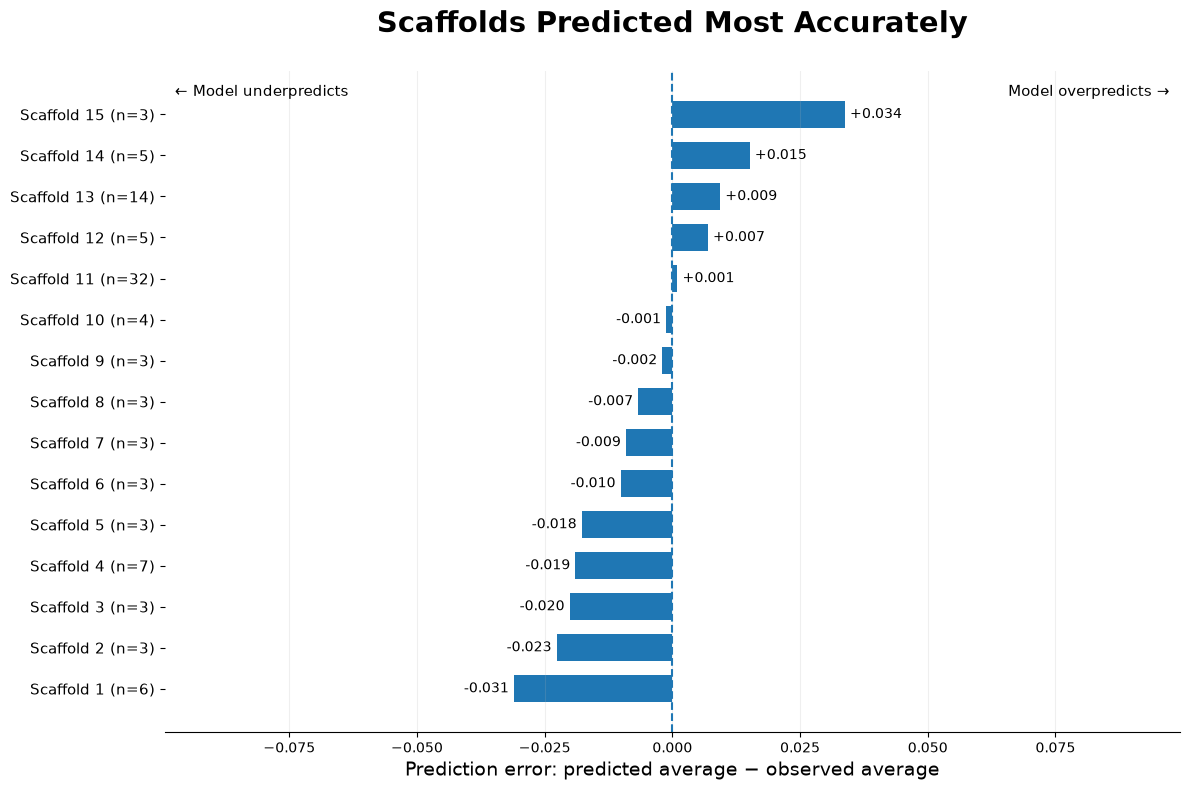


Saved smallest-error scaffold figure:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/structural_analysis/step4_n20_scaffold_smallest_prediction_errors_n3.png

Saved smallest-error scaffold PDF:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/structural_analysis/step4_n20_scaffold_smallest_prediction_errors_n3.pdf

Saved smallest-error scaffold table:
/Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/structural_analysis/step4_n20_scaffold_smallest_prediction_errors_n3.csv


In [16]:
# Vers 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Load summary

if "scaffold_plot_data" not in globals():
    SCAFFOLD_SUMMARY_PATH = (
        STRUCTURE_OUTPUT_DIR
        / "step4_n20_murcko_scaffold_predictability_n3.csv"
    )

    scaffold_plot_data = pd.read_csv(
        SCAFFOLD_SUMMARY_PATH
    )


# Select the 15 smallest absolute errors

N_ERROR_SCAFFOLDS = 15

smallest_scaffold_errors = (
    scaffold_plot_data
    .sort_values(
        "absolute_error",
        ascending=True,
    )
    .head(N_ERROR_SCAFFOLDS)
    .sort_values(
        "prediction_error",
        ascending=True,
    )
    .reset_index(drop=True)
)


# Create 

fig, ax = plt.subplots(
    figsize=(12, 8)
)

y_positions = np.arange(
    len(smallest_scaffold_errors)
)

bars = ax.barh(
    y_positions,
    smallest_scaffold_errors["prediction_error"],
    height=0.65,
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1.5,
)


# Labels

labels = [
    (
        f"Scaffold {index + 1} "
        f"(n={int(row['n_compounds'])})"
    )
    for index, row in smallest_scaffold_errors.iterrows()
]

ax.set_yticks(
    y_positions
)

ax.set_yticklabels(
    labels,
    fontsize=11,
)


# Title and axis

ax.set_title(
    "Scaffolds Predicted Most Accurately",
    fontsize=21,
    fontweight="bold",
    pad=28,
)

ax.set_xlabel(
    "Prediction error: predicted average − observed average",
    fontsize=13.5,
)


# Direction labels

ax.text(
    0.01,
    0.98,
    "← Model underpredicts",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=11,
)

ax.text(
    0.99,
    0.98,
    "Model overpredicts →",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=11,
)


# Add error values to bars

for bar, value in zip(
    bars,
    smallest_scaffold_errors["prediction_error"],
):
    if value >= 0:
        text_x = value + 0.001
        alignment = "left"
    else:
        text_x = value - 0.001
        alignment = "right"

    ax.text(
        text_x,
        bar.get_y() + bar.get_height() / 2,
        f"{value:+.3f}",
        ha=alignment,
        va="center",
        fontsize=10,
    )


# x-axis scale 

shared_limit = (
    scaffold_plot_data["absolute_error"]
    .nlargest(15)
    .max()
    + 0.01
)

ax.set_xlim(
    -shared_limit,
    shared_limit,
)


# Formatting

ax.grid(
    axis="x",
    alpha=0.2,
)

for spine in [
    "top",
    "right",
    "left",
]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()


# Save outputs

SMALLEST_SCAFFOLD_ERROR_PATH = (
    FIG_DIR
    / "step4_n20_scaffold_smallest_prediction_errors_n3.png"
)

SMALLEST_SCAFFOLD_ERROR_PDF_PATH = (
    FIG_DIR
    / "step4_n20_scaffold_smallest_prediction_errors_n3.pdf"
)

SMALLEST_SCAFFOLD_ERROR_TABLE_PATH = (
    STRUCTURE_OUTPUT_DIR
    / "step4_n20_scaffold_smallest_prediction_errors_n3.csv"
)

smallest_scaffold_errors.to_csv(
    SMALLEST_SCAFFOLD_ERROR_TABLE_PATH,
    index=False,
)

fig.savefig(
    SMALLEST_SCAFFOLD_ERROR_PATH,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    SMALLEST_SCAFFOLD_ERROR_PDF_PATH,
    bbox_inches="tight",
)

plt.show()


print("\nSaved smallest-error scaffold figure:")
print(SMALLEST_SCAFFOLD_ERROR_PATH)

print("\nSaved smallest-error scaffold PDF:")
print(SMALLEST_SCAFFOLD_ERROR_PDF_PATH)

print("\nSaved smallest-error scaffold table:")
print(SMALLEST_SCAFFOLD_ERROR_TABLE_PATH)

In [17]:
# Scaffold IDs

from pathlib import Path

import numpy as np
import pandas as pd

# Loc

cwd = Path.cwd()

if (cwd / "data" / "step3_multimodal").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data" / "step3_multimodal").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        f"Could not locate project root from: {cwd}"
    )

STRUCTURE_OUTPUT_DIR = (
    PROJECT_ROOT
    / "data"
    / "step3_multimodal"
    / "step4_expanded_n20"
    / "structural_analysis"
)

FIG_DIR = (
    PROJECT_ROOT
    / "figures"
    / "step4_expanded_n20"
    / "structural_analysis"
)

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# Load 

SCAFFOLD_SUMMARY_PATH = (
    STRUCTURE_OUTPUT_DIR
    / "step4_n20_murcko_scaffold_predictability_n3.csv"
)

if not SCAFFOLD_SUMMARY_PATH.exists():
    raise FileNotFoundError(
        f"Missing scaffold summary:\n{SCAFFOLD_SUMMARY_PATH}"
    )

scaffold_summary_with_ids = pd.read_csv(
    SCAFFOLD_SUMMARY_PATH
)


# Assign IDs

scaffold_summary_with_ids = (
    scaffold_summary_with_ids
    .sort_values(
        [
            "n_compounds",
            "observed_mean",
            "murcko_scaffold",
        ],
        ascending=[
            False,
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)


def index_to_letters(index):
    """
    Convert 0, 1, ..., 25, 26... to A, B, ..., Z, AA...
    """
    result = ""
    index += 1

    while index > 0:
        index, remainder = divmod(
            index - 1,
            26,
        )

        result = (
            chr(65 + remainder)
            + result
        )

    return result


scaffold_summary_with_ids["scaffold_id"] = [
    f"Scaffold {index_to_letters(index)}"
    for index in range(
        len(scaffold_summary_with_ids)
    )
]


column_order = [
    "scaffold_id",
    "murcko_scaffold",
    "n_compounds",
    "observed_mean",
    "observed_median",
    "observed_std",
    "predicted_mean",
    "predicted_median",
    "prediction_error",
    "absolute_error",
]

column_order = [
    column
    for column in column_order
    if column in scaffold_summary_with_ids.columns
]

scaffold_summary_with_ids = (
    scaffold_summary_with_ids[
        column_order
    ]
)


# Save 

PERMANENT_MAPPING_PATH = (
    STRUCTURE_OUTPUT_DIR
    / "step4_n20_permanent_scaffold_id_mapping_n3.csv"
)

scaffold_summary_with_ids.to_csv(
    PERMANENT_MAPPING_PATH,
    index=False,
)


print(
    "Scaffolds assigned permanent IDs:",
    len(scaffold_summary_with_ids),
)

display(
    scaffold_summary_with_ids[
        [
            "scaffold_id",
            "n_compounds",
            "observed_mean",
            "predicted_mean",
            "prediction_error",
        ]
    ]
)

print("\nSaved permanent scaffold mapping:")
print(PERMANENT_MAPPING_PATH)

Scaffolds assigned permanent IDs: 23


,scaffold_id,n_compounds,observed_mean,predicted_mean,prediction_error
0,Scaffold A,32,0.791077,0.792065,0.000987
1,Scaffold B,14,0.845841,0.855204,0.009363
2,Scaffold C,7,0.967313,0.948340,-0.018973
3,Scaffold D,6,0.860529,0.829528,-0.031001
4,Scaffold E,5,0.819291,0.834437,0.015146
5,Scaffold F,5,0.809487,0.816447,0.006960
6,Scaffold G,4,0.950655,0.913529,-0.037127
7,Scaffold H,4,0.886106,0.851698,-0.034408
8,Scaffold I,4,0.835002,0.833797,-0.001205
9,Scaffold J,3,0.987370,0.922532,-0.064838



Saved permanent scaffold mapping:
/Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/structural_analysis/step4_n20_permanent_scaffold_id_mapping_n3.csv


Scaffolds included: 23
Spearman: 0.708 (p=0.000155)
Pearson: 0.808 (p=3.05e-06)
R²: 0.521
MAE: 0.0281


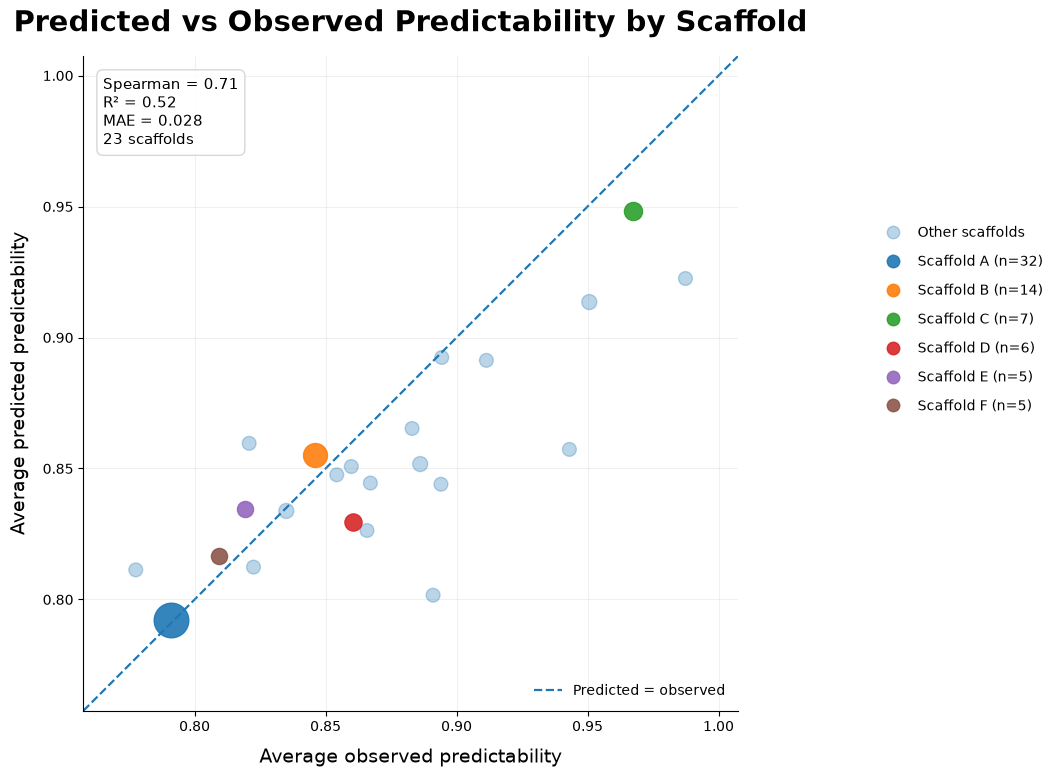


Saved scaffold XY figure:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/structural_analysis/step4_n20_scaffold_observed_vs_predicted_n3_permanent_ids.png

Saved scaffold XY PDF:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/structural_analysis/step4_n20_scaffold_observed_vs_predicted_n3_permanent_ids.pdf


In [18]:
# Updated Scaffold XY Plot 

import numpy as np
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
)


if "scaffold_summary_with_ids" not in globals():
    PERMANENT_MAPPING_PATH = (
        STRUCTURE_OUTPUT_DIR
        / "step4_n20_permanent_scaffold_id_mapping_n3.csv"
    )

    scaffold_summary_with_ids = pd.read_csv(
        PERMANENT_MAPPING_PATH
    )


scaffold_plot_data = (
    scaffold_summary_with_ids
    .copy()
)


# Metrics

scaffold_spearman, scaffold_spearman_p = spearmanr(
    scaffold_plot_data["observed_mean"],
    scaffold_plot_data["predicted_mean"],
)

scaffold_pearson, scaffold_pearson_p = pearsonr(
    scaffold_plot_data["observed_mean"],
    scaffold_plot_data["predicted_mean"],
)

scaffold_mae = mean_absolute_error(
    scaffold_plot_data["observed_mean"],
    scaffold_plot_data["predicted_mean"],
)

scaffold_r2 = r2_score(
    scaffold_plot_data["observed_mean"],
    scaffold_plot_data["predicted_mean"],
)


print(
    f"Scaffolds included: {len(scaffold_plot_data)}"
)

print(
    f"Spearman: {scaffold_spearman:.3f} "
    f"(p={scaffold_spearman_p:.3g})"
)

print(
    f"Pearson: {scaffold_pearson:.3f} "
    f"(p={scaffold_pearson_p:.3g})"
)

print(
    f"R²: {scaffold_r2:.3f}"
)

print(
    f"MAE: {scaffold_mae:.4f}"
)


# Highlight top 6 by compound count 

N_HIGHLIGHT = 6

highlight_data = (
    scaffold_plot_data
    .sort_values(
        [
            "n_compounds",
            "observed_mean",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .head(N_HIGHLIGHT)
    .copy()
)

background_data = (
    scaffold_plot_data[
        ~scaffold_plot_data[
            "scaffold_id"
        ].isin(
            highlight_data[
                "scaffold_id"
            ]
        )
    ]
    .copy()
)


# Axis 

all_values = np.concatenate(
    [
        scaffold_plot_data[
            "observed_mean"
        ].to_numpy(),
        scaffold_plot_data[
            "predicted_mean"
        ].to_numpy(),
    ]
)

axis_min = all_values.min() - 0.02
axis_max = all_values.max() + 0.02

# Figure

fig, ax = plt.subplots(
    figsize=(13.5, 8.5)
)


# Other scaffolds
background_sizes = (
    45
    + 18
    * background_data["n_compounds"]
)

ax.scatter(
    background_data["observed_mean"],
    background_data["predicted_mean"],
    s=background_sizes,
    alpha=0.30,
    zorder=2,
)


# Highlighted scaffolds
default_colors = plt.rcParams[
    "axes.prop_cycle"
].by_key()["color"]

highlight_labels = []

for index, (_, row) in enumerate(
    highlight_data.iterrows()
):
    point_size = (
        45
        + 18 * row["n_compounds"]
    )

    color = default_colors[
        index % len(default_colors)
    ]

    ax.scatter(
        row["observed_mean"],
        row["predicted_mean"],
        s=point_size,
        color=color,
        alpha=0.90,
        zorder=4,
    )

    highlight_labels.append(
        (
            f"{row['scaffold_id']} "
            f"(n={int(row['n_compounds'])})"
        )
    )


# Perfect agreement
ax.plot(
    [
        axis_min,
        axis_max,
    ],
    [
        axis_min,
        axis_max,
    ],
    linestyle="--",
    linewidth=1.6,
    zorder=1,
)


# Metrics box
metrics_text = (
    f"Spearman = {scaffold_spearman:.2f}\n"
    f"R² = {scaffold_r2:.2f}\n"
    f"MAE = {scaffold_mae:.3f}\n"
    f"{len(scaffold_plot_data)} scaffolds"
)

ax.text(
    0.03,
    0.97,
    metrics_text,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=11,
    bbox={
        "boxstyle": "round,pad=0.4",
        "facecolor": "white",
        "alpha": 0.9,
        "edgecolor": "lightgray",
    },
)


ax.set_title(
    "Predicted vs Observed Predictability by Scaffold",
    fontsize=21,
    fontweight="bold",
    pad=18,
)

ax.set_xlabel(
    "Average observed predictability",
    fontsize=13.5,
    labelpad=10,
)

ax.set_ylabel(
    "Average predicted predictability",
    fontsize=13.5,
    labelpad=10,
)

ax.set_xlim(
    axis_min,
    axis_max,
)

ax.set_ylim(
    axis_min,
    axis_max,
)

ax.set_aspect(
    "equal",
    adjustable="box",
)

ax.grid(
    alpha=0.18,
)

for spine in [
    "top",
    "right",
]:
    ax.spines[spine].set_visible(False)


# Legend markers

legend_marker_size = 9

other_handle = Line2D(
    [0],
    [0],
    marker="o",
    linestyle="none",
    markersize=legend_marker_size,
    alpha=0.30,
)

highlight_legend_handles = []

for index in range(
    len(highlight_data)
):
    color = default_colors[
        index % len(default_colors)
    ]

    highlight_legend_handles.append(
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="none",
            markersize=legend_marker_size,
            markerfacecolor=color,
            markeredgecolor=color,
            alpha=0.90,
        )
    )


fig.legend(
    handles=[
        other_handle,
        *highlight_legend_handles,
    ],
    labels=[
        "Other scaffolds",
        *highlight_labels,
    ],
    frameon=False,
    fontsize=10,
    loc="center left",
    bbox_to_anchor=(
        0.76,
        0.57,
    ),
    labelspacing=1.05,
    handletextpad=0.8,
)


agreement_handle = Line2D(
    [0],
    [0],
    linestyle="--",
    linewidth=1.6,
)

ax.legend(
    handles=[agreement_handle],
    labels=["Predicted = observed"],
    loc="lower right",
    frameon=False,
    fontsize=10,
)


fig.subplots_adjust(
    right=0.72
)


# Save

SCAFFOLD_XY_PATH = (
    FIG_DIR
    / "step4_n20_scaffold_observed_vs_predicted_n3_permanent_ids.png"
)

SCAFFOLD_XY_PDF_PATH = (
    FIG_DIR
    / "step4_n20_scaffold_observed_vs_predicted_n3_permanent_ids.pdf"
)

fig.savefig(
    SCAFFOLD_XY_PATH,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    SCAFFOLD_XY_PDF_PATH,
    bbox_inches="tight",
)

plt.show()


print("\nSaved scaffold XY figure:")
print(SCAFFOLD_XY_PATH)

print("\nSaved scaffold XY PDF:")
print(SCAFFOLD_XY_PDF_PATH)

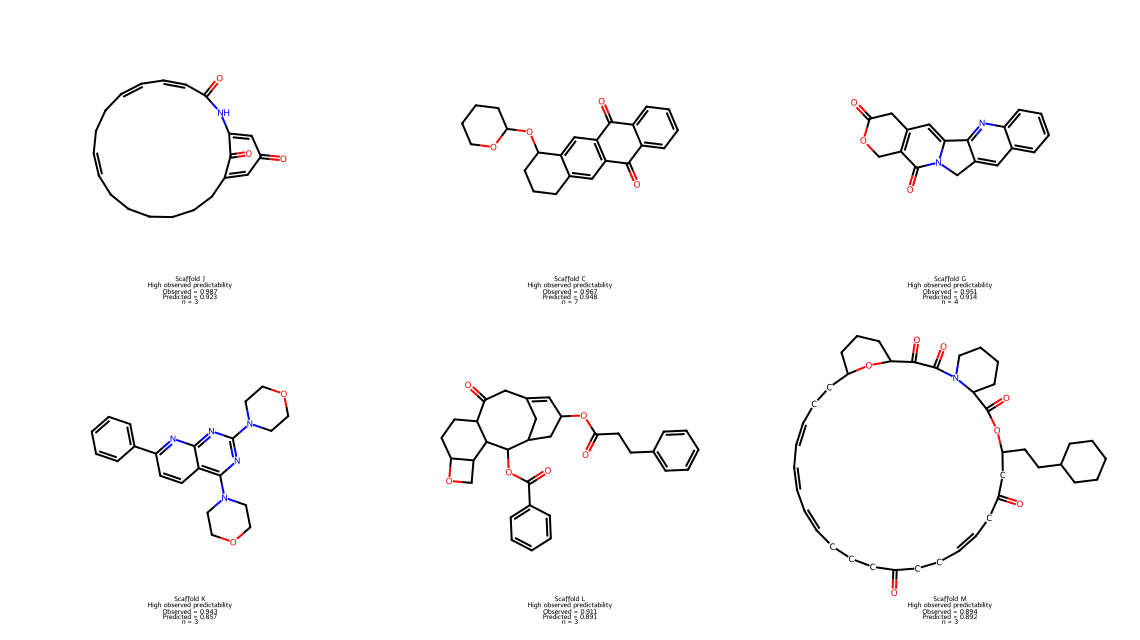

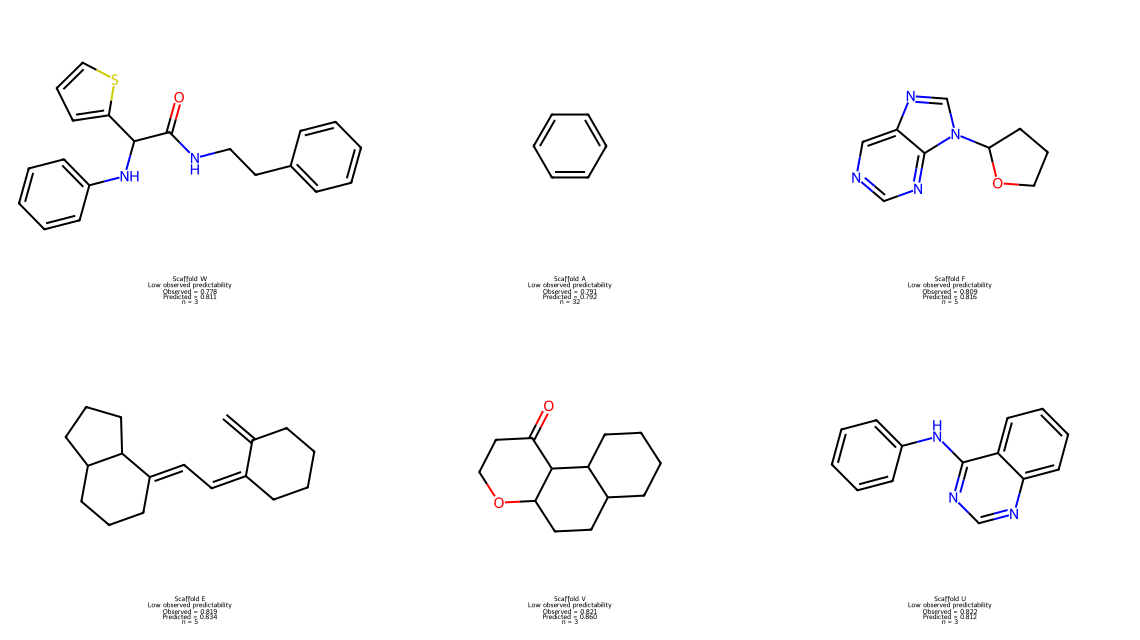


Saved high-predictability grid:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/structural_analysis/step4_n20_highest_predictability_scaffolds_permanent_ids_n3.png

Saved low-predictability grid:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/structural_analysis/step4_n20_lowest_predictability_scaffolds_permanent_ids_n3.png

Saved extreme scaffold table:
/Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/structural_analysis/step4_n20_highest_lowest_scaffolds_permanent_ids_n3.csv


In [19]:
# Update

import io

from PIL import Image
from rdkit import Chem
from rdkit.Chem import Draw


if "scaffold_summary_with_ids" not in globals():
    PERMANENT_MAPPING_PATH = (
        STRUCTURE_OUTPUT_DIR
        / "step4_n20_permanent_scaffold_id_mapping_n3.csv"
    )

    scaffold_summary_with_ids = pd.read_csv(
        PERMANENT_MAPPING_PATH
    )


N_EXTREME = 6

highest_predictability_scaffolds = (
    scaffold_summary_with_ids
    .sort_values(
        "observed_mean",
        ascending=False,
    )
    .head(N_EXTREME)
    .copy()
)

lowest_predictability_scaffolds = (
    scaffold_summary_with_ids
    .sort_values(
        "observed_mean",
        ascending=True,
    )
    .head(N_EXTREME)
    .copy()
)


def create_scaffold_grid(
    scaffold_table,
    group_label,
    output_path,
):
    molecules = []
    legends = []

    for _, row in scaffold_table.iterrows():
        molecule = Chem.MolFromSmiles(
            row["murcko_scaffold"]
        )

        if molecule is None:
            continue

        molecules.append(
            molecule
        )

        legends.append(
            (
                f"{row['scaffold_id']}\n"
                f"{group_label}\n"
                f"Observed = {row['observed_mean']:.3f}\n"
                f"Predicted = {row['predicted_mean']:.3f}\n"
                f"n = {int(row['n_compounds'])}"
            )
        )

    if not molecules:
        raise ValueError(
            "No valid scaffold structures were available."
        )

    grid_image = Draw.MolsToGridImage(
        molecules,
        legends=legends,
        molsPerRow=3,
        subImgSize=(380, 320),
        useSVG=False,
    )

    if isinstance(
        grid_image,
        Image.Image,
    ):
        pil_image = grid_image

    elif hasattr(
        grid_image,
        "data",
    ):
        pil_image = Image.open(
            io.BytesIO(
                grid_image.data
            )
        )

    else:
        pil_image = Image.open(
            io.BytesIO(
                grid_image
            )
        )

    pil_image.save(
        output_path
    )

    return pil_image


HIGH_SCAFFOLD_FIGURE_PATH = (
    FIG_DIR
    / "step4_n20_highest_predictability_scaffolds_permanent_ids_n3.png"
)

LOW_SCAFFOLD_FIGURE_PATH = (
    FIG_DIR
    / "step4_n20_lowest_predictability_scaffolds_permanent_ids_n3.png"
)


high_grid = create_scaffold_grid(
    highest_predictability_scaffolds,
    "High observed predictability",
    HIGH_SCAFFOLD_FIGURE_PATH,
)

low_grid = create_scaffold_grid(
    lowest_predictability_scaffolds,
    "Low observed predictability",
    LOW_SCAFFOLD_FIGURE_PATH,
)


display(high_grid)
display(low_grid)


EXTREME_TABLE_PATH = (
    STRUCTURE_OUTPUT_DIR
    / "step4_n20_highest_lowest_scaffolds_permanent_ids_n3.csv"
)

pd.concat(
    [
        highest_predictability_scaffolds.assign(
            scaffold_group=(
                "Highest observed predictability"
            )
        ),
        lowest_predictability_scaffolds.assign(
            scaffold_group=(
                "Lowest observed predictability"
            )
        ),
    ],
    ignore_index=True,
).to_csv(
    EXTREME_TABLE_PATH,
    index=False,
)


print("\nSaved high-predictability grid:")
print(HIGH_SCAFFOLD_FIGURE_PATH)

print("\nSaved low-predictability grid:")
print(LOW_SCAFFOLD_FIGURE_PATH)

print("\nSaved extreme scaffold table:")
print(EXTREME_TABLE_PATH)

Largest-error scaffolds: ['Scaffold O', 'Scaffold K', 'Scaffold J', 'Scaffold N', 'Scaffold R', 'Scaffold G', 'Scaffold H', 'Scaffold V']
Smallest-error scaffolds: ['Scaffold U', 'Scaffold S', 'Scaffold T', 'Scaffold M', 'Scaffold I', 'Scaffold A', 'Scaffold F', 'Scaffold B']


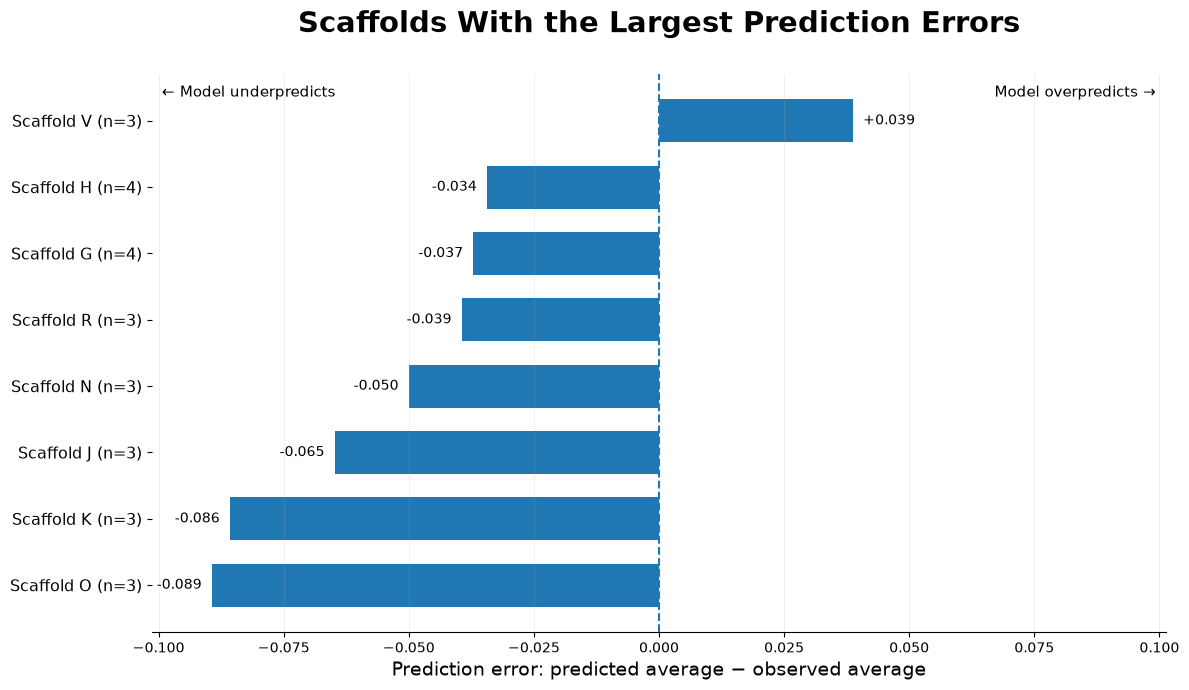

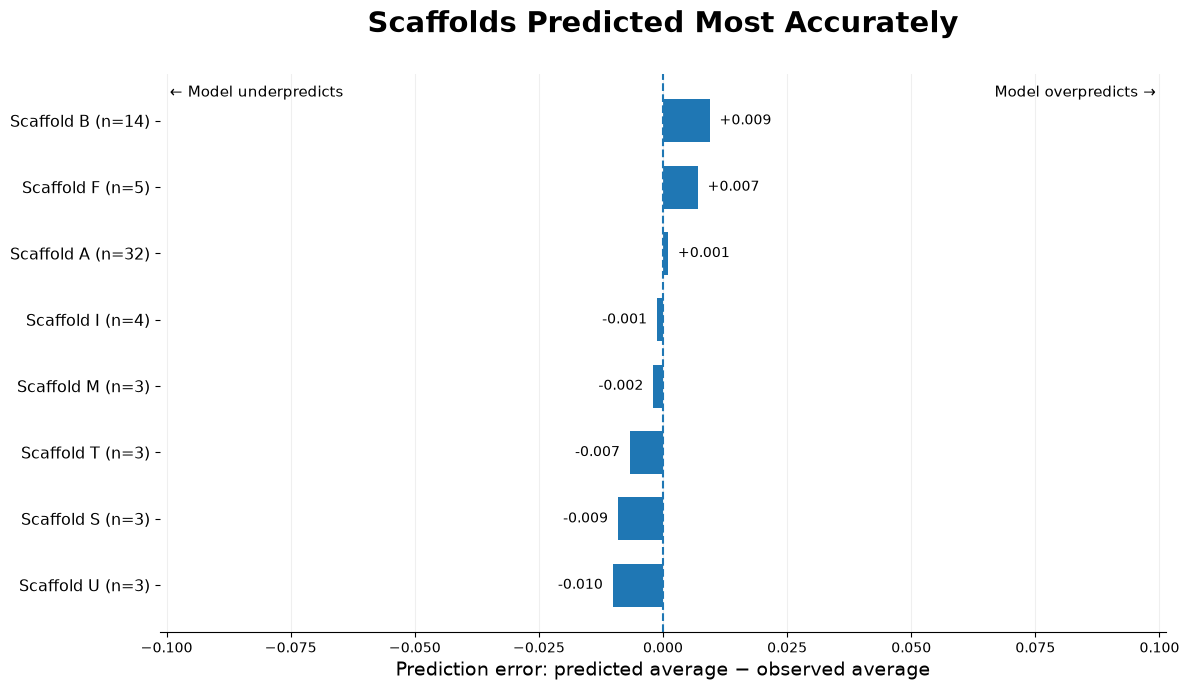


Saved largest-error figure:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/structural_analysis/step4_n20_8_largest_scaffold_prediction_errors_n3.png

Saved smallest-error figure:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/structural_analysis/step4_n20_8_smallest_scaffold_prediction_errors_n3.png


In [20]:
# Error Plots v2

import numpy as np
import matplotlib.pyplot as plt


if "scaffold_summary_with_ids" not in globals():
    PERMANENT_MAPPING_PATH = (
        STRUCTURE_OUTPUT_DIR
        / "step4_n20_permanent_scaffold_id_mapping_n3.csv"
    )

    scaffold_summary_with_ids = pd.read_csv(
        PERMANENT_MAPPING_PATH
    )


N_TO_SHOW = 8


ranked_by_error = (
    scaffold_summary_with_ids
    .sort_values(
        "absolute_error",
        ascending=False,
    )
    .reset_index(drop=True)
)

largest_errors = (
    ranked_by_error
    .head(N_TO_SHOW)
    .sort_values(
        "prediction_error",
        ascending=True,
    )
    .reset_index(drop=True)
)

smallest_errors = (
    ranked_by_error
    .tail(N_TO_SHOW)
    .sort_values(
        "prediction_error",
        ascending=True,
    )
    .reset_index(drop=True)
)


overlap = set(
    largest_errors["scaffold_id"]
).intersection(
    smallest_errors["scaffold_id"]
)

if overlap:
    raise ValueError(
        f"Unexpected overlap between groups: {overlap}"
    )


print(
    "Largest-error scaffolds:",
    largest_errors["scaffold_id"].tolist(),
)

print(
    "Smallest-error scaffolds:",
    smallest_errors["scaffold_id"].tolist(),
)



shared_limit = (
    largest_errors[
        "absolute_error"
    ].max()
    + 0.012
)


def make_scaffold_error_plot(
    plot_data,
    title,
    figure_path,
    pdf_path,
):
    fig, ax = plt.subplots(
        figsize=(12, 7)
    )

    y_positions = np.arange(
        len(plot_data)
    )

    bars = ax.barh(
        y_positions,
        plot_data["prediction_error"],
        height=0.65,
    )

    ax.axvline(
        0,
        linestyle="--",
        linewidth=1.5,
    )

    labels = [
        (
            f"{row['scaffold_id']} "
            f"(n={int(row['n_compounds'])})"
        )
        for _, row in plot_data.iterrows()
    ]

    ax.set_yticks(
        y_positions
    )

    ax.set_yticklabels(
        labels,
        fontsize=11.5,
    )

    ax.set_title(
        title,
        fontsize=21,
        fontweight="bold",
        pad=30,
    )

    ax.set_xlabel(
        (
            "Prediction error: predicted average "
            "− observed average"
        ),
        fontsize=13.5,
    )

    ax.text(
        0.01,
        0.98,
        "← Model underpredicts",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11,
    )

    ax.text(
        0.99,
        0.98,
        "Model overpredicts →",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=11,
    )

    for bar, value in zip(
        bars,
        plot_data["prediction_error"],
    ):
        if value >= 0:
            text_x = value + 0.002
            alignment = "left"
        else:
            text_x = value - 0.002
            alignment = "right"

        ax.text(
            text_x,
            (
                bar.get_y()
                + bar.get_height() / 2
            ),
            f"{value:+.3f}",
            ha=alignment,
            va="center",
            fontsize=10,
        )

    ax.set_xlim(
        -shared_limit,
        shared_limit,
    )

    ax.grid(
        axis="x",
        alpha=0.2,
    )

    for spine in [
        "top",
        "right",
        "left",
    ]:
        ax.spines[spine].set_visible(
            False
        )

    fig.tight_layout()

    fig.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight",
    )

    plt.show()


# Largest errors

LARGEST_ERROR_FIGURE_PATH = (
    FIG_DIR
    / "step4_n20_8_largest_scaffold_prediction_errors_n3.png"
)

LARGEST_ERROR_PDF_PATH = (
    FIG_DIR
    / "step4_n20_8_largest_scaffold_prediction_errors_n3.pdf"
)

make_scaffold_error_plot(
    plot_data=largest_errors,
    title="Scaffolds With the Largest Prediction Errors",
    figure_path=LARGEST_ERROR_FIGURE_PATH,
    pdf_path=LARGEST_ERROR_PDF_PATH,
)


# Smallest errors

SMALLEST_ERROR_FIGURE_PATH = (
    FIG_DIR
    / "step4_n20_8_smallest_scaffold_prediction_errors_n3.png"
)

SMALLEST_ERROR_PDF_PATH = (
    FIG_DIR
    / "step4_n20_8_smallest_scaffold_prediction_errors_n3.pdf"
)

make_scaffold_error_plot(
    plot_data=smallest_errors,
    title="Scaffolds Predicted Most Accurately",
    figure_path=SMALLEST_ERROR_FIGURE_PATH,
    pdf_path=SMALLEST_ERROR_PDF_PATH,
)


# Save

LARGEST_ERROR_TABLE_PATH = (
    STRUCTURE_OUTPUT_DIR
    / "step4_n20_8_largest_scaffold_prediction_errors_n3.csv"
)

SMALLEST_ERROR_TABLE_PATH = (
    STRUCTURE_OUTPUT_DIR
    / "step4_n20_8_smallest_scaffold_prediction_errors_n3.csv"
)

largest_errors.to_csv(
    LARGEST_ERROR_TABLE_PATH,
    index=False,
)

smallest_errors.to_csv(
    SMALLEST_ERROR_TABLE_PATH,
    index=False,
)


print("\nSaved largest-error figure:")
print(LARGEST_ERROR_FIGURE_PATH)

print("\nSaved smallest-error figure:")
print(SMALLEST_ERROR_FIGURE_PATH)

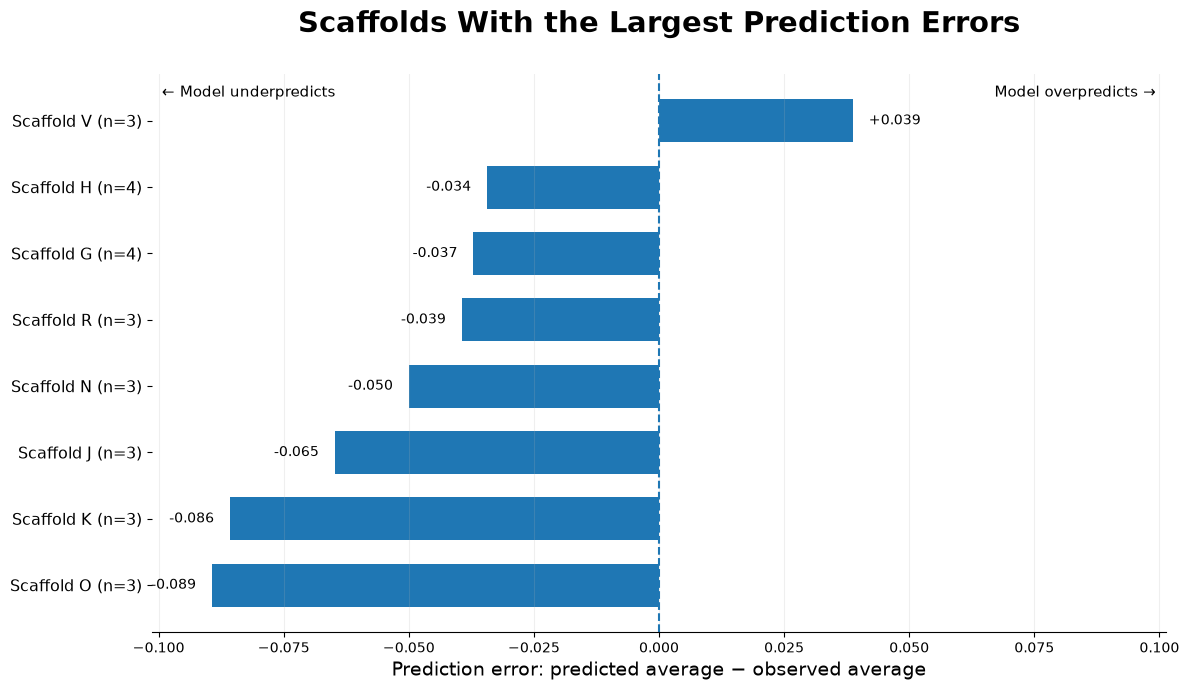

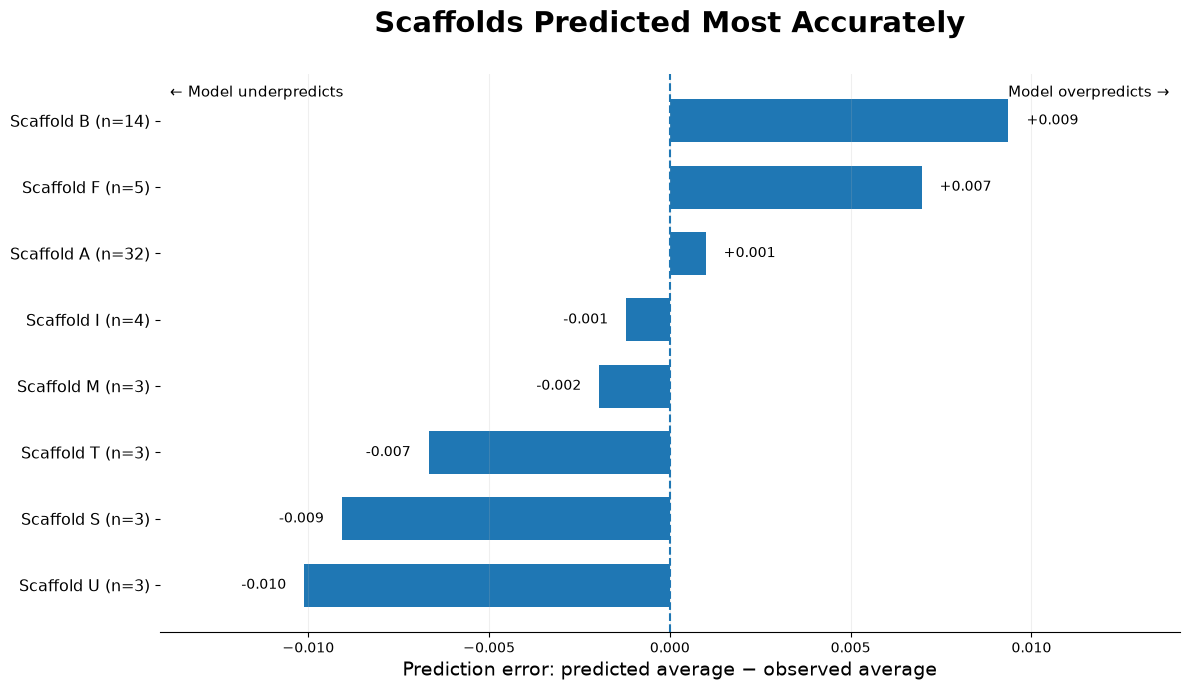


Saved largest-error figure:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/structural_analysis/step4_n20_8_largest_scaffold_prediction_errors_n3.png

Saved smallest-error figure:
/Users/mell/predicting-predictability/figures/step4_expanded_n20/structural_analysis/step4_n20_8_smallest_scaffold_prediction_errors_n3.png

Largest-error x-axis limit:
0.10137786666666669

Smallest-error x-axis limit:
0.0141086733333335


In [21]:
# Re Do

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Load 

if "scaffold_summary_with_ids" not in globals():
    PERMANENT_MAPPING_PATH = (
        STRUCTURE_OUTPUT_DIR
        / "step4_n20_permanent_scaffold_id_mapping_n3.csv"
    )

    scaffold_summary_with_ids = pd.read_csv(
        PERMANENT_MAPPING_PATH
    )


# Select

N_TO_SHOW = 8

ranked_by_error = (
    scaffold_summary_with_ids
    .sort_values(
        "absolute_error",
        ascending=False,
    )
    .reset_index(drop=True)
)

largest_errors = (
    ranked_by_error
    .head(N_TO_SHOW)
    .sort_values(
        "prediction_error",
        ascending=True,
    )
    .reset_index(drop=True)
)

smallest_errors = (
    ranked_by_error
    .tail(N_TO_SHOW)
    .sort_values(
        "prediction_error",
        ascending=True,
    )
    .reset_index(drop=True)
)


overlap = set(
    largest_errors["scaffold_id"]
).intersection(
    smallest_errors["scaffold_id"]
)

if overlap:
    raise ValueError(
        f"Unexpected overlap between groups: {overlap}"
    )


# Plotting fxn

def make_scaffold_error_plot(
    plot_data,
    title,
    figure_path,
    pdf_path,
    axis_padding,
):
    fig, ax = plt.subplots(
        figsize=(12, 7)
    )

    y_positions = np.arange(
        len(plot_data)
    )

    bars = ax.barh(
        y_positions,
        plot_data["prediction_error"],
        height=0.65,
    )

    ax.axvline(
        0,
        linestyle="--",
        linewidth=1.5,
    )



    # Scaffold labels


    labels = [
        (
            f"{row['scaffold_id']} "
            f"(n={int(row['n_compounds'])})"
        )
        for _, row in plot_data.iterrows()
    ]

    ax.set_yticks(
        y_positions
    )

    ax.set_yticklabels(
        labels,
        fontsize=11.5,
    )



    # Titles and axis labels


    ax.set_title(
        title,
        fontsize=21,
        fontweight="bold",
        pad=30,
    )

    ax.set_xlabel(
        (
            "Prediction error: predicted average "
            "− observed average"
        ),
        fontsize=13.5,
    )



    # Direction labels


    ax.text(
        0.01,
        0.98,
        "← Model underpredicts",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11,
    )

    ax.text(
        0.99,
        0.98,
        "Model overpredicts →",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=11,
    )



    # Value labels


    max_absolute_error = (
        plot_data["absolute_error"]
        .max()
    )

    label_offset = max(
        max_absolute_error * 0.035,
        0.0005,
    )

    for bar, value in zip(
        bars,
        plot_data["prediction_error"],
    ):
        if value >= 0:
            text_x = value + label_offset
            alignment = "left"
        else:
            text_x = value - label_offset
            alignment = "right"

        ax.text(
            text_x,
            (
                bar.get_y()
                + bar.get_height() / 2
            ),
            f"{value:+.3f}",
            ha=alignment,
            va="center",
            fontsize=10,
        )



    # x-axis range

    axis_limit = (
        max_absolute_error
        + axis_padding
    )

    ax.set_xlim(
        -axis_limit,
        axis_limit,
    )


    # Formatting


    ax.grid(
        axis="x",
        alpha=0.2,
    )

    for spine in [
        "top",
        "right",
        "left",
    ]:
        ax.spines[spine].set_visible(
            False
        )

    fig.tight_layout()


    
    # Save


    fig.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight",
    )

    plt.show()




LARGEST_ERROR_FIGURE_PATH = (
    FIG_DIR
    / "step4_n20_8_largest_scaffold_prediction_errors_n3.png"
)

LARGEST_ERROR_PDF_PATH = (
    FIG_DIR
    / "step4_n20_8_largest_scaffold_prediction_errors_n3.pdf"
)

make_scaffold_error_plot(
    plot_data=largest_errors,
    title="Scaffolds With the Largest Prediction Errors",
    figure_path=LARGEST_ERROR_FIGURE_PATH,
    pdf_path=LARGEST_ERROR_PDF_PATH,
    axis_padding=0.012,
)




SMALLEST_ERROR_FIGURE_PATH = (
    FIG_DIR
    / "step4_n20_8_smallest_scaffold_prediction_errors_n3.png"
)

SMALLEST_ERROR_PDF_PATH = (
    FIG_DIR
    / "step4_n20_8_smallest_scaffold_prediction_errors_n3.pdf"
)

make_scaffold_error_plot(
    plot_data=smallest_errors,
    title="Scaffolds Predicted Most Accurately",
    figure_path=SMALLEST_ERROR_FIGURE_PATH,
    pdf_path=SMALLEST_ERROR_PDF_PATH,
    axis_padding=0.004,
)


# Save

LARGEST_ERROR_TABLE_PATH = (
    STRUCTURE_OUTPUT_DIR
    / "step4_n20_8_largest_scaffold_prediction_errors_n3.csv"
)

SMALLEST_ERROR_TABLE_PATH = (
    STRUCTURE_OUTPUT_DIR
    / "step4_n20_8_smallest_scaffold_prediction_errors_n3.csv"
)

largest_errors.to_csv(
    LARGEST_ERROR_TABLE_PATH,
    index=False,
)

smallest_errors.to_csv(
    SMALLEST_ERROR_TABLE_PATH,
    index=False,
)


print("\nSaved largest-error figure:")
print(LARGEST_ERROR_FIGURE_PATH)

print("\nSaved smallest-error figure:")
print(SMALLEST_ERROR_FIGURE_PATH)

print("\nLargest-error x-axis limit:")
print(
    largest_errors["absolute_error"].max()
    + 0.012
)

print("\nSmallest-error x-axis limit:")
print(
    smallest_errors["absolute_error"].max()
    + 0.004
)

In [23]:
# Ambig. Compounds 

from pathlib import Path

import pandas as pd
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, r2_score



cwd = Path.cwd()

if (cwd / "data" / "step3_multimodal").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data" / "step3_multimodal").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        f"Could not locate project root from: {cwd}"
    )

STRUCTURE_OUTPUT_DIR = (
    PROJECT_ROOT
    / "data"
    / "step3_multimodal"
    / "step4_expanded_n20"
    / "structural_analysis"
)



SCAFFOLD_DATA_PATH = (
    STRUCTURE_OUTPUT_DIR
    / "step4_n20_compounds_with_murcko_scaffolds.csv"
)

if not SCAFFOLD_DATA_PATH.exists():
    raise FileNotFoundError(
        f"Missing compound-scaffold table:\n{SCAFFOLD_DATA_PATH}"
    )

robustness_data = pd.read_csv(
    SCAFFOLD_DATA_PATH,
    low_memory=False,
)


required_columns = [
    "compound_embedding_row_index",
    "actual_predictability",
    "predicted_predictability",
    "murcko_scaffold",
    "has_murcko_scaffold",
    "structure_name_is_ambiguous",
]

missing_columns = [
    column
    for column in required_columns
    if column not in robustness_data.columns
]

if missing_columns:
    raise KeyError(
        f"Missing columns: {missing_columns}\n"
        f"Available columns: {robustness_data.columns.tolist()}"
    )



def convert_to_boolean(series):
    return (
        series
        .astype(str)
        .str.strip()
        .str.lower()
        .map(
            {
                "true": True,
                "false": False,
                "1": True,
                "0": False,
            }
        )
        .fillna(False)
        .astype(bool)
    )


robustness_data["has_murcko_scaffold"] = (
    convert_to_boolean(
        robustness_data["has_murcko_scaffold"]
    )
)

robustness_data["structure_name_is_ambiguous"] = (
    convert_to_boolean(
        robustness_data["structure_name_is_ambiguous"]
    )
)




original_scaffold_mask = (
    robustness_data["has_murcko_scaffold"]
    & robustness_data["murcko_scaffold"].notna()
)

ambiguous_mask = (
    robustness_data["structure_name_is_ambiguous"]
)

unambiguous_mask = (
    original_scaffold_mask
    & ~ambiguous_mask
)


original_n = (
    robustness_data.loc[
        original_scaffold_mask,
        "compound_embedding_row_index",
    ]
    .nunique()
)

ambiguous_n = (
    robustness_data.loc[
        original_scaffold_mask & ambiguous_mask,
        "compound_embedding_row_index",
    ]
    .nunique()
)

unambiguous_data = (
    robustness_data.loc[
        unambiguous_mask
    ]
    .drop_duplicates(
        subset=[
            "compound_embedding_row_index",
            "murcko_scaffold",
        ]
    )
    .copy()
)

unambiguous_n = (
    unambiguous_data[
        "compound_embedding_row_index"
    ]
    .nunique()
)


print("Robustness cohort")
print("=================")
print("Original compounds with scaffolds:", original_n)
print("Ambiguous compounds excluded:", ambiguous_n)
print("Unambiguous compounds retained:", unambiguous_n)


# Recalculate 

MIN_SCAFFOLD_COMPOUNDS = 3

unambiguous_scaffold_summary = (
    unambiguous_data
    .groupby("murcko_scaffold")
    .agg(
        n_compounds=(
            "compound_embedding_row_index",
            "nunique",
        ),
        observed_mean=(
            "actual_predictability",
            "mean",
        ),
        observed_median=(
            "actual_predictability",
            "median",
        ),
        observed_std=(
            "actual_predictability",
            "std",
        ),
        predicted_mean=(
            "predicted_predictability",
            "mean",
        ),
        predicted_median=(
            "predicted_predictability",
            "median",
        ),
    )
    .reset_index()
)

unambiguous_scaffold_summary["prediction_error"] = (
    unambiguous_scaffold_summary["predicted_mean"]
    - unambiguous_scaffold_summary["observed_mean"]
)

unambiguous_scaffold_summary["absolute_error"] = (
    unambiguous_scaffold_summary["prediction_error"]
    .abs()
)

unambiguous_scaffold_summary = (
    unambiguous_scaffold_summary[
        unambiguous_scaffold_summary["n_compounds"]
        >= MIN_SCAFFOLD_COMPOUNDS
    ]
    .copy()
)


# Attach

PERMANENT_MAPPING_PATH = (
    STRUCTURE_OUTPUT_DIR
    / "step4_n20_permanent_scaffold_id_mapping_n3.csv"
)

if not PERMANENT_MAPPING_PATH.exists():
    raise FileNotFoundError(
        f"Missing permanent scaffold mapping:\n"
        f"{PERMANENT_MAPPING_PATH}"
    )

original_scaffold_summary = pd.read_csv(
    PERMANENT_MAPPING_PATH
)

permanent_mapping = (
    original_scaffold_summary[
        [
            "scaffold_id",
            "murcko_scaffold",
        ]
    ]
    .drop_duplicates()
)

unambiguous_scaffold_summary = (
    unambiguous_scaffold_summary
    .merge(
        permanent_mapping,
        on="murcko_scaffold",
        how="left",
    )
)



# Calculate 

original_spearman, original_p = spearmanr(
    original_scaffold_summary["observed_mean"],
    original_scaffold_summary["predicted_mean"],
)

original_r2 = r2_score(
    original_scaffold_summary["observed_mean"],
    original_scaffold_summary["predicted_mean"],
)

original_mae = mean_absolute_error(
    original_scaffold_summary["observed_mean"],
    original_scaffold_summary["predicted_mean"],
)


robust_spearman, robust_p = spearmanr(
    unambiguous_scaffold_summary["observed_mean"],
    unambiguous_scaffold_summary["predicted_mean"],
)

robust_r2 = r2_score(
    unambiguous_scaffold_summary["observed_mean"],
    unambiguous_scaffold_summary["predicted_mean"],
)

robust_mae = mean_absolute_error(
    unambiguous_scaffold_summary["observed_mean"],
    unambiguous_scaffold_summary["predicted_mean"],
)


comparison_metrics = pd.DataFrame(
    [
        {
            "analysis": "Original",
            "n_compounds": original_n,
            "n_scaffolds": len(original_scaffold_summary),
            "spearman": original_spearman,
            "spearman_p": original_p,
            "r2": original_r2,
            "mae": original_mae,
        },
        {
            "analysis": "Excluded ambiguous matches",
            "n_compounds": unambiguous_n,
            "n_scaffolds": len(unambiguous_scaffold_summary),
            "spearman": robust_spearman,
            "spearman_p": robust_p,
            "r2": robust_r2,
            "mae": robust_mae,
        },
    ]
)


print("\nMetric comparison")
print("=================")
display(comparison_metrics)


# Compare 

comparison_table = (
    original_scaffold_summary[
        [
            "scaffold_id",
            "murcko_scaffold",
            "n_compounds",
            "observed_mean",
            "predicted_mean",
            "prediction_error",
        ]
    ]
    .rename(
        columns={
            "n_compounds": "original_n_compounds",
            "observed_mean": "original_observed_mean",
            "predicted_mean": "original_predicted_mean",
            "prediction_error": "original_prediction_error",
        }
    )
    .merge(
        unambiguous_scaffold_summary[
            [
                "scaffold_id",
                "murcko_scaffold",
                "n_compounds",
                "observed_mean",
                "predicted_mean",
                "prediction_error",
            ]
        ]
        .rename(
            columns={
                "n_compounds": "unambiguous_n_compounds",
                "observed_mean": "unambiguous_observed_mean",
                "predicted_mean": "unambiguous_predicted_mean",
                "prediction_error": "unambiguous_prediction_error",
            }
        ),
        on=[
            "scaffold_id",
            "murcko_scaffold",
        ],
        how="outer",
    )
)

comparison_table["observed_mean_change"] = (
    comparison_table["unambiguous_observed_mean"]
    - comparison_table["original_observed_mean"]
)

comparison_table["predicted_mean_change"] = (
    comparison_table["unambiguous_predicted_mean"]
    - comparison_table["original_predicted_mean"]
)

comparison_table = (
    comparison_table
    .sort_values(
        "observed_mean_change",
        key=lambda values: values.abs(),
        ascending=False,
    )
)


print("\nLargest scaffold-level changes")
print("==============================")
display(
    comparison_table.head(15)
)


# Compare 

N_HIGHLIGHT = 6

original_highlighted = (
    original_scaffold_summary
    .sort_values(
        [
            "n_compounds",
            "observed_mean",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .head(N_HIGHLIGHT)
)

robust_highlighted = (
    unambiguous_scaffold_summary
    .sort_values(
        [
            "n_compounds",
            "observed_mean",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .head(N_HIGHLIGHT)
)


print("\nOriginal highlighted scaffolds")
display(
    original_highlighted[
        [
            "scaffold_id",
            "n_compounds",
            "observed_mean",
            "predicted_mean",
        ]
    ]
)

print("\nHighlighted scaffolds after exclusion")
display(
    robust_highlighted[
        [
            "scaffold_id",
            "n_compounds",
            "observed_mean",
            "predicted_mean",
        ]
    ]
)


# Save 

ROBUST_SUMMARY_PATH = (
    STRUCTURE_OUTPUT_DIR
    / "step4_n20_scaffold_predictability_excluding_ambiguous_n3.csv"
)

ROBUST_METRICS_PATH = (
    STRUCTURE_OUTPUT_DIR
    / "step4_n20_scaffold_ambiguity_robustness_metrics.csv"
)

ROBUST_COMPARISON_PATH = (
    STRUCTURE_OUTPUT_DIR
    / "step4_n20_scaffold_ambiguity_robustness_comparison.csv"
)

unambiguous_scaffold_summary.to_csv(
    ROBUST_SUMMARY_PATH,
    index=False,
)

comparison_metrics.to_csv(
    ROBUST_METRICS_PATH,
    index=False,
)

comparison_table.to_csv(
    ROBUST_COMPARISON_PATH,
    index=False,
)


print("\nSaved robustness summary:")
print(ROBUST_SUMMARY_PATH)

print("\nSaved robustness metrics:")
print(ROBUST_METRICS_PATH)

print("\nSaved robustness comparison:")
print(ROBUST_COMPARISON_PATH)

Robustness cohort
Original compounds with scaffolds: 785
Ambiguous compounds excluded: 34
Unambiguous compounds retained: 751

Metric comparison


,analysis,n_compounds,n_scaffolds,spearman,spearman_p,r2,mae
0,Original,785,23,0.708498,0.000155,0.521264,0.028063
1,Excluded ambiguous matches,751,19,0.694737,0.000963,0.509051,0.031118



Largest scaffold-level changes


,scaffold_id,murcko_scaffold,original_n_compounds,original_observed_mean,original_predicted_mean,original_prediction_error,unambiguous_n_compounds,unambiguous_observed_mean,unambiguous_predicted_mean,unambiguous_prediction_error,observed_mean_change,predicted_mean_change
1,Scaffold B,O=C1C=CC2C(=C1)CCC1C3CCCC3CCC21,14,0.845841,0.855204,0.009363,13.0,0.851557,0.854802,0.003246,5.715863e-03,-4.020169e-04
10,Scaffold K,c1ccc(-c2ccc3c(N4CCOCC4)nc(N4CCOCC4)nc3n2)cc1,3,0.943061,0.857290,-0.085772,3.0,0.943061,0.857290,-0.085772,-1.110223e-16,0.000000e+00
9,Scaffold J,O=C1C=C2CCCCCCC=CCCC=CC=CC(=O)NC(=C1)C2=O,3,0.987370,0.922532,-0.064838,3.0,0.987370,0.922532,-0.064838,-1.110223e-16,1.110223e-16
13,Scaffold N,c1ccc2c(c1)CCC1C2CCC2CCCC21,3,0.894020,0.843986,-0.050034,3.0,0.894020,0.843986,-0.050034,0.000000e+00,0.000000e+00
21,Scaffold V,O=C1CCOC2CCC3CCCCC3C12,3,0.820807,0.859600,0.038792,3.0,0.820807,0.859600,0.038792,0.000000e+00,0.000000e+00
20,Scaffold U,c1ccc(Nc2ncnc3ccccc23)cc1,3,0.822473,0.812364,-0.010109,3.0,0.822473,0.812364,-0.010109,0.000000e+00,0.000000e+00
19,Scaffold T,O=C1C=CC2C(=C1)CCC1C2CCC2C1CC1OCOC12,3,0.854254,0.847589,-0.006665,3.0,0.854254,0.847589,-0.006665,0.000000e+00,0.000000e+00
17,Scaffold R,c1ccc2c(c1)Nc1ccccc1S2,3,0.865792,0.826339,-0.039453,3.0,0.865792,0.826339,-0.039453,0.000000e+00,0.000000e+00
16,Scaffold Q,C1=CC2CCC3Nc4ccc(C5CC6CCCN(CCc7c5[nH]c5ccccc75...,3,0.867087,0.844452,-0.022635,3.0,0.867087,0.844452,-0.022635,0.000000e+00,0.000000e+00
14,Scaffold O,c1ccc2[nH]cnc2c1,3,0.891026,0.801648,-0.089378,3.0,0.891026,0.801648,-0.089378,0.000000e+00,0.000000e+00



Original highlighted scaffolds


,scaffold_id,n_compounds,observed_mean,predicted_mean
0,Scaffold A,32,0.791077,0.792065
1,Scaffold B,14,0.845841,0.855204
2,Scaffold C,7,0.967313,0.948340
3,Scaffold D,6,0.860529,0.829528
4,Scaffold E,5,0.819291,0.834437
5,Scaffold F,5,0.809487,0.816447



Highlighted scaffolds after exclusion


,scaffold_id,n_compounds,observed_mean,predicted_mean
17,Scaffold A,32,0.791077,0.792065
6,Scaffold B,13,0.851557,0.854802
10,Scaffold C,7,0.967313,0.948340
3,Scaffold D,6,0.860529,0.829528
1,Scaffold E,5,0.819291,0.834437
18,Scaffold F,5,0.809487,0.816447



Saved robustness summary:
/Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/structural_analysis/step4_n20_scaffold_predictability_excluding_ambiguous_n3.csv

Saved robustness metrics:
/Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/structural_analysis/step4_n20_scaffold_ambiguity_robustness_metrics.csv

Saved robustness comparison:
/Users/mell/predicting-predictability/data/step3_multimodal/step4_expanded_n20/structural_analysis/step4_n20_scaffold_ambiguity_robustness_comparison.csv
